In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/My Drive/single_cell_isoform_smoothing/

/content/drive/My Drive/single_cell_isoform_smoothing


In [3]:
!pip install scanpy
!pip install --upgrade networkx
!pip install SCORED

import anndata
import numpy as np
import pandas as pd
import sklearn
import scipy
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.notebook import tqdm
import networkx as nx
import torch
from scipy.sparse import csr_matrix
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import seaborn as sns



In [4]:
if torch.cuda.is_available():
  dev = "cuda:0"
else:
  dev = "cpu"
device = torch.device(dev)

if torch.cuda.is_available():
   print ("Cuda is available")
   device_id = torch.cuda.current_device()
   gpu_properties = torch.cuda.get_device_properties(device_id)
   print("Found %d GPUs available. Using GPU %d (%s) of compute capability %d.%d with "
          "%.1fGb total memory.\n" %
          (torch.cuda.device_count(),
          device_id,
          gpu_properties.name,
          gpu_properties.major,
          gpu_properties.minor,
          gpu_properties.total_memory / 1e9))
else:
   print ("Cuda is not available")

Cuda is not available


In [5]:
def simrank_similarity_optimized(adj_matrix, decay_factor=0.8, max_iter=1000, eps=1e-4, device='cpu'):
    """
    Optimized SimRank similarity computation using matrix operations to avoid for loops.

    Parameters:
    adj_matrix (torch.Tensor): Adjacency matrix (n x n) where n is the number of nodes.
    decay_factor (float): Decay factor (C) in the SimRank equation, usually between 0 and 1.
    max_iter (int): Maximum number of iterations to run the algorithm.
    eps (float): Convergence threshold for stopping criterion.
    device (str): Device to run the computation ('cpu' or 'cuda').

    Returns:
    torch.Tensor: SimRank similarity matrix (n x n).
    """
    n = adj_matrix.shape[0]  # Number of nodes
    sim_matrix = torch.eye(n, device=device)  # Initialize similarity matrix as identity (self-similarity = 1)

    # Normalize the adjacency matrix by the out-degree (number of neighbors)
    out_degrees = adj_matrix.sum(dim=1, keepdim=True)
    norm_adj_matrix = torch.where(out_degrees > 0, adj_matrix / out_degrees, adj_matrix).to(device)

    # Iterate to update similarity scores
    for _ in range(max_iter):
        new_sim_matrix = sim_matrix.clone()  # Copy the similarity matrix for updating

        # Compute pairwise similarities using matrix operations
        sim_scores = torch.matmul(norm_adj_matrix, torch.matmul(sim_matrix, norm_adj_matrix.T))
        new_sim_matrix = decay_factor * sim_scores

        # Ensure self-similarity remains 1 (diagonal elements)
        new_sim_matrix.fill_diagonal_(1)

        # Check for convergence
        if torch.norm(new_sim_matrix - sim_matrix) < eps:
            break

        sim_matrix = new_sim_matrix

    return sim_matrix


def gaussian_kernel_weights_with_simrank(distances: csr_matrix, sim_matrix: np.ndarray, k: int, device='cpu') -> torch.Tensor:
    """
    Calculate Gaussian kernel-based weights for a kNN graph based on distances and SimRank similarity matrix.

    Parameters
    ----------
    distances: csr_matrix
        The input sparse matrix of distances between cells. Non-nearest neighbors are set to 0.

    sim_matrix: np.ndarray
        The SimRank similarity matrix (dense, NumPy array).

    k: int
        The number of nearest neighbors to consider for intersection.

    device: str
        Device for torch tensors ('cpu' or 'cuda').

    Returns
    -------
    weights: torch.Tensor
        A symmetric weight matrix with Gaussian kernel weights.
    """
    # Convert the sparse distance matrix to dense and move to the specified device
    distances_dense = distances.toarray()
    distances_tensor = torch.tensor(distances_dense, dtype=torch.float32).to(device)

    # Convert SimRank matrix to torch tensor and move to device
    simrank_tensor = torch.tensor(sim_matrix, dtype=torch.float32).to(device)

    # Initialize an empty matrix for weights
    n_cells = distances_tensor.shape[0]
    weights = torch.zeros_like(distances_tensor, device=device)

    # Calculate sigma (median of non-zero distances) for each cell
    sigmas_sq = torch.zeros(n_cells, device=device)

    for i in range(n_cells):
        # Extract non-zero distances for each cell (ignoring zero distances)
        non_zero_distances = distances_tensor[i][distances_tensor[i] > 0]

        # If there are non-zero distances, compute sigma as the median
        if len(non_zero_distances) > 0:
            sigmas_sq[i] = torch.median(non_zero_distances ** 2)

    # Compute sigma by taking the square root of sigmas_sq
    sigmas = torch.sqrt(sigmas_sq)

    # Compute the Gaussian kernel weights based on the intersection of kNN neighbors and top-k SimRank
    for i in range(n_cells):
        # Step 1: Find original nearest neighbors from the kNN graph
        knn_neighbors = torch.where(distances_tensor[i] > 0)[0].cpu().numpy()

        # Step 2: Find top k most similar cells from SimRank
        top_k_simrank_neighbors = np.argsort(-sim_matrix[i])[:k]  # Get indices of top k most similar

        # Step 3: Compute intersection of the two sets
        common_neighbors = np.intersect1d(knn_neighbors, top_k_simrank_neighbors)

        # Step 4: Compute weights for common neighbors using the Gaussian kernel
        for j in common_neighbors:
            Dsq_ij = distances_tensor[i, j] ** 2
            sigma_i_sq = sigmas_sq[i]
            sigma_j_sq = sigmas_sq[j]
            Num = 2 * sigmas[i] * sigmas[j]
            Den = sigma_i_sq + sigma_j_sq
            weights[i, j] = torch.sqrt(Num / Den) * torch.exp(-Dsq_ij / Den)

    # Symmetrize the weight matrix
    weights = weights + weights.T

    return weights

def rwr_impute(sim_matrix_df_norm, adata_normalized, alpha=0.1, max_iter=100, tol=1e-5, device='cpu'):
    """
    Perform Random Walk with Restart (RWR) on a similarity matrix and apply the result to normalize a gene expression matrix.

    Parameters:
    - sim_matrix_df_norm: pd.DataFrame, normalized similarity matrix.
    - adata_normalized: AnnData object or equivalent containing the normalized gene expression matrix.
    - alpha: float, restart probability (default: 0.1).
    - max_iter: int, maximum number of iterations (default: 100).
    - tol: float, tolerance for convergence (default: 1e-4).
    - device: str, either 'cuda' or 'cpu' depending on whether you want to leverage GPU acceleration (default: 'cpu').

    Returns:
    - new_matrix: np.ndarray, the resulting matrix after RWR and matrix multiplication.
    """

    # Convert the similarity matrix to a numpy array and then to a PyTorch tensor on the GPU
    sim_matrix_np = sim_matrix_df_norm.to_numpy()
    T = torch.tensor(sim_matrix_np, dtype=torch.float32, device=device)

    # Initialize the probability matrix with the identity matrix
    n = T.shape[0]
    P0 = torch.eye(n, dtype=torch.float32, device=device)
    P = P0.clone()

    # Perform the Random Walk with Restart
    for i in range(max_iter):
        P_new = (1 - alpha) * torch.matmul(P, T) + alpha * P0

        # Check for convergence
        if torch.norm(P_new - P) < tol:
            print(f"Random walk with restart converged in {i} iterations.")
            break

        P = P_new

    # Move the final P matrix back to CPU and convert it to a numpy array
    P_final = P.cpu().numpy()

    # Extract the normalized gene expression matrix from the AnnData object
    normalized_matrix = adata_normalized.X.toarray() if hasattr(adata_normalized.X, "toarray") else np.array(adata_normalized.X)

    # Convert the dense matrices to PyTorch tensors and move them to the GPU
    normalized_matrix_tensor = torch.tensor(normalized_matrix, dtype=torch.float32).to(device)
    P_matrix_tensor = torch.tensor(P_final, dtype=torch.float32).to(device)

    # Perform matrix multiplication (P.T @ normalized_matrix)
    new_matrix_tensor = torch.mm(P_matrix_tensor.T, normalized_matrix_tensor)

    # Move the result back to CPU and convert it to a numpy array
    new_matrix = new_matrix_tensor.cpu().numpy()

    return new_matrix, P_final


In [6]:
adata_transcript = sc.read_h5ad('./10x/transcript_raw.h5ad')
azimuth_pred = pd.read_csv('./10x/azimuth_pred.tsv', sep='\t', index_col=0)
cell_idx = azimuth_pred.index.intersection(adata_transcript.obs.index)

adata_transcript = adata_transcript[cell_idx]
adata_transcript.obs = azimuth_pred.loc[adata_transcript.obs.index]

adata_transcript = adata_transcript[adata_transcript.obs['predicted.celltype.l1'].isin(
    ['CD4 T', 'CD8 T']
)]

In [7]:
# annotate the group of mitochondrial genes as "mt"
adata_transcript.var["mt"] = adata_transcript.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata_transcript, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)

# QC
adata_transcript = adata_transcript[adata_transcript.obs.n_genes_by_counts < 4000, :]
adata_transcript = adata_transcript[adata_transcript.obs.pct_counts_mt < 30, :].copy()

# Normalize
sc.pp.normalize_total(adata_transcript, target_sum=1e4)

# Save raw data copy
adata_transcript_raw = adata_transcript.copy()

# Log1p
sc.pp.log1p(adata_transcript)

sc.pp.highly_variable_genes(adata_transcript)
adata = adata_transcript

adata = adata[:, adata.var.highly_variable]
sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"])

sc.tl.pca(adata, svd_solver="arpack")

sc.pp.neighbors(adata, n_neighbors=30, n_pcs=40)

/tmp/ipython-input-2727983072.py:2: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata_transcript.var["mt"] = adata_transcript.var_names.str.startswith("MT-")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


In [8]:

# Access cell type annotations from the 'predicted.celltype.l1' column in the .obs attribute
cell_type_annotations = adata_transcript_raw.obs['predicted.celltype.l1']
cell_types = np.array(adata_transcript_raw.obs['predicted.celltype.l1'])


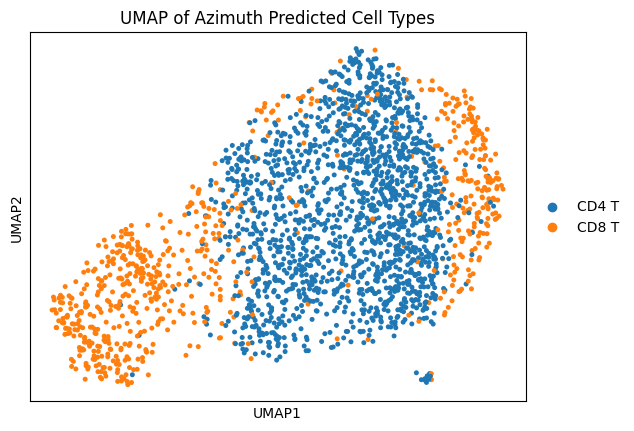

In [9]:
sc.tl.umap(adata)

sc.pl.umap(adata, color='predicted.celltype.l1', title='UMAP of Azimuth Predicted Cell Types')


In [10]:
# Step 1: Extract the adjacency matrix from the AnnData object (sparse matrix format)
adjacency_matrix_knn = adata.obsp['connectivities']  # Assuming the kNN graph is stored here (sparse matrix)

# Step 2: Convert the sparse matrix to a dense matrix and move it to PyTorch tensor
adj_matrix_dense = adjacency_matrix_knn.toarray()  # Convert to dense (NumPy array)

# Step 3: Convert the dense matrix to a PyTorch tensor and move to GPU if necessary
#device = 'cuda' if torch.cuda.is_available() else 'cpu'
adj_matrix_tensor = torch.tensor(adj_matrix_dense, dtype=torch.float32).to(device)

# Step 4: Call the optimized SimRank function with the converted adjacency matrix
sim_matrix = simrank_similarity_optimized(adj_matrix_tensor, decay_factor=0.8, device=device)

# Step 5: Convert the result back to CPU if needed
sim_matrix_cpu = sim_matrix.cpu().numpy()

# symmetrize the np array "sim_matrix_cpu"
symmetrized_raw_sim_matrix = sim_matrix_cpu + sim_matrix_cpu.transpose()

# Convert the transposed array to a Pandas DataFrame
sim_matrix_raw_df = pd.DataFrame(symmetrized_raw_sim_matrix)


# Normalize the similarity matrix
sim_matrix_raw_df_norm = sim_matrix_raw_df.div(sim_matrix_raw_df.sum(axis=1), axis=0)
#print(sim_matrix_raw_df_norm.head())

k=30
symmetrized_raw_sim_matrix_visualize = np.zeros_like(symmetrized_raw_sim_matrix)
for i in range(symmetrized_raw_sim_matrix.shape[0]):
  row = symmetrized_raw_sim_matrix[i, :]
  sorted_indices = np.argsort(row)[::-1]  # Sort in descending order
  top_k_indices = sorted_indices[:k]
  symmetrized_raw_sim_matrix_visualize[i, top_k_indices] = row[top_k_indices]

# Extract the sparse distance matrix from AnnData and SimRank similarity matrix
distances_knn = adata.obsp['distances']  # kNN distance matrix
sim_matrix_cpu = sim_matrix_cpu + sim_matrix_cpu.transpose()  # SimRank similarity matrix from the previous step

# Set k (number of most similar cells to consider)
k = 30

# Call the function to compute Gaussian kernel-based weights with SimRank intersection
weights_matrix = gaussian_kernel_weights_with_simrank(distances_knn, sim_matrix_cpu, k, device=device)

# Optionally, move the weights back to CPU and convert to NumPy for further processing
weights_matrix_cpu = weights_matrix.cpu().numpy()

# Convert both matrices to PyTorch tensors
weights_tensor = torch.tensor(weights_matrix_cpu, dtype=torch.float32)
simrank_tensor = torch.tensor(sim_matrix_cpu, dtype=torch.float32)

# Move tensors to GPU if available
weights_tensor = weights_tensor.to(device)
simrank_tensor = simrank_tensor.to(device)

# Perform element-wise multiplication using PyTorch
final_weight_tensor = weights_tensor * simrank_tensor

sim_matrix_df = pd.DataFrame(final_weight_tensor.cpu().numpy())


# Normalize the similarity matrix
sim_matrix_df_norm = sim_matrix_df.div(sim_matrix_df.sum(axis=1), axis=0)
#print(sim_matrix_df_norm.head())


## Pearson

genes

Average pairwise correlation (CD4 T markers): 0.38797102574380227
Average pairwise correlation (CD8 T markers): 0.429321057121697
Average pairwise correlation (CD4 vs CD8 markers): -0.4162181086534601
Matrix mean (all columns): 7.5691220556745185
Matrix minimum value (all columns): 0


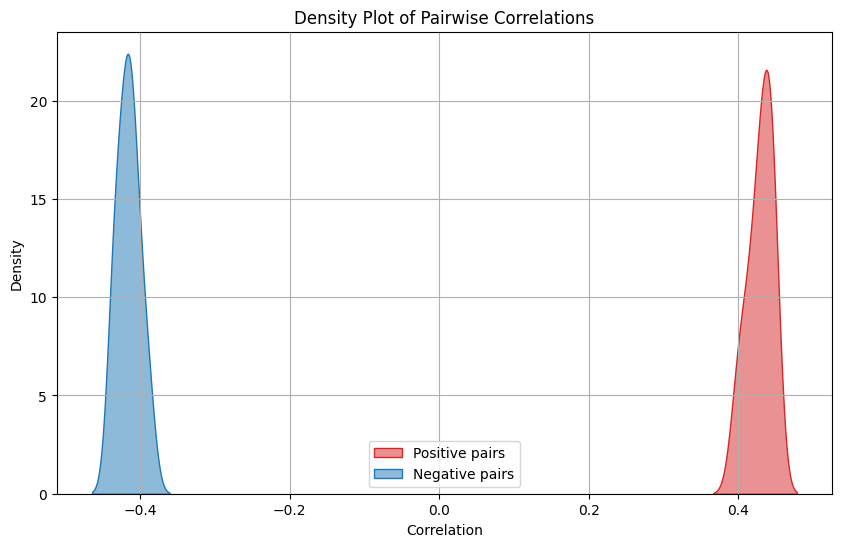

Updated matrix_combined shape: (2335, 30)


In [11]:
# Parameters
np.random.seed(42)
num_rows = len(cell_type_annotations)  # Number of rows corresponds to cells
num_columns = 10  # Number of genes
lambda_base = 5  # Mean of base matrix Poisson distribution
lambda_cd4_pos = 5  # Positive noise for CD4 markers
lambda_cd4_neg = 0.1  # Negative noise for CD8 markers
lambda_cd8_pos = 5  # Positive noise for CD8 markers
lambda_cd8_neg = 0.1  # Negative noise for CD4 markers

# Generate base matrix
base_matrix = np.random.poisson(lam=lambda_base, size=(num_rows, num_columns))

# Add cell-type-specific noise
matrix_combined = np.zeros_like(base_matrix)


for i, cell_type in enumerate(cell_types):
    if cell_type == 'CD4 T':
        matrix_combined[i, :5] = base_matrix[i, :5] + np.random.poisson(lam=lambda_cd4_pos, size=5)
        matrix_combined[i, 5:] = base_matrix[i, 5:] + np.random.poisson(lam=lambda_cd4_neg, size=5)
    elif cell_type == 'CD8 T':
        matrix_combined[i, :5] = base_matrix[i, :5] + np.random.poisson(lam=lambda_cd8_neg, size=5)
        matrix_combined[i, 5:] = base_matrix[i, 5:] + np.random.poisson(lam=lambda_cd8_pos, size=5)

# Validate pairwise correlations
pairwise_correlations_cd4 = []
for i in range(5):  # CD4 T markers (Columns 1-5)
    for j in range(i + 1, 5):  # Pairwise within CD4 T
        corr, _ = pearsonr(matrix_combined[:, i], matrix_combined[:, j])
        pairwise_correlations_cd4.append(corr)

pairwise_correlations_cd8 = []
for i in range(5, 10):  # CD8 T markers (Columns 6-10)
    for j in range(i + 1, 10):  # Pairwise within CD8 T
        corr, _ = pearsonr(matrix_combined[:, i], matrix_combined[:, j])
        pairwise_correlations_cd8.append(corr)

pairwise_correlations_cd4_cd8 = []
for i in range(2):  # CD4 T markers (Columns 1-5)
    for j in range(5, 10):  # CD8 T markers (Columns 6-10)
        corr, _ = pearsonr(matrix_combined[:, i], matrix_combined[:, j])
        pairwise_correlations_cd4_cd8.append(corr)

gene_positive = pairwise_correlations_cd8        # originally computed for CD8 T markers (columns 1-5)
gene_negative = pairwise_correlations_cd4_cd8      # originally computed for CD4 vs CD8 markers


# Print results
print("Average pairwise correlation (CD4 T markers):", np.mean(pairwise_correlations_cd4))
print("Average pairwise correlation (CD8 T markers):", np.mean(pairwise_correlations_cd8))
print("Average pairwise correlation (CD4 vs CD8 markers):", np.mean(pairwise_correlations_cd4_cd8))
print("Matrix mean (all columns):", matrix_combined.mean())
print("Matrix minimum value (all columns):", matrix_combined.min())

# Plot density plots for correlations
plt.figure(figsize=(10, 6))
#sns.kdeplot(pairwise_correlations_cd4, label="Positive pairs", color="red", fill=True, alpha=0.5)
sns.kdeplot(pairwise_correlations_cd8, label="Positive pairs", color="#d62728", fill=True, alpha=0.5)
sns.kdeplot(pairwise_correlations_cd4_cd8, label="Negative pairs", color="#1f77b4", fill=True, alpha=0.5)
plt.title("Density Plot of Pairwise Correlations")
plt.xlabel("Correlation")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

# Generate 20 Poisson-distributed noise columns
np.random.seed(5)
num_noise_columns = 20
lambda_noise = 5  # Poisson distribution mean for noise

# Generate Poisson noise columns
noise_columns = np.random.poisson(lam=lambda_noise, size=(num_rows, num_noise_columns))

# Adjust noise columns to have the same mean as the existing matrix
current_noise_mean = noise_columns.mean()
matrix_mean = matrix_combined.mean()
noise_columns = noise_columns + (matrix_mean - current_noise_mean)  # Shift mean to match matrix_combined

# Ensure all values remain positive
noise_columns = np.clip(noise_columns, a_min=1, a_max=None)

# Concatenate noise columns with the existing matrix
matrix_combined_gene = np.hstack([matrix_combined, noise_columns])

# Verify the shape of the updated matrix
print("Updated matrix_combined shape:", matrix_combined_gene.shape)


isoforms

Average pairwise correlation (CD4 T markers): 0.165778081091724
Average pairwise correlation (CD8 T markers): 0.20529663059553727
Average pairwise correlation (CD4 vs CD8 markers): -0.19510552569348893
Matrix mean (all columns): 2.519557458957887
Matrix minimum value (all columns): 0


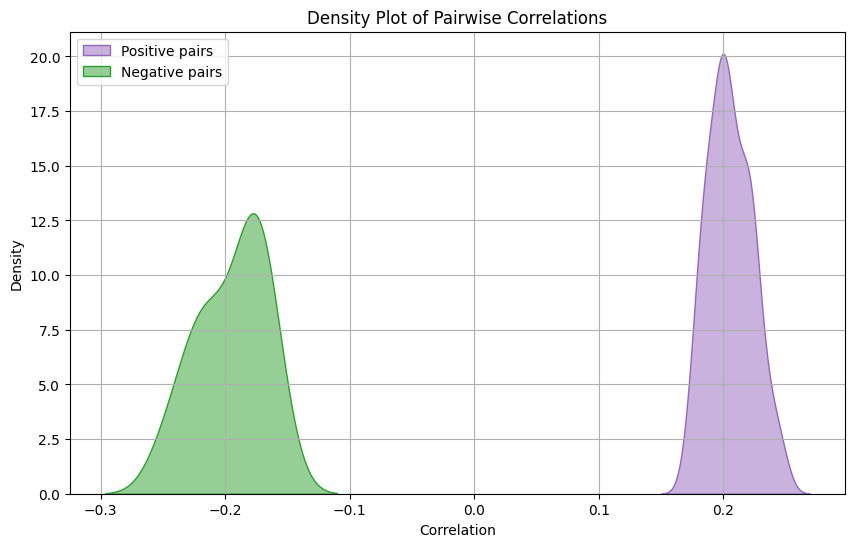

Updated matrix_combined shape: (2335, 90)


In [12]:
# Parameters
np.random.seed(42)
num_rows = len(cell_type_annotations)  # Number of rows corresponds to cells
num_columns = 30  # Number of genes
lambda_base = 5/3  # Mean of base matrix Poisson distribution
lambda_cd4_pos = 5/3  # Positive noise for CD4 markers
lambda_cd4_neg = 0.1/3  # Negative noise for CD8 markers
lambda_cd8_pos = 5/3  # Positive noise for CD8 markers
lambda_cd8_neg = 0.1/3  # Negative noise for CD4 markers

# Generate base matrix
base_matrix = np.random.poisson(lam=lambda_base, size=(num_rows, num_columns))

# Add cell-type-specific noise
matrix_combined = np.zeros_like(base_matrix)


for i, cell_type in enumerate(cell_types):
    if cell_type == 'CD4 T':
        matrix_combined[i, :15] = base_matrix[i, :15] + np.random.poisson(lam=lambda_cd4_pos, size=15)
        matrix_combined[i, 15:] = base_matrix[i, 15:] + np.random.poisson(lam=lambda_cd4_neg, size=15)
    elif cell_type == 'CD8 T':
        matrix_combined[i, :15] = base_matrix[i, :15] + np.random.poisson(lam=lambda_cd8_neg, size=15)
        matrix_combined[i, 15:] = base_matrix[i, 15:] + np.random.poisson(lam=lambda_cd8_pos, size=15)

# Validate pairwise correlations
pairwise_correlations_cd4 = []
for i in range(15):  # CD4 T markers (Columns 1-15)
    for j in range(i + 1, 15):  # Pairwise within CD4 T
        corr, _ = pearsonr(matrix_combined[:, i], matrix_combined[:, j])
        pairwise_correlations_cd4.append(corr)

pairwise_correlations_cd8 = []
for i in range(15, 30):  # CD8 T markers (Columns 15-30)
    for j in range(i + 1, 30):  # Pairwise within CD8 T
        corr, _ = pearsonr(matrix_combined[:, i], matrix_combined[:, j])
        pairwise_correlations_cd8.append(corr)

pairwise_correlations_cd4_cd8 = []
for i in range(2):  # CD4 T markers (Columns 1-15)
    for j in range(15, 20):  # CD8 T markers (Columns 15-30)
        corr, _ = pearsonr(matrix_combined[:, i], matrix_combined[:, j])
        pairwise_correlations_cd4_cd8.append(corr)

isoform_positive = pairwise_correlations_cd8       # from isoform simulation (columns 15-30)
isoform_negative = pairwise_correlations_cd4_cd8     # from isoform simulation (subset, e.g., Columns 1-15 vs 15-20)

# Print results
print("Average pairwise correlation (CD4 T markers):", np.mean(pairwise_correlations_cd4))
print("Average pairwise correlation (CD8 T markers):", np.mean(pairwise_correlations_cd8))
print("Average pairwise correlation (CD4 vs CD8 markers):", np.mean(pairwise_correlations_cd4_cd8))
print("Matrix mean (all columns):", matrix_combined.mean())
print("Matrix minimum value (all columns):", matrix_combined.min())

# Plot density plots for correlations
plt.figure(figsize=(10, 6))
#sns.kdeplot(pairwise_correlations_cd4, label="Positive pairs", color="red", fill=True, alpha=0.5)
sns.kdeplot(pairwise_correlations_cd8, label="Positive pairs", color="#9467bd", fill=True, alpha=0.5)
sns.kdeplot(pairwise_correlations_cd4_cd8, label="Negative pairs", color="#2ca02c", fill=True, alpha=0.5)
plt.title("Density Plot of Pairwise Correlations")
plt.xlabel("Correlation")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

# Generate 20 Poisson-distributed noise columns
np.random.seed(5)
num_noise_columns = 60
lambda_noise = 5  # Poisson distribution mean for noise

# Generate Poisson noise columns
noise_columns = np.random.poisson(lam=lambda_noise, size=(num_rows, num_noise_columns))

# Adjust noise columns to have the same mean as the existing matrix
current_noise_mean = noise_columns.mean()
matrix_mean = matrix_combined.mean()
noise_columns = noise_columns + (matrix_mean - current_noise_mean)  # Shift mean to match matrix_combined

# Ensure all values remain positive
noise_columns = np.clip(noise_columns, a_min=1, a_max=None)

# Concatenate noise columns with the existing matrix
matrix_combined_isoform = np.hstack([matrix_combined, noise_columns])

# Verify the shape of the updated matrix
print("Updated matrix_combined shape:", matrix_combined_isoform.shape)

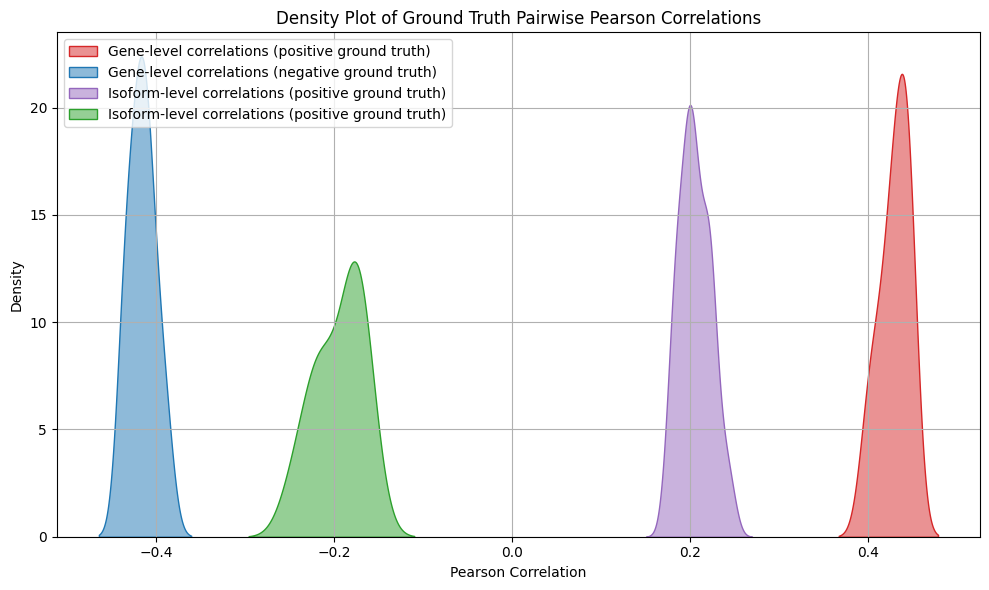

In [13]:
# ----- After computing pairwise correlations for Gene and Isoform levels -----


# Merge the density plots.
plt.figure(figsize=(10, 6))

# Gene-level curves:
sns.kdeplot(gene_positive, label="Gene-level correlations (positive ground truth)", color="#d62728", fill=True, alpha=0.5)
sns.kdeplot(gene_negative, label="Gene-level correlations (negative ground truth)", color="#1f77b4", fill=True, alpha=0.5)

# Isoform-level curves:
sns.kdeplot(isoform_positive, label="Isoform-level correlations (positive ground truth)", color="#9467bd", fill=True, alpha=0.5)
sns.kdeplot(isoform_negative, label="Isoform-level correlations (positive ground truth)", color="#2ca02c", fill=True, alpha=0.5)

plt.title("Density Plot of Ground Truth Pairwise Pearson Correlations")
plt.xlabel("Pearson Correlation")
plt.ylabel("Density")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
# Calculate correlation
corr, _ = pearsonr(matrix_combined_isoform[:, 0], matrix_combined_isoform[:, 2])



ground truth


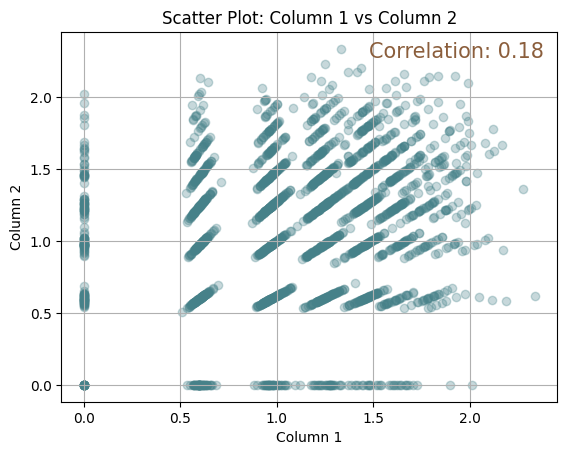

In [15]:
# Scatter plot of Column 1 vs. Column 2
# Calculate correlation
# Normalize rows to sum to 1 (convert to probabilities)
row_sums = matrix_combined_isoform.sum(axis=1, keepdims=True)
prob_matrix = matrix_combined_isoform / row_sums

print("ground truth")


dense_matrix = prob_matrix*200 # set scale parameter to 20
dense_matrix = np.log1p(dense_matrix)

corr, _ = pearsonr(dense_matrix[:, 0], dense_matrix[:, 2])

plt.scatter(dense_matrix[:, 0], dense_matrix[:, 2], color="#468189", alpha=0.3)
plt.title("Scatter Plot: Column 1 vs Column 2")
plt.xlabel("Column 1")
plt.ylabel("Column 2")
# Add correlation text to the plot
plt.text(
    0.62, 0.93,  # Position: x and y coordinates in figure-relative units
    f"Correlation: {corr:.2f}",  # Display correlation rounded to 2 decimal places
    fontsize=15, color="#8B5E3C", transform=plt.gca().transAxes  # Style and position
)

plt.grid(True)
plt.show()

sparse data


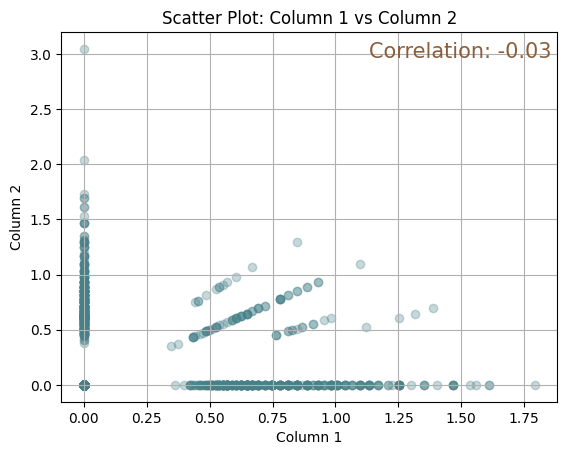

In [16]:
# Normalize rows to sum to 1 (convert to probabilities)
row_sums = matrix_combined_isoform.sum(axis=1, keepdims=True)
prob_matrix = matrix_combined_isoform / row_sums

# Total count per row (controls sparsity)
#total_counts = 20  # Lower values result in sparser data

# Simulate sparse data using multinomial distribution
#sparse_matrix = np.array([np.random.multinomial(total_counts, prob_row) for prob_row in prob_matrix])

print("sparse data")

total_counts = np.random.normal(loc=20, scale=8, size=len(prob_matrix))
total_counts = np.clip(total_counts, a_min=1, a_max=None).astype(int)  # Ensure counts are positive integers

# Simulate sparse data
sparse_matrix = np.array([
    np.random.multinomial(tc, prob_row) for tc, prob_row in zip(total_counts, prob_matrix)
])

# Simulate normalization
sparse_matrix = sparse_matrix / total_counts[:, np.newaxis]
sparse_matrix = sparse_matrix*20 # set scale parameter to 20
sparse_matrix = np.log1p(sparse_matrix)

# Parameters for random noise
#noise_mean = 0  # Mean of the noise
#noise_std = 0.3  # Standard deviation of the noise

# Add noise to non-zero values
#noise = np.random.normal(noise_mean, noise_std, sparse_matrix.shape)  # Generate noise
#noisy_sparse_matrix = sparse_matrix + (sparse_matrix != 0) * noise  # Add noise to non-zero entries
noisy_sparse_matrix = sparse_matrix
# Calculate correlation
corr, _ = pearsonr(noisy_sparse_matrix[:, 0], noisy_sparse_matrix[:, 2])

# Scatter plot of Column 1 vs. Column 5
plt.scatter(noisy_sparse_matrix[:, 0], noisy_sparse_matrix[:, 2], color="#468189", alpha=0.3)
plt.title("Scatter Plot: Column 1 vs Column 2")
plt.xlabel("Column 1")
plt.ylabel("Column 2")

# Add correlation text to the plot
plt.text(
    0.62, 0.93,  # Position: x and y coordinates in figure-relative units
    f"Correlation: {corr:.2f}",  # Display correlation rounded to 2 decimal places
    fontsize=15, color="#8B5E3C", transform=plt.gca().transAxes  # Style and position
)

plt.grid(True)
plt.show()

In [17]:
# Scatter plot of Column 1 vs. Column 16
# Calculate correlation
corr, _ = pearsonr(matrix_combined_isoform[:, 0], matrix_combined_isoform[:, 15])



ground truth


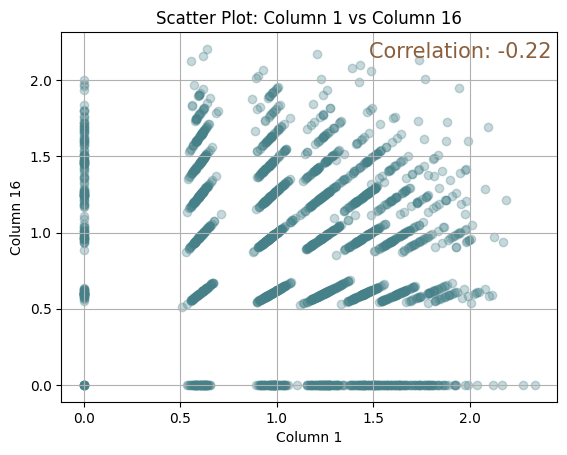

In [18]:
# Scatter plot of Column 1 vs. Column 16
# Calculate correlation
# Normalize rows to sum to 1 (convert to probabilities)
row_sums = matrix_combined_isoform.sum(axis=1, keepdims=True)
prob_matrix = matrix_combined_isoform / row_sums

print("ground truth")

dense_matrix = prob_matrix*200 # set scale parameter to 20
dense_matrix = np.log1p(dense_matrix)

corr, _ = pearsonr(dense_matrix[:, 0], dense_matrix[:, 17])

plt.scatter(dense_matrix[:, 0], dense_matrix[:, 17], color="#468189", alpha=0.3)
plt.title("Scatter Plot: Column 1 vs Column 16")
plt.xlabel("Column 1")
plt.ylabel("Column 16")
# Add correlation text to the plot
plt.text(
    0.62, 0.93,  # Position: x and y coordinates in figure-relative units
    f"Correlation: {corr:.2f}",  # Display correlation rounded to 2 decimal places
    fontsize=15, color="#8B5E3C", transform=plt.gca().transAxes  # Style and position
)

plt.grid(True)
plt.show()

sparse data


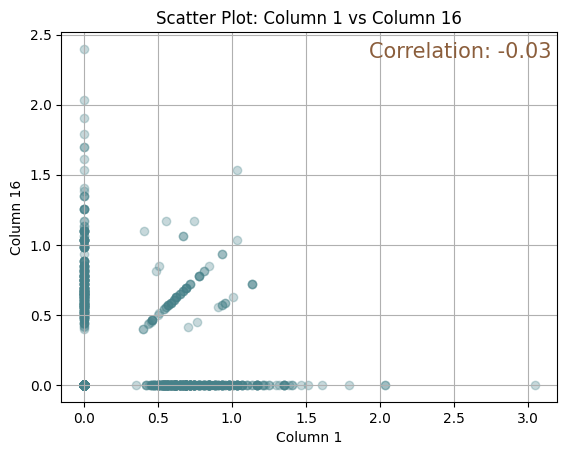

In [19]:
# Normalize rows to sum to 1 (convert to probabilities)
row_sums = matrix_combined_isoform.sum(axis=1, keepdims=True)
prob_matrix = matrix_combined_isoform / row_sums

# Total count per row (controls sparsity)
#total_counts = 20  # Lower values result in sparser data

# Simulate sparse data using multinomial distribution
#sparse_matrix = np.array([np.random.multinomial(total_counts, prob_row) for prob_row in prob_matrix])

total_counts = np.random.normal(loc=20, scale=8, size=len(prob_matrix))
total_counts = np.clip(total_counts, a_min=1, a_max=None).astype(int)  # Ensure counts are positive integers

# Simulate sparse data
sparse_matrix = np.array([
    np.random.multinomial(tc, prob_row) for tc, prob_row in zip(total_counts, prob_matrix)
])

# normalization
sparse_matrix = sparse_matrix / total_counts[:, np.newaxis]
sparse_matrix = sparse_matrix*20
sparse_matrix = np.log1p(sparse_matrix)

print("sparse data")

# Parameters for random noise
#noise_mean = 0  # Mean of the noise
#noise_std = 0.2  # Standard deviation of the noise

# Add noise to non-zero values
#noise = np.random.normal(noise_mean, noise_std, sparse_matrix.shape)  # Generate noise
#noisy_sparse_matrix = sparse_matrix + (sparse_matrix != 0) * noise  # Add noise to non-zero entries
noisy_sparse_matrix = sparse_matrix

# Calculate correlation
corr, _ = pearsonr(noisy_sparse_matrix[:, 0], noisy_sparse_matrix[:, 15])

# Scatter plot of Column 1 vs. Column 5
plt.scatter(noisy_sparse_matrix[:, 0], noisy_sparse_matrix[:, 15], color="#468189", alpha=0.3)
plt.title("Scatter Plot: Column 1 vs Column 16")
plt.xlabel("Column 1")
plt.ylabel("Column 16")
# Add correlation text to the plot
plt.text(
    0.62, 0.93,  # Position: x and y coordinates in figure-relative units
    f"Correlation: {corr:.2f}",  # Display correlation rounded to 2 decimal places
    fontsize=15, color="#8B5E3C", transform=plt.gca().transAxes  # Style and position
)

plt.grid(True)
plt.show()

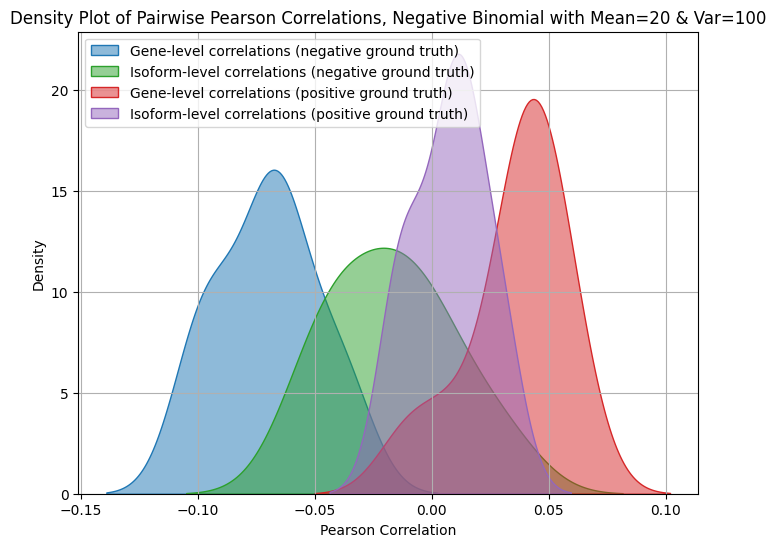

In [20]:



# Initialize a figure
plt.figure(figsize=(8, 6))

mean_count = 20
var_count = 100

matrices = [matrix_combined_gene, matrix_combined_isoform]
colors_1 = ['#1f77b4', '#2ca02c']

np.random.seed(7)
for matrix, color in zip(matrices, colors_1):

    ## Normalize rows to sum to 1 (convert to probabilities)
    row_sums = matrix.sum(axis=1, keepdims=True)
    prob_matrix = matrix / row_sums

    # 1. Solve for n
    #    var = mu + mu^2/n  =>  n = mu^2 / (var - mu)
    mu = mean_count
    var = var_count

    # Check that var > mu to avoid negative/zero n
    if var <= mu:
        raise ValueError(f"Variance {var} must be > mean {mu} for a valid Negative Binomial.")

    n_float = mu**2 / (var - mu)
    # n should be > 0
    if n_float <= 0:
        raise ValueError("Computed n is not positive. Check your mean/variance inputs.")

    # 2. Solve for p
    p = n_float / (mu + n_float)

    # For np.random.negative_binomial, n must be an integer "number of successes",
    # but non-integer n is also allowed if we interpret it as a 'shape parameter'.
    # We'll pass n as float but in practice the RNG in older versions might expect int.
    # If needed, you can keep it as float: `np.random.negative_binomial(n_float, p, size=...)`
    # or round it. The float approach is typically fine in modern NumPy.

    total_counts = np.random.negative_binomial(n_float, p, size=len(prob_matrix))

    # Ensure total counts are at least 1
    total_counts = np.clip(total_counts, a_min=1, a_max=None).astype(int)

    # Simulate sparse data
    sparse_matrix = np.array([
        np.random.multinomial(tc, prob_row)
        for tc, prob_row in zip(total_counts, prob_matrix)
    ])
    # Normalization steps
    sparse_matrix = sparse_matrix / total_counts[:, np.newaxis]  # fraction of each row
    sparse_matrix = sparse_matrix * mu                            # scale by mu
    sparse_matrix = np.log1p(sparse_matrix)

    if color == '#2ca02c':
        # Calculate pairwise correlations (example: columns [0..1] vs. [5..9])
        correlations = []
        for i in range(2):  # columns 0,1
            for j in range(15, 20):  # columns 5..9
                corr, _ = pearsonr(sparse_matrix[:, i], sparse_matrix[:, j])
                correlations.append(corr)
        label = "Isoform-level correlations (negative ground truth)"
    elif color == '#1f77b4':
        # Calculate pairwise correlations (example: columns [0..1] vs. [5..9])
        correlations = []
        for i in range(2):  # columns 0,1
            for j in range(5, 10):  # columns 5..9
                corr, _ = pearsonr(sparse_matrix[:, i], sparse_matrix[:, j])
                correlations.append(corr)
        label = "Gene-level correlations (negative ground truth)"
    sns.kdeplot(correlations, label=label, color=color, fill=True, alpha=0.5)


# -----------------------------------------------------------------------
# Example second block with new sets of (mean, variance) and new colors.
# -----------------------------------------------------------------------

mean_count = 20
var_count = 100

matrices = [matrix_combined_gene, matrix_combined_isoform]
colors_2 = ['#d62728', '#9467bd']

np.random.seed(10)
for matrix, color in zip(matrices, colors_2):

    ## Normalize rows to sum to 1 (convert to probabilities)
    row_sums = matrix.sum(axis=1, keepdims=True)
    prob_matrix = matrix / row_sums

    mu = mean_count
    var = var_count
    if var <= mu:
        raise ValueError(f"Variance {var} must be > mean {mu} for a valid Negative Binomial.")

    n_float = mu**2 / (var - mu)
    p = n_float / (mu + n_float)

    total_counts = np.random.negative_binomial(n_float, p, size=len(prob_matrix))
    total_counts = np.clip(total_counts, a_min=1, a_max=None).astype(int)

    sparse_matrix = np.array([
        np.random.multinomial(tc, prob_row)
        for tc, prob_row in zip(total_counts, prob_matrix)
    ])
    sparse_matrix = sparse_matrix / total_counts[:, np.newaxis]
    sparse_matrix = sparse_matrix * mu
    sparse_matrix = np.log1p(sparse_matrix)



    if color == '#9467bd':
        # Calculate pairwise correlations among columns 5..9
        correlations = []
        for i in range(15, 20):
            for j in range(i+1, 20):
                corr, _ = pearsonr(sparse_matrix[:, i], sparse_matrix[:, j])
                correlations.append(corr)
        label = "Isoform-level correlations (positive ground truth)"
    elif color == '#d62728':
        # Calculate pairwise correlations among columns 5..9
        correlations = []
        for i in range(5, 10):
            for j in range(i+1, 10):
                corr, _ = pearsonr(sparse_matrix[:, i], sparse_matrix[:, j])
                correlations.append(corr)
        label = "Gene-level correlations (positive ground truth)"
    sns.kdeplot(correlations, label=label, color=color, fill=True, alpha=0.5)


# Customize plot
plt.title("Density Plot of Pairwise Pearson Correlations, Negative Binomial with Mean=20 & Var=100")
plt.xlabel("Pearson Correlation")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

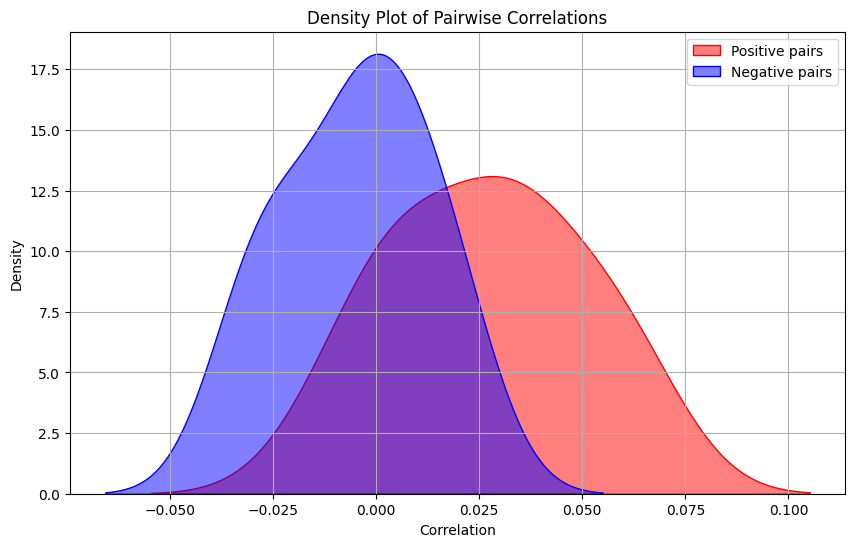

AnnData object with n_obs × n_vars = 2335 × 90
    obs: 'predicted.celltype.l1'
Expression matrix shape: (2335, 90)
Cell metadata (obs):
                   predicted.celltype.l1
AAACCCATCAGATGCT-1                 CD4 T
AAACGAAAGTGCTACT-1                 CD4 T
AAACGAAGTTGCCAAT-1                 CD8 T
AAACGAATCTCGCCTA-1                 CD8 T
AAACGCTAGGTTGCCC-1                 CD8 T
Gene metadata (var):
Empty DataFrame
Columns: []
Index: [Gene_1, Gene_2, Gene_3, Gene_4, Gene_5]


In [21]:
row_sums = matrix_combined_isoform.sum(axis=1, keepdims=True)
prob_matrix = matrix_combined_isoform / row_sums

mu = 20
var = 100

# Check that var > mu to avoid negative/zero n
if var <= mu:
    raise ValueError(f"Variance {var} must be > mean {mu} for a valid Negative Binomial.")

n_float = mu**2 / (var - mu)
# n should be > 0
if n_float <= 0:
    raise ValueError("Computed n is not positive. Check your mean/variance inputs.")

# 2. Solve for p
p = n_float / (mu + n_float)

# For np.random.negative_binomial, n must be an integer "number of successes",
# but non-integer n is also allowed if we interpret it as a 'shape parameter'.
# We'll pass n as float but in practice the RNG in older versions might expect int.
# If needed, you can keep it as float: `np.random.negative_binomial(n_float, p, size=...)`
# or round it. The float approach is typically fine in modern NumPy.

np.random.seed(3)

total_counts = np.random.negative_binomial(n_float, p, size=len(prob_matrix))

# Ensure total counts are at least 1
total_counts = np.clip(total_counts, a_min=1, a_max=None).astype(int)

# Simulate sparse data
sparse_matrix = np.array([
     np.random.multinomial(tc, prob_row) for tc, prob_row in zip(total_counts, prob_matrix)
  ])
sparse_matrix = sparse_matrix / total_counts[:, np.newaxis]
sparse_matrix = sparse_matrix*100 # set total count to 100, make it equivalent to the normalization step post refinement
sparse_matrix = np.log1p(sparse_matrix)

# Validate pairwise correlations

pairwise_correlations_cd8 = []
for i in range(15, 20):  # CD8 T markers (Columns 16-30)
    for j in range(i + 1, 20):  # Pairwise within CD8 T
        corr, _ = pearsonr(sparse_matrix[:, i], sparse_matrix[:, j])
        pairwise_correlations_cd8.append(corr)

pairwise_correlations_cd4_cd8 = []
for i in range(2):  # CD4 T markers (Columns 1-15)
    for j in range(15, 20):  # CD8 T markers (Columns 16-30)
        corr, _ = pearsonr(sparse_matrix[:, i], sparse_matrix[:, j])
        pairwise_correlations_cd4_cd8.append(corr)


# Plot density plots for correlations
plt.figure(figsize=(10, 6))
#sns.kdeplot(pairwise_correlations_cd4, label="Positive pairs", color="red", fill=True, alpha=0.5)
sns.kdeplot(pairwise_correlations_cd8, label="Positive pairs", color="red", fill=True, alpha=0.5)
sns.kdeplot(pairwise_correlations_cd4_cd8, label="Negative pairs", color="blue", fill=True, alpha=0.5)
plt.title("Density Plot of Pairwise Correlations")
plt.xlabel("Correlation")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

# Example gene names and cell metadata
gene_names = [f"Gene_{i+1}" for i in range(sparse_matrix.shape[1])]  # Column names
cell_metadata = cell_type_annotations  # Use cell_type_annotations as obs

# Convert sparse_matrix to an AnnData object
adata = anndata.AnnData(
    X=sparse_matrix,  # Expression matrix
    obs=pd.DataFrame(cell_metadata),  # Cell metadata
    var=pd.DataFrame(index=gene_names)  # Gene names as variable metadata
)



# Inspect the AnnData object
print(adata)

# Example: Accessing the data
print("Expression matrix shape:", adata.X.shape)
print("Cell metadata (obs):")
print(adata.obs.head())
print("Gene metadata (var):")
print(adata.var.head())

In [22]:
new_matrix, P_final = rwr_impute(sim_matrix_df_norm, adata, alpha=0.3, max_iter=100, tol=1e-4, device=device)

Random walk with restart converged in 18 iterations.


In [23]:
adata_new = adata.copy()
adata_new.X = new_matrix

# Perform the same analysis as before with adata_transcript_new
sc.pp.normalize_total(adata_new, target_sum=1e2)
sc.pp.log1p(adata_new)

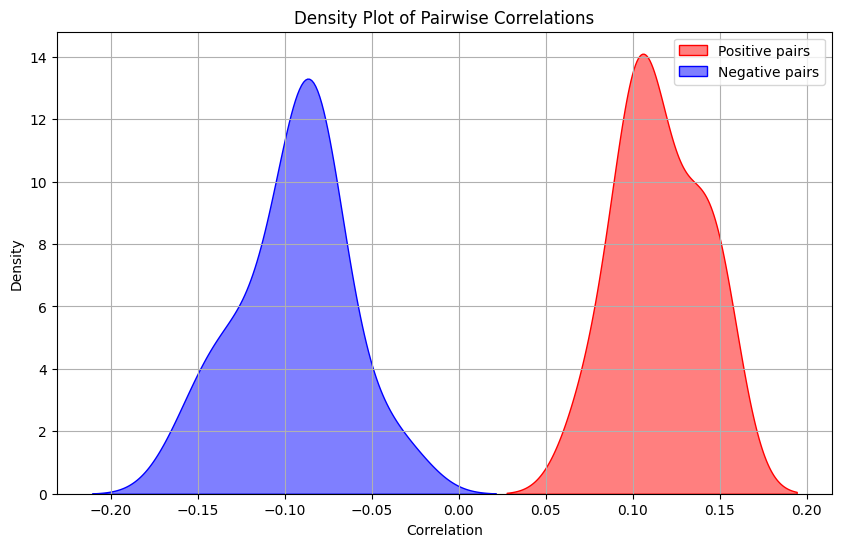

In [24]:
final_matrix = adata_new.X

# Validate pairwise correlations

pairwise_correlations_cd8 = []
for i in range(15, 20):  # CD8 T markers (Columns 6-10)
    for j in range(i + 1, 20):  # Pairwise within CD8 T
        corr, _ = pearsonr(final_matrix[:, i], final_matrix[:, j])
        pairwise_correlations_cd8.append(corr)

pairwise_correlations_cd4_cd8 = []
for i in range(5):  # CD4 T markers (Columns 1-5)
    for j in range(15, 20):  # CD8 T markers (Columns 6-10)
        corr, _ = pearsonr(final_matrix[:, i], final_matrix[:, j])
        pairwise_correlations_cd4_cd8.append(corr)


# Plot density plots for correlations
plt.figure(figsize=(10, 6))
#sns.kdeplot(pairwise_correlations_cd4, label="Positive pairs", color="red", fill=True, alpha=0.5)
sns.kdeplot(pairwise_correlations_cd8, label="Positive pairs", color="red", fill=True, alpha=0.5)
sns.kdeplot(pairwise_correlations_cd4_cd8, label="Negative pairs", color="blue", fill=True, alpha=0.5)
plt.title("Density Plot of Pairwise Correlations")
plt.xlabel("Correlation")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

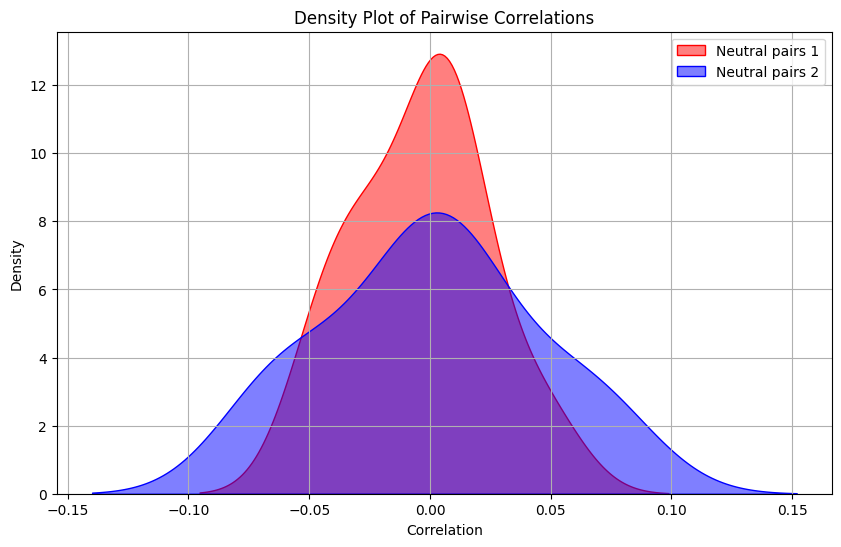

In [25]:
final_matrix = adata_new.X

# Validate pairwise correlations

pairwise_correlations_cd8 = []
for i in range(15, 18):  # CD8 T markers (Columns 6-10)
    for j in range(30, 35):  # General T markers
        corr, _ = pearsonr(final_matrix[:, i], final_matrix[:, j])
        pairwise_correlations_cd8.append(corr)

pairwise_correlations_cd4_cd8 = []
for i in range(3):  # CD4 T markers (Columns 1-5)
    for j in range(30, 35):  # General T markers
        corr, _ = pearsonr(final_matrix[:, i], final_matrix[:, j])
        pairwise_correlations_cd4_cd8.append(corr)


# Plot density plots for correlations
plt.figure(figsize=(10, 6))
#sns.kdeplot(pairwise_correlations_cd4, label="Positive pairs", color="red", fill=True, alpha=0.5)
sns.kdeplot(pairwise_correlations_cd8, label="Neutral pairs 1", color="red", fill=True, alpha=0.5)
sns.kdeplot(pairwise_correlations_cd4_cd8, label="Neutral pairs 2", color="blue", fill=True, alpha=0.5)
plt.title("Density Plot of Pairwise Correlations")
plt.xlabel("Correlation")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

## Spearman

gene

Average pairwise correlation (CD4 T markers): 0.42150337482532263
Average pairwise correlation (CD8 T markers): 0.39914996226402655
Average pairwise correlation (CD4 vs CD8 markers): -0.41675189653858363
Matrix mean (all columns): 7.5691220556745185
Matrix minimum value (all columns): 0


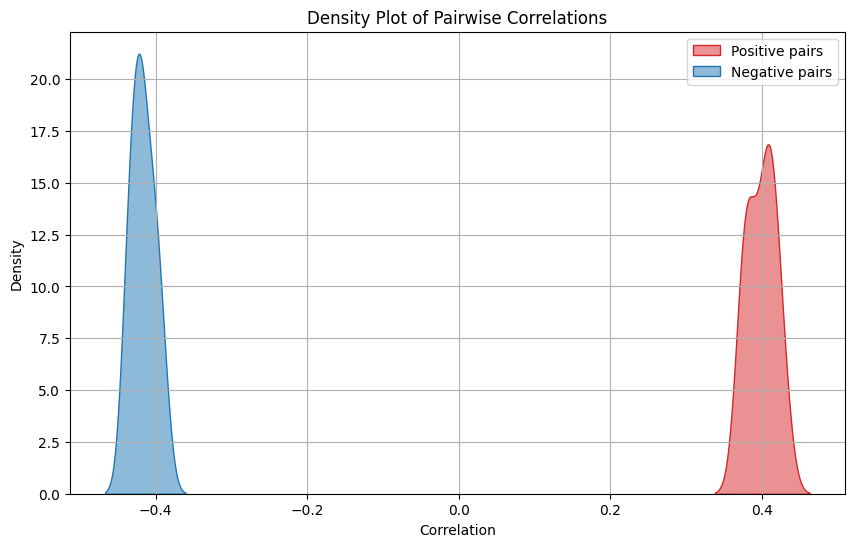

Updated matrix_combined shape: (2335, 30)


In [26]:
# Parameters
np.random.seed(42)
num_rows = len(cell_type_annotations)  # Number of rows corresponds to cells
num_columns = 10  # Number of genes
lambda_base = 5  # Mean of base matrix Poisson distribution
lambda_cd4_pos = 5  # Positive noise for CD4 markers
lambda_cd4_neg = 0.1  # Negative noise for CD8 markers
lambda_cd8_pos = 5  # Positive noise for CD8 markers
lambda_cd8_neg = 0.1  # Negative noise for CD4 markers

# Generate base matrix
base_matrix = np.random.poisson(lam=lambda_base, size=(num_rows, num_columns))

# Add cell-type-specific noise
matrix_combined = np.zeros_like(base_matrix)


for i, cell_type in enumerate(cell_types):
    if cell_type == 'CD4 T':
        matrix_combined[i, :5] = base_matrix[i, :5] + np.random.poisson(lam=lambda_cd4_pos, size=5)
        matrix_combined[i, 5:] = base_matrix[i, 5:] + np.random.poisson(lam=lambda_cd4_neg, size=5)
    elif cell_type == 'CD8 T':
        matrix_combined[i, :5] = base_matrix[i, :5] + np.random.poisson(lam=lambda_cd8_neg, size=5)
        matrix_combined[i, 5:] = base_matrix[i, 5:] + np.random.poisson(lam=lambda_cd8_pos, size=5)

# Validate pairwise correlations
pairwise_correlations_cd4 = []
for i in range(5):  # CD4 T markers (Columns 1-5)
    for j in range(i + 1, 5):  # Pairwise within CD4 T
        corr, _ = spearmanr(matrix_combined[:, i], matrix_combined[:, j])
        pairwise_correlations_cd4.append(corr)

pairwise_correlations_cd8 = []
for i in range(5, 10):  # CD8 T markers (Columns 6-10)
    for j in range(i + 1, 10):  # Pairwise within CD8 T
        corr, _ = spearmanr(matrix_combined[:, i], matrix_combined[:, j])
        pairwise_correlations_cd8.append(corr)

pairwise_correlations_cd4_cd8 = []
for i in range(2):  # CD4 T markers (Columns 1-5)
    for j in range(5, 10):  # CD8 T markers (Columns 6-10)
        corr, _ = spearmanr(matrix_combined[:, i], matrix_combined[:, j])
        pairwise_correlations_cd4_cd8.append(corr)

gene_positive = pairwise_correlations_cd8        # originally computed for CD8 T markers (columns 1-5)
gene_negative = pairwise_correlations_cd4_cd8      # originally computed for CD4 vs CD8 markers


# Print results
print("Average pairwise correlation (CD4 T markers):", np.mean(pairwise_correlations_cd4))
print("Average pairwise correlation (CD8 T markers):", np.mean(pairwise_correlations_cd8))
print("Average pairwise correlation (CD4 vs CD8 markers):", np.mean(pairwise_correlations_cd4_cd8))
print("Matrix mean (all columns):", matrix_combined.mean())
print("Matrix minimum value (all columns):", matrix_combined.min())

# Plot density plots for correlations
plt.figure(figsize=(10, 6))
#sns.kdeplot(pairwise_correlations_cd4, label="Positive pairs", color="red", fill=True, alpha=0.5)
sns.kdeplot(pairwise_correlations_cd8, label="Positive pairs", color="#d62728", fill=True, alpha=0.5)
sns.kdeplot(pairwise_correlations_cd4_cd8, label="Negative pairs", color="#1f77b4", fill=True, alpha=0.5)
plt.title("Density Plot of Pairwise Correlations")
plt.xlabel("Correlation")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

# Generate 20 Poisson-distributed noise columns
np.random.seed(5)
num_noise_columns = 20
lambda_noise = 5  # Poisson distribution mean for noise

# Generate Poisson noise columns
noise_columns = np.random.poisson(lam=lambda_noise, size=(num_rows, num_noise_columns))

# Adjust noise columns to have the same mean as the existing matrix
current_noise_mean = noise_columns.mean()
matrix_mean = matrix_combined.mean()
noise_columns = noise_columns + (matrix_mean - current_noise_mean)  # Shift mean to match matrix_combined

# Ensure all values remain positive
noise_columns = np.clip(noise_columns, a_min=1, a_max=None)

# Concatenate noise columns with the existing matrix
matrix_combined_gene = np.hstack([matrix_combined, noise_columns])

# Verify the shape of the updated matrix
print("Updated matrix_combined shape:", matrix_combined_gene.shape)


isoform

Average pairwise correlation (CD4 T markers): 0.11553371101319296
Average pairwise correlation (CD8 T markers): 0.12029734433594864
Average pairwise correlation (CD4 vs CD8 markers): -0.12171210357678472
Matrix mean (all columns): 2.667751605995717
Matrix minimum value (all columns): 0


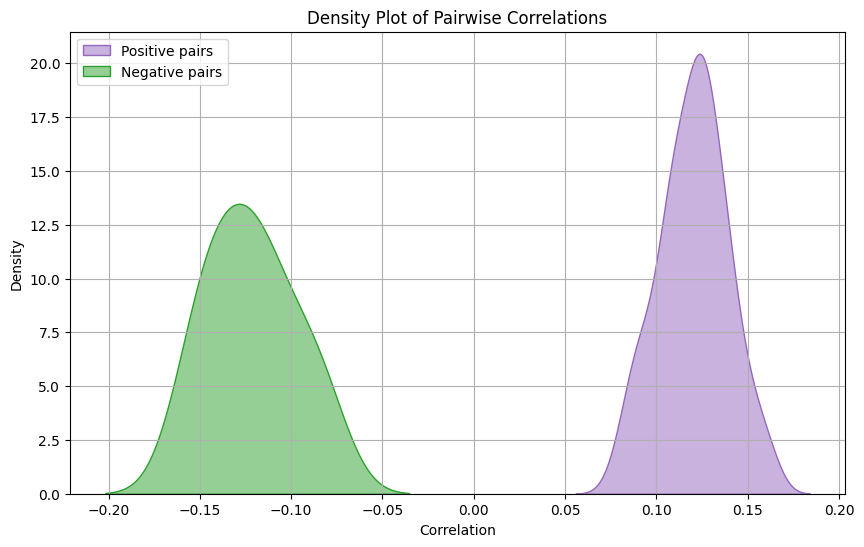

Updated matrix_combined shape: (2335, 90)


In [27]:
# Parameters
np.random.seed(42)
num_rows = len(cell_type_annotations)  # Number of rows corresponds to cells
num_columns = 30  # Number of genes
lambda_base = 5/3  # Mean of base matrix Poisson distribution
lambda_cd4_pos = 5/3  # Positive noise for CD4 markers
lambda_cd4_neg = 1/3  # Negative noise for CD8 markers
lambda_cd8_pos = 5/3  # Positive noise for CD8 markers
lambda_cd8_neg = 1/3  # Negative noise for CD4 markers

# Generate base matrix
base_matrix = np.random.poisson(lam=lambda_base, size=(num_rows, num_columns))

# Add cell-type-specific noise
matrix_combined = np.zeros_like(base_matrix)


for i, cell_type in enumerate(cell_types):
    if cell_type == 'CD4 T':
        matrix_combined[i, :15] = base_matrix[i, :15] + np.random.poisson(lam=lambda_cd4_pos, size=15)
        matrix_combined[i, 15:] = base_matrix[i, 15:] + np.random.poisson(lam=lambda_cd4_neg, size=15)
    elif cell_type == 'CD8 T':
        matrix_combined[i, :15] = base_matrix[i, :15] + np.random.poisson(lam=lambda_cd8_neg, size=15)
        matrix_combined[i, 15:] = base_matrix[i, 15:] + np.random.poisson(lam=lambda_cd8_pos, size=15)

# Validate pairwise correlations
pairwise_correlations_cd4 = []
for i in range(15):  # CD4 T markers (Columns 1-15)
    for j in range(i + 1, 15):  # Pairwise within CD4 T
        corr, _ = spearmanr(matrix_combined[:, i], matrix_combined[:, j])
        pairwise_correlations_cd4.append(corr)

pairwise_correlations_cd8 = []
for i in range(15, 30):  # CD8 T markers (Columns 15-30)
    for j in range(i + 1, 30):  # Pairwise within CD8 T
        corr, _ = spearmanr(matrix_combined[:, i], matrix_combined[:, j])
        pairwise_correlations_cd8.append(corr)

pairwise_correlations_cd4_cd8 = []
for i in range(2):  # CD4 T markers (Columns 1-15)
    for j in range(15, 20):  # CD8 T markers (Columns 15-30)
        corr, _ = spearmanr(matrix_combined[:, i], matrix_combined[:, j])
        pairwise_correlations_cd4_cd8.append(corr)

isoform_positive = pairwise_correlations_cd8       # from isoform simulation (columns 15-30)
isoform_negative = pairwise_correlations_cd4_cd8     # from isoform simulation (subset, e.g., Columns 1-15 vs 15-20)

# Print results
print("Average pairwise correlation (CD4 T markers):", np.mean(pairwise_correlations_cd4))
print("Average pairwise correlation (CD8 T markers):", np.mean(pairwise_correlations_cd8))
print("Average pairwise correlation (CD4 vs CD8 markers):", np.mean(pairwise_correlations_cd4_cd8))
print("Matrix mean (all columns):", matrix_combined.mean())
print("Matrix minimum value (all columns):", matrix_combined.min())

# Plot density plots for correlations
plt.figure(figsize=(10, 6))
#sns.kdeplot(pairwise_correlations_cd4, label="Positive pairs", color="red", fill=True, alpha=0.5)
sns.kdeplot(pairwise_correlations_cd8, label="Positive pairs", color="#9467bd", fill=True, alpha=0.5)
sns.kdeplot(pairwise_correlations_cd4_cd8, label="Negative pairs", color="#2ca02c", fill=True, alpha=0.5)
plt.title("Density Plot of Pairwise Correlations")
plt.xlabel("Correlation")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

# Generate 20 Poisson-distributed noise columns
np.random.seed(5)
num_noise_columns = 60
lambda_noise = 5  # Poisson distribution mean for noise

# Generate Poisson noise columns
noise_columns = np.random.poisson(lam=lambda_noise, size=(num_rows, num_noise_columns))

# Adjust noise columns to have the same mean as the existing matrix
current_noise_mean = noise_columns.mean()
matrix_mean = matrix_combined.mean()
noise_columns = noise_columns + (matrix_mean - current_noise_mean)  # Shift mean to match matrix_combined

# Ensure all values remain positive
noise_columns = np.clip(noise_columns, a_min=1, a_max=None)

# Concatenate noise columns with the existing matrix
matrix_combined_isoform = np.hstack([matrix_combined, noise_columns])

# Verify the shape of the updated matrix
print("Updated matrix_combined shape:", matrix_combined_isoform.shape)

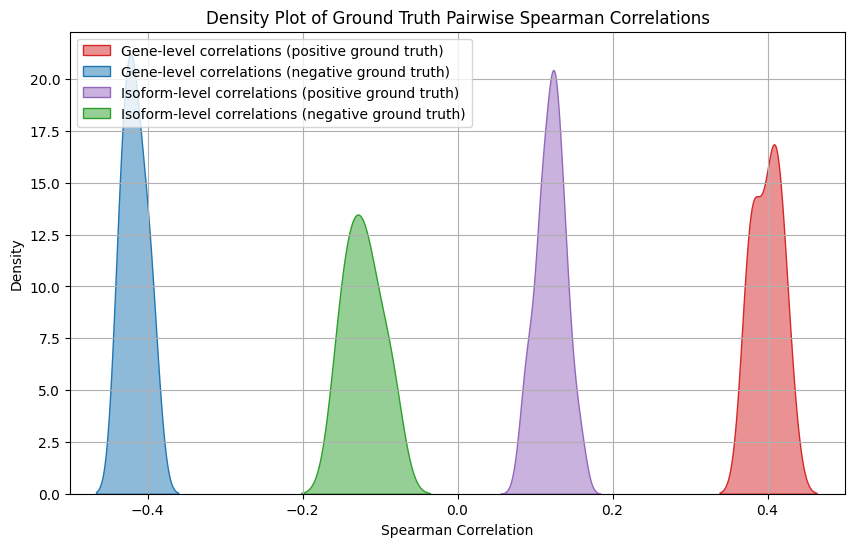

In [28]:


# Merge the density plots.
plt.figure(figsize=(10, 6))

# Gene-level curves:
sns.kdeplot(gene_positive, label="Gene-level correlations (positive ground truth)", color="#d62728", fill=True, alpha=0.5)
sns.kdeplot(gene_negative, label="Gene-level correlations (negative ground truth)", color="#1f77b4", fill=True, alpha=0.5)

# Isoform-level curves:
sns.kdeplot(isoform_positive, label="Isoform-level correlations (positive ground truth)", color="#9467bd", fill=True, alpha=0.5)
sns.kdeplot(isoform_negative, label="Isoform-level correlations (negative ground truth)", color="#2ca02c", fill=True, alpha=0.5)

plt.title("Density Plot of Ground Truth Pairwise Spearman Correlations")
plt.xlabel("Spearman Correlation")
plt.ylabel("Density")
plt.xlim(-0.5, 0.5)
plt.legend(loc="upper left")
plt.grid(True)
#plt.tight_layout()
plt.show()


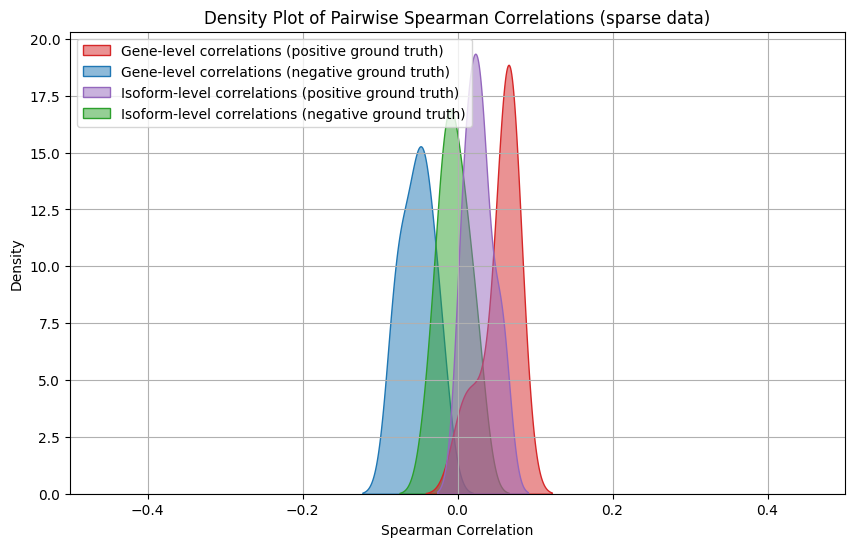

In [29]:
plt.figure(figsize=(10, 6))

# -----------------------------------------------------------------------
# First block: negative ground truth
# -----------------------------------------------------------------------
mean_count = 20
var_count = 100
matrices = [matrix_combined_gene, matrix_combined_isoform]
colors_1 = ['#1f77b4', '#2ca02c']  # gene-negative, isoform-negative
np.random.seed(7)

for matrix, color in zip(matrices, colors_1):
    # normalize to probabilities
    row_sums = matrix.sum(axis=1, keepdims=True)
    prob_matrix = matrix / row_sums

    # NB parameters from mean/variance
    mu, var = mean_count, var_count
    if var <= mu:
        raise ValueError(f"Variance {var} must be > mean {mu}")
    n_float = mu**2 / (var - mu)
    p = n_float / (mu + n_float)

    # sample total counts
    total_counts = np.random.negative_binomial(n_float, p, size=len(prob_matrix))
    total_counts = np.clip(total_counts, 1, None).astype(int)

    # simulate sparse counts and transform
    sparse = np.array([
        np.random.multinomial(tc, prob_row)
        for tc, prob_row in zip(total_counts, prob_matrix)
    ])
    sparse = sparse / total_counts[:, None]
    sparse = np.log1p(sparse * mu)

    # pairwise Spearman
    correlations = []
    if color == '#1f77b4':  # gene-level negative: cols 0,1 vs 5–9
        for i in range(2):
            for j in range(5, 10):
                corr, _ = spearmanr(sparse[:, i], sparse[:, j])
                correlations.append(corr)
        label = "Gene-level correlations (negative ground truth)"
    else:  # '#2ca02c', isoform-level negative: cols 0,1 vs 15–19
        for i in range(2):
            for j in range(15, 20):
                corr, _ = spearmanr(sparse[:, i], sparse[:, j])
                correlations.append(corr)
        label = "Isoform-level correlations (negative ground truth)"

    sns.kdeplot(correlations, label=label, color=color, fill=True, alpha=0.5)


# -----------------------------------------------------------------------
# Second block: positive ground truth
# -----------------------------------------------------------------------
mean_count = 20
var_count = 100
matrices = [matrix_combined_gene, matrix_combined_isoform]
colors_2 = ['#d62728', '#9467bd']  # gene-positive, isoform-positive
np.random.seed(10)

for matrix, color in zip(matrices, colors_2):
    # normalize to probabilities
    row_sums = matrix.sum(axis=1, keepdims=True)
    prob_matrix = matrix / row_sums

    # NB parameters
    mu, var = mean_count, var_count
    if var <= mu:
        raise ValueError(f"Variance {var} must be > mean {mu}")
    n_float = mu**2 / (var - mu)
    p = n_float / (mu + n_float)

    # sample total counts
    total_counts = np.random.negative_binomial(n_float, p, size=len(prob_matrix))
    total_counts = np.clip(total_counts, 1, None).astype(int)

    # simulate sparse counts and transform
    sparse = np.array([
        np.random.multinomial(tc, prob_row)
        for tc, prob_row in zip(total_counts, prob_matrix)
    ])
    sparse = sparse / total_counts[:, None]
    sparse = np.log1p(sparse * mu)

    # pairwise Spearman
    correlations = []
    if color == '#d62728':  # gene-level positive: among cols 5–9
        for i in range(5, 10):
            for j in range(i+1, 10):
                corr, _ = spearmanr(sparse[:, i], sparse[:, j])
                correlations.append(corr)
        label = "Gene-level correlations (positive ground truth)"
    else:  # '#9467bd', isoform-level positive: among cols 15–19
        for i in range(15, 20):
            for j in range(i+1, 20):
                corr, _ = spearmanr(sparse[:, i], sparse[:, j])
                correlations.append(corr)
        label = "Isoform-level correlations (positive ground truth)"

    sns.kdeplot(correlations, label=label, color=color, fill=True, alpha=0.5)


# -----------------------------------------------------------------------
# Reorder legend and finalize
# -----------------------------------------------------------------------
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()

desired_order = [
    "Gene-level correlations (positive ground truth)",
    "Gene-level correlations (negative ground truth)",
    "Isoform-level correlations (positive ground truth)",
    "Isoform-level correlations (negative ground truth)"
]

# pick handles in that order
ordered_handles = [handles[labels.index(lbl)] for lbl in desired_order]
ordered_labels  = desired_order

ax.legend(ordered_handles, ordered_labels, loc="upper left")
plt.title("Density Plot of Pairwise Spearman Correlations (sparse data)")
plt.xlabel("Spearman Correlation")
plt.ylabel("Density")
plt.xlim(-0.5, 0.5)
plt.grid(True)
plt.show()







# comprehensive simulation

Average pairwise correlation (CD4 T markers): 0.10925995908523486
Average pairwise correlation (CD8 T markers): 0.1331265513659844
Average pairwise correlation (CD4 vs CD8 markers): -0.12378641555561769
Matrix mean (all columns): 2.667751605995717
Matrix minimum value (all columns): 0


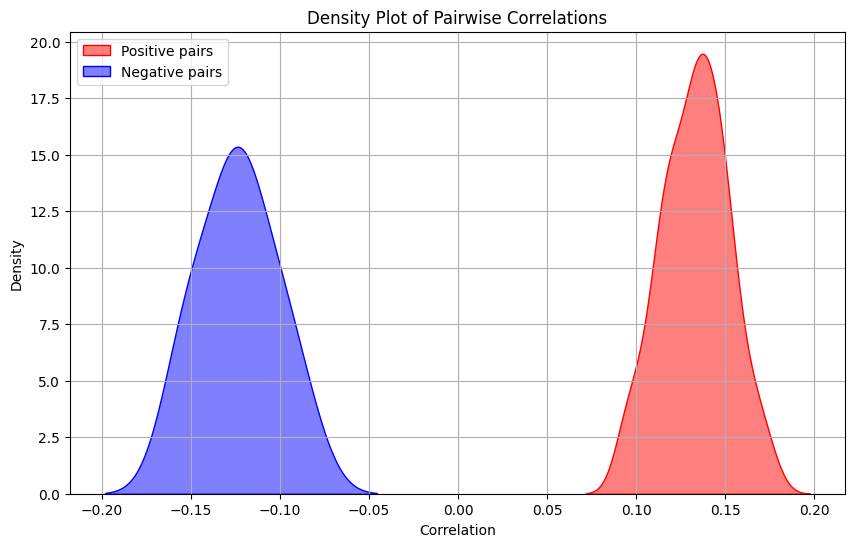

Updated matrix_combined shape: (2335, 90)


In [30]:
# Parameters
np.random.seed(42)
num_rows = len(cell_type_annotations)  # Number of rows corresponds to cells
num_columns = 30  # Number of genes
lambda_base = 5/3  # Mean of base matrix Poisson distribution
lambda_cd4_pos = 5/3  # Positive noise for CD4 markers
lambda_cd4_neg = 1/3  # Negative noise for CD8 markers
lambda_cd8_pos = 5/3  # Positive noise for CD8 markers
lambda_cd8_neg = 1/3  # Negative noise for CD4 markers

# Generate base matrix
base_matrix = np.random.poisson(lam=lambda_base, size=(num_rows, num_columns))

# Add cell-type-specific noise
matrix_combined = np.zeros_like(base_matrix)


for i, cell_type in enumerate(cell_types):
    if cell_type == 'CD4 T':
        matrix_combined[i, :15] = base_matrix[i, :15] + np.random.poisson(lam=lambda_cd4_pos, size=15)
        matrix_combined[i, 15:] = base_matrix[i, 15:] + np.random.poisson(lam=lambda_cd4_neg, size=15)
    elif cell_type == 'CD8 T':
        matrix_combined[i, :15] = base_matrix[i, :15] + np.random.poisson(lam=lambda_cd8_neg, size=15)
        matrix_combined[i, 15:] = base_matrix[i, 15:] + np.random.poisson(lam=lambda_cd8_pos, size=15)

# Validate pairwise correlations
pairwise_correlations_cd4 = []
for i in range(15):  # CD4 T markers (Columns 1-15)
    for j in range(i + 1, 15):  # Pairwise within CD4 T
        corr, _ = pearsonr(matrix_combined[:, i], matrix_combined[:, j])
        pairwise_correlations_cd4.append(corr)

pairwise_correlations_cd8 = []
for i in range(15, 30):  # CD8 T markers (Columns 15-30)
    for j in range(i + 1, 30):  # Pairwise within CD8 T
        corr, _ = pearsonr(matrix_combined[:, i], matrix_combined[:, j])
        pairwise_correlations_cd8.append(corr)

pairwise_correlations_cd4_cd8 = []
for i in range(2):  # CD4 T markers (Columns 1-15)
    for j in range(15, 20):  # CD8 T markers (Columns 15-30)
        corr, _ = pearsonr(matrix_combined[:, i], matrix_combined[:, j])
        pairwise_correlations_cd4_cd8.append(corr)

# Print results
print("Average pairwise correlation (CD4 T markers):", np.mean(pairwise_correlations_cd4))
print("Average pairwise correlation (CD8 T markers):", np.mean(pairwise_correlations_cd8))
print("Average pairwise correlation (CD4 vs CD8 markers):", np.mean(pairwise_correlations_cd4_cd8))
print("Matrix mean (all columns):", matrix_combined.mean())
print("Matrix minimum value (all columns):", matrix_combined.min())

# Plot density plots for correlations
plt.figure(figsize=(10, 6))
#sns.kdeplot(pairwise_correlations_cd4, label="Positive pairs", color="red", fill=True, alpha=0.5)
sns.kdeplot(pairwise_correlations_cd8, label="Positive pairs", color="red", fill=True, alpha=0.5)
sns.kdeplot(pairwise_correlations_cd4_cd8, label="Negative pairs", color="blue", fill=True, alpha=0.5)
plt.title("Density Plot of Pairwise Correlations")
plt.xlabel("Correlation")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

# Generate 20 Poisson-distributed noise columns
np.random.seed(5)
num_noise_columns = 60
lambda_noise = 5  # Poisson distribution mean for noise

# Generate Poisson noise columns
noise_columns = np.random.poisson(lam=lambda_noise, size=(num_rows, num_noise_columns))

# Adjust noise columns to have the same mean as the existing matrix
current_noise_mean = noise_columns.mean()
matrix_mean = matrix_combined.mean()
noise_columns = noise_columns + (matrix_mean - current_noise_mean)  # Shift mean to match matrix_combined

# Ensure all values remain positive
noise_columns = np.clip(noise_columns, a_min=1, a_max=None)

# Concatenate noise columns with the existing matrix
matrix_combined_isoform = np.hstack([matrix_combined, noise_columns])

pairwise_correlations_cd4_noise = []
for i in range(2):  # CD4 T markers (Columns 1-15)
    for j in range(40, 45):  # noise (Columns 30-45)
        corr, _ = pearsonr(matrix_combined_isoform[:, i], matrix_combined_isoform[:, j])
        pairwise_correlations_cd4_noise.append(corr)

pairwise_correlations_cd8_noise = []
for i in range(15,20):  # CD8 T markers (Columns 1-15)
    for j in range(40, 45):  # noise (Columns 30-45)
        corr, _ = pearsonr(matrix_combined_isoform[:, i], matrix_combined_isoform[:, j])
        pairwise_correlations_cd8_noise.append(corr)

pairwise_correlations_noise_noise = []
for i in range(40,45):  # CD8 T markers (Columns 1-15)
    for j in range(i+1, 45):  # noise (Columns 30-45)
        corr, _ = pearsonr(matrix_combined_isoform[:, i], matrix_combined_isoform[:, j])
        pairwise_correlations_noise_noise.append(corr)

# Verify the shape of the updated matrix
print("Updated matrix_combined shape:", matrix_combined_isoform.shape)

positive_truth = np.mean(pairwise_correlations_cd8)
negative_truth = np.mean(pairwise_correlations_cd4_cd8)
uncorrelated_1_truth = np.mean(pairwise_correlations_cd4_noise)
uncorrelated_2_truth = np.mean(pairwise_correlations_cd8_noise)
uncorrelated_3_truth = np.mean(pairwise_correlations_noise_noise)

Random walk with restart converged in 27 iterations.
Random walk with restart converged in 27 iterations.
Random walk with restart converged in 27 iterations.
Random walk with restart converged in 27 iterations.


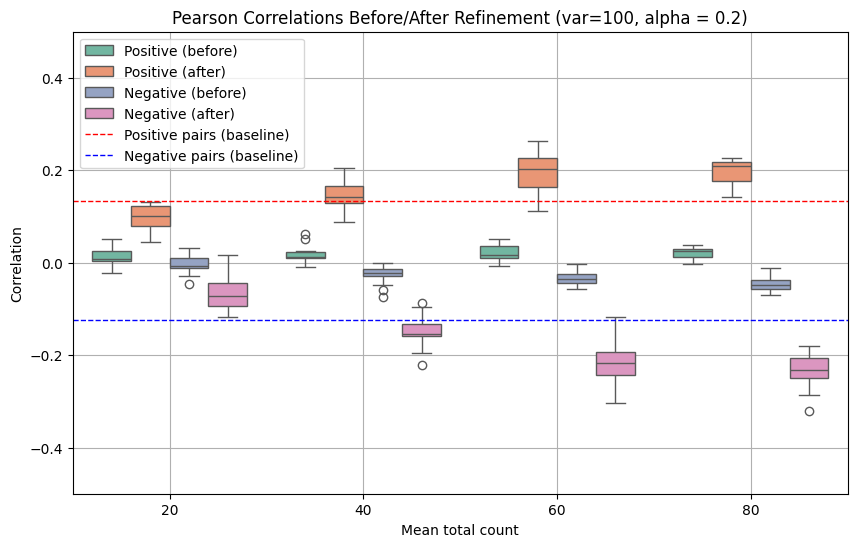

Random walk with restart converged in 27 iterations.
Random walk with restart converged in 27 iterations.
Random walk with restart converged in 27 iterations.
Random walk with restart converged in 27 iterations.


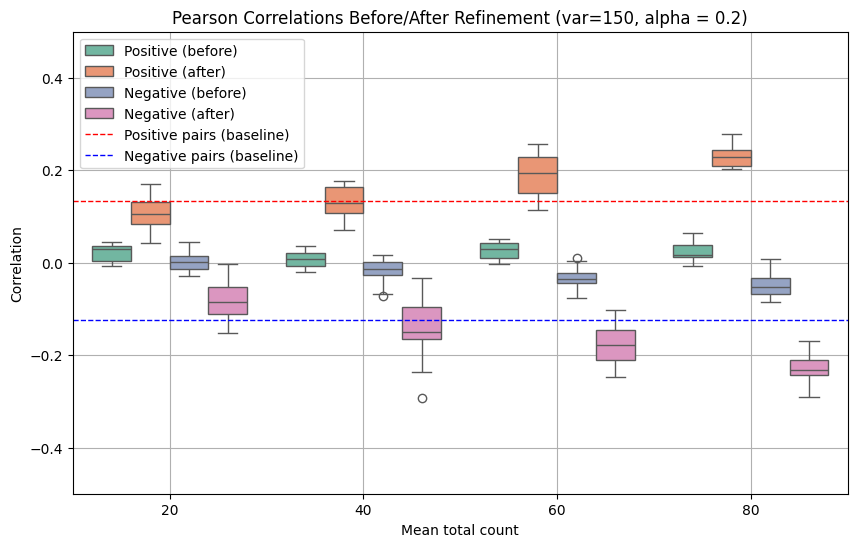

Random walk with restart converged in 27 iterations.
Random walk with restart converged in 27 iterations.
Random walk with restart converged in 27 iterations.
Random walk with restart converged in 27 iterations.


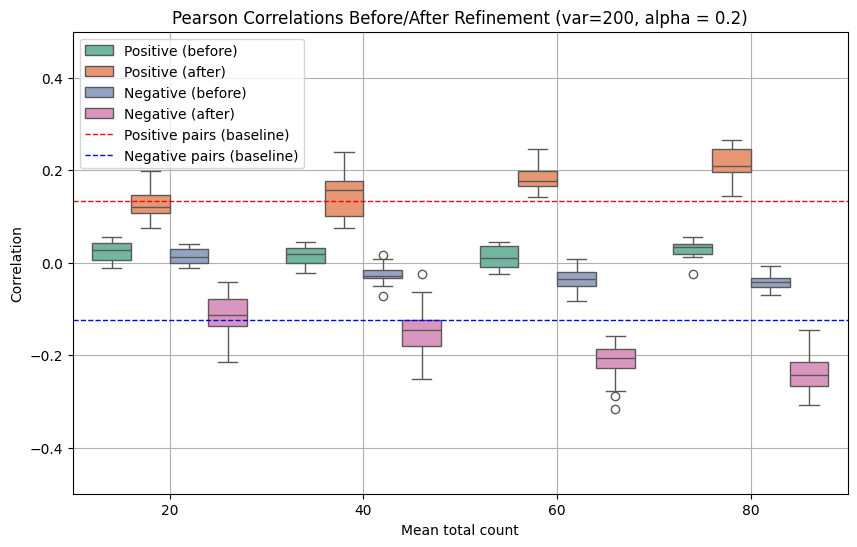

In [31]:



np.random.seed(3)


def simulate_negative_binomial_data(matrix, mu, var):
    """
    - Normalizes rows of 'matrix' to get probabilities per row.
    - Simulates total counts from NB(mu, var).
    - Samples from multinomial for each row.
    - Normalizes, multiplies by 100, then log1p.
    Returns a NumPy array of shape (cells, genes).
    """
    # Normalize to row sums
    row_sums = matrix.sum(axis=1, keepdims=True)
    prob_matrix = matrix / np.maximum(row_sums, 1e-12)

    if var <= mu:
        raise ValueError(f"Variance {var} must be > mean {mu} for a valid Negative Binomial.")

    # Calculate NB parameters
    n_float = mu**2 / (var - mu)  # shape
    if n_float <= 0:
        raise ValueError("Computed n is not positive. Check your mean/variance inputs.")
    p = n_float / (mu + n_float)  # success probability

    # Sample total counts from NB
    total_counts = np.random.negative_binomial(n_float, p, size=len(prob_matrix))
    total_counts = np.clip(total_counts, a_min=1, a_max=None).astype(int)

    # Multinomial to distribute across each row
    counts_matrix = np.array([
        np.random.multinomial(tc, row_p)
        for tc, row_p in zip(total_counts, prob_matrix)
    ])

    # Normalize by total_counts,  log1p
    counts_matrix = counts_matrix / total_counts[:, np.newaxis]
    counts_matrix = counts_matrix * 100
    return np.log1p(counts_matrix)


def compute_cd8_and_cd4_cd8_correlations(expression_matrix,
                                         cd8_range=(15, 20),
                                         cd4_range=(0, 5)):
    """
    Returns two lists:
      - cd8_corrs: pairwise correlations among columns in cd8_range
      - cd4_cd8_corrs: pairwise correlations between cd4_range and cd8_range
    """
    # CD8 vs CD8
    start_cd8, end_cd8 = cd8_range
    cd8_corrs = []
    for i in range(start_cd8, end_cd8):
        for j in range(i+1, end_cd8):
            corr, _ = pearsonr(expression_matrix[:, i], expression_matrix[:, j])
            cd8_corrs.append(corr)

    # CD4 vs CD8
    start_cd4, end_cd4 = cd4_range
    cd4_cd8_corrs = []
    for i in range(start_cd4, end_cd4):
        for j in range(start_cd8, end_cd8):
            corr, _ = pearsonr(expression_matrix[:, i], expression_matrix[:, j])
            cd4_cd8_corrs.append(corr)

    return cd8_corrs, cd4_cd8_corrs

# ------------------------------------------------------
# Main loop: vary mu while fixing var = 100.
#    compute correlations BEFORE vs. AFTER RWR
#    for both CD8–CD8 and CD4–CD8.
# ------------------------------------------------------
mu_values = [20, 40, 60, 80]  # the range of mu
var_values = [100, 150, 200]


for var in var_values:

    results = []

    for mu in mu_values:
        # (a) Simulate data
        sim_matrix = simulate_negative_binomial_data(
            matrix_combined_isoform, mu=mu, var=var
        )

        # (b) Compute correlations BEFORE
        cd8_corr_before, cd4_cd8_corr_before = compute_cd8_and_cd4_cd8_correlations(sim_matrix,
                                                                                  cd8_range=(15, 20),
                                                                                  cd4_range=(0, 5))

        # Create AnnData object
        gene_names = [f"Gene_{i+1}" for i in range(sim_matrix.shape[1])]
        adata = anndata.AnnData(X=sim_matrix)

        # (c) Run RWR algorithm

        new_matrix, P_final = rwr_impute(sim_matrix_df_norm, adata, alpha=0.2, max_iter=100, tol=1e-4, device=device)
        adata_new = adata.copy()
        adata_new.X = new_matrix

        # Perform the same analysis as before with adata_transcript_new
        sc.pp.normalize_total(adata_new, target_sum=1e2)
        sc.pp.log1p(adata_new)
        new_matrx = adata_new.X

        # (d) Compute correlations AFTER
        cd8_corr_after, cd4_cd8_corr_after = compute_cd8_and_cd4_cd8_correlations(new_matrix,
                                                                                  cd8_range=(15, 20),
                                                                                  cd4_range=(0, 5))

        # Collect results in our list
        # store each correlation with a label for 'group'.
        for val in cd8_corr_before:
            results.append((mu, "Positive (before)", val))
        for val in cd8_corr_after:
            results.append((mu, "Positive (after)", val))
        for val in cd4_cd8_corr_before:
            results.append((mu, "Negative (before)", val))
        for val in cd4_cd8_corr_after:
            results.append((mu, "Negative (after)", val))

    # ------------------------------------------------------
    # 5. Convert to a Pandas DataFrame
    # ------------------------------------------------------
    df = pd.DataFrame(results, columns=["mu", "group", "correlation"])

    # ------------------------------------------------------
    # 6. Plot:
    #    x-axis: mu
    #    y-axis: correlation
    #    hue: group
    #    => 4 boxplots per mu (CD8_before, CD8_after,
    #                          CD4-CD8_before, CD4-CD8_after)
    # ------------------------------------------------------
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x="mu", y="correlation", hue="group", palette="Set2")
    #sns.stripplot(data=df, x="mu", y="correlation", hue="group", dodge=True, color="black", alpha=0.3)
    plt.axhline(positive_truth, color="red", linestyle="--", linewidth=1, label="Positive pairs (baseline)")
    plt.axhline(negative_truth, color="blue", linestyle="--", linewidth=1, label="Negative pairs (baseline)")

    plt.title(f"Pearson Correlations Before/After Refinement (var={var}, alpha = 0.2)")
    plt.ylim(-0.5, 0.5)
    plt.xlabel("Mean total count")
    plt.ylabel("Correlation")
    plt.legend()
    plt.grid(True)
    plt.show()


Random walk with restart converged in 27 iterations.
Random walk with restart converged in 27 iterations.
Random walk with restart converged in 27 iterations.
Random walk with restart converged in 27 iterations.


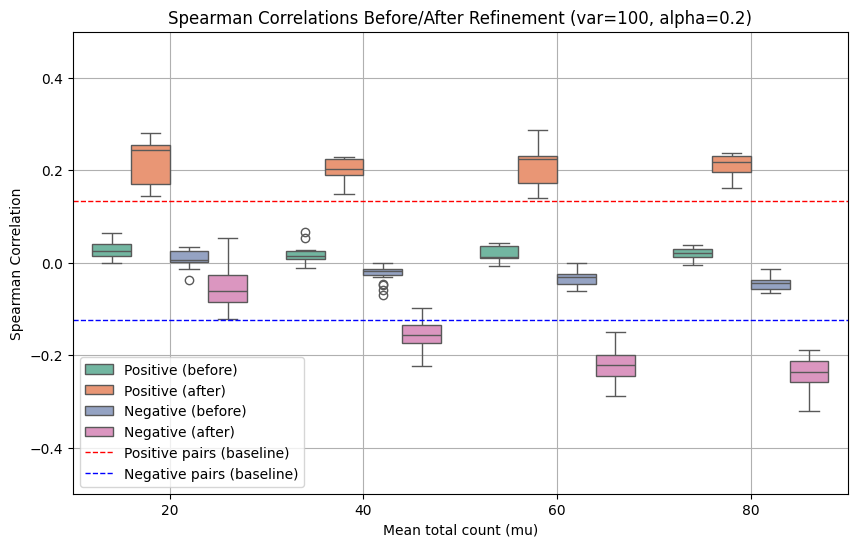

Random walk with restart converged in 27 iterations.
Random walk with restart converged in 27 iterations.
Random walk with restart converged in 27 iterations.
Random walk with restart converged in 27 iterations.


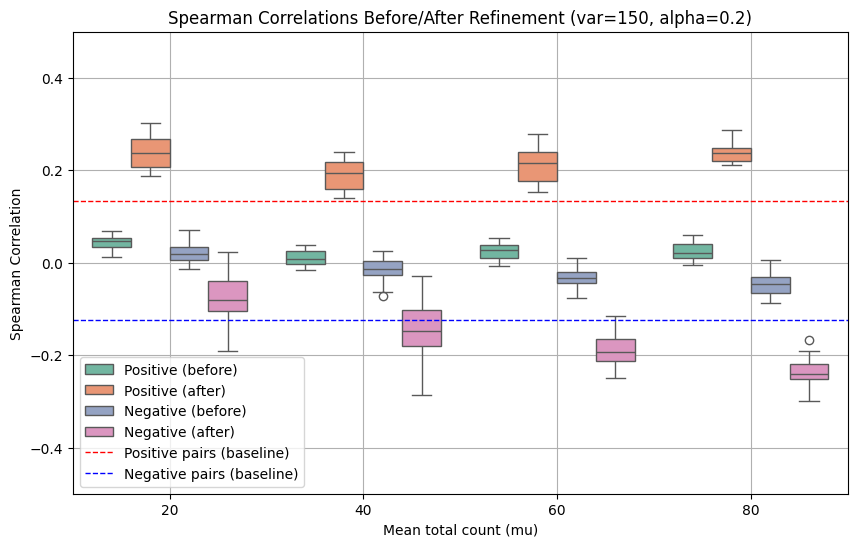

Random walk with restart converged in 27 iterations.
Random walk with restart converged in 27 iterations.
Random walk with restart converged in 27 iterations.
Random walk with restart converged in 27 iterations.


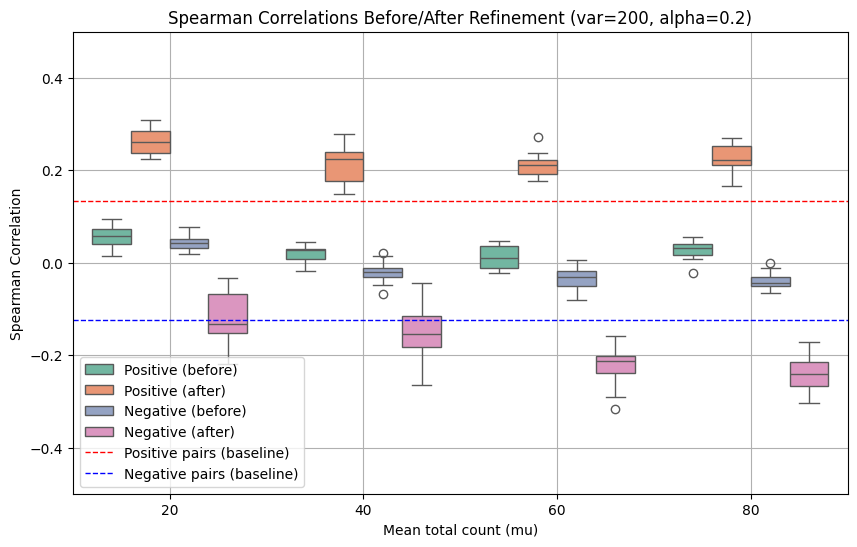

In [32]:
np.random.seed(3)


def simulate_negative_binomial_data(matrix, mu, var):
    """
    - Normalizes rows of 'matrix' to get probabilities per row.
    - Simulates total counts from NB(mu, var).
    - Samples from multinomial for each row.
    - Normalizes, multiplies by 100, then log1p.
    Returns a NumPy array of shape (cells, genes).
    """
    # Normalize to row sums
    row_sums = matrix.sum(axis=1, keepdims=True)
    prob_matrix = matrix / np.maximum(row_sums, 1e-12)

    if var <= mu:
        raise ValueError(f"Variance {var} must be > mean {mu} for a valid Negative Binomial.")

    # Calculate NB parameters
    n_float = mu**2 / (var - mu)  # shape parameter
    if n_float <= 0:
        raise ValueError("Computed n is not positive. Check your mean/variance inputs.")
    p = n_float / (mu + n_float)  # success probability

    # Sample total counts from NB
    total_counts = np.random.negative_binomial(n_float, p, size=len(prob_matrix))
    total_counts = np.clip(total_counts, a_min=1, a_max=None).astype(int)

    # Multinomial to distribute counts across each row
    counts_matrix = np.array([
        np.random.multinomial(tc, row_p)
        for tc, row_p in zip(total_counts, prob_matrix)
    ])

    # Normalize by total counts, scale by 100, then log1p
    counts_matrix = counts_matrix / total_counts[:, np.newaxis]
    counts_matrix = counts_matrix * 100
    return np.log1p(counts_matrix)


def compute_cd8_and_cd4_cd8_correlations(expression_matrix,
                                         cd8_range=(15, 20),
                                         cd4_range=(0, 5)):
    """
    Returns two lists:
      - cd8_corrs: pairwise correlations among columns in cd8_range
      - cd4_cd8_corrs: pairwise correlations between cd4_range and cd8_range
    """
    # CD8 vs CD8 correlations
    start_cd8, end_cd8 = cd8_range
    cd8_corrs = []
    for i in range(start_cd8, end_cd8):
        for j in range(i+1, end_cd8):
            corr, _ = spearmanr(expression_matrix[:, i], expression_matrix[:, j])
            cd8_corrs.append(corr)

    # CD4 vs CD8 correlations
    start_cd4, end_cd4 = cd4_range
    cd4_cd8_corrs = []
    for i in range(start_cd4, end_cd4):
        for j in range(start_cd8, end_cd8):
            corr, _ = spearmanr(expression_matrix[:, i], expression_matrix[:, j])
            cd4_cd8_corrs.append(corr)

    return cd8_corrs, cd4_cd8_corrs

# ------------------------------------------------------
#  Main loop: vary mu while fixing var = 100, 150, and 200.
#    We compute correlations BEFORE vs. AFTER RWR
#    for both CD8–CD8 and CD4–CD8.
# ------------------------------------------------------
mu_values = [20, 40, 60, 80]  # Different mu values
var_values = [100, 150, 200]



for var in var_values:

    results = []  # To accumulate (mu, group, correlation)

    for mu in mu_values:
        # (a) Simulate data
        sim_matrix = simulate_negative_binomial_data(
            matrix_combined_isoform, mu=mu, var=var
        )

        # (b) Compute correlations BEFORE RWR refinement
        cd8_corr_before, cd4_cd8_corr_before = compute_cd8_and_cd4_cd8_correlations(
            sim_matrix, cd8_range=(15, 20), cd4_range=(0, 5)
        )

        # Create an AnnData object for use in the RWR algorithm
        gene_names = [f"Gene_{i+1}" for i in range(sim_matrix.shape[1])]
        adata = anndata.AnnData(X=sim_matrix)
        adata.var['gene_names'] = gene_names

        # (c) Run RWR algorithm
        new_matrix, P_final = rwr_impute(sim_matrix_df_norm, adata, alpha=0.2, max_iter=100, tol=1e-4, device=device)
        adata_new = adata.copy()
        adata_new.X = new_matrix

        # Perform the same normalization on the refined data
        sc.pp.normalize_total(adata_new, target_sum=1e2)
        sc.pp.log1p(adata_new)
        new_matrix = adata_new.X  # Updated refined matrix

        # (d) Compute correlations AFTER RWR refinement
        cd8_corr_after, cd4_cd8_corr_after = compute_cd8_and_cd4_cd8_correlations(
            new_matrix, cd8_range=(15, 20), cd4_range=(0, 5)
        )

        # Collect results with labels for 'before' and 'after'
        for val in cd8_corr_before:
            results.append((mu, "Positive (before)", val))
        for val in cd8_corr_after:
            results.append((mu, "Positive (after)", val))
        for val in cd4_cd8_corr_before:
            results.append((mu, "Negative (before)", val))
        for val in cd4_cd8_corr_after:
            results.append((mu, "Negative (after)", val))

    # ------------------------------------------------------
    # 5. Convert results to a Pandas DataFrame.
    # ------------------------------------------------------
    df = pd.DataFrame(results, columns=["mu", "group", "correlation"])

    # ------------------------------------------------------
    # 6. Plot the Spearman correlations:
    #    x-axis: mu
    #    y-axis: correlation
    #    hue: group
    # ------------------------------------------------------
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x="mu", y="correlation", hue="group", palette="Set2")

    plt.axhline(positive_truth, color="red", linestyle="--", linewidth=1, label="Positive pairs (baseline)")
    plt.axhline(negative_truth, color="blue", linestyle="--", linewidth=1, label="Negative pairs (baseline)")

    plt.title(f"Spearman Correlations Before/After Refinement (var={var}, alpha=0.2)")
    plt.ylim(-0.5, 0.5)
    plt.xlabel("Mean total count (mu)")
    plt.ylabel("Spearman Correlation")
    plt.legend()
    plt.grid(True)
    plt.show()

Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.


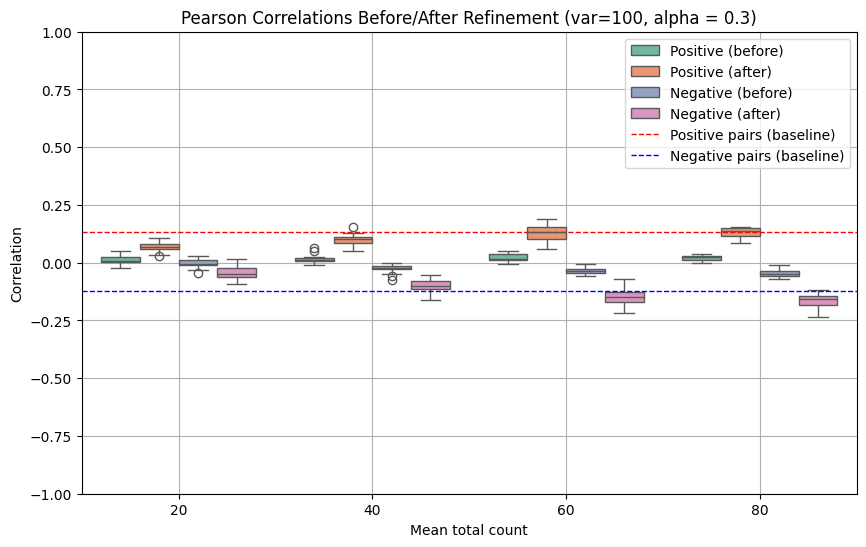

Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.


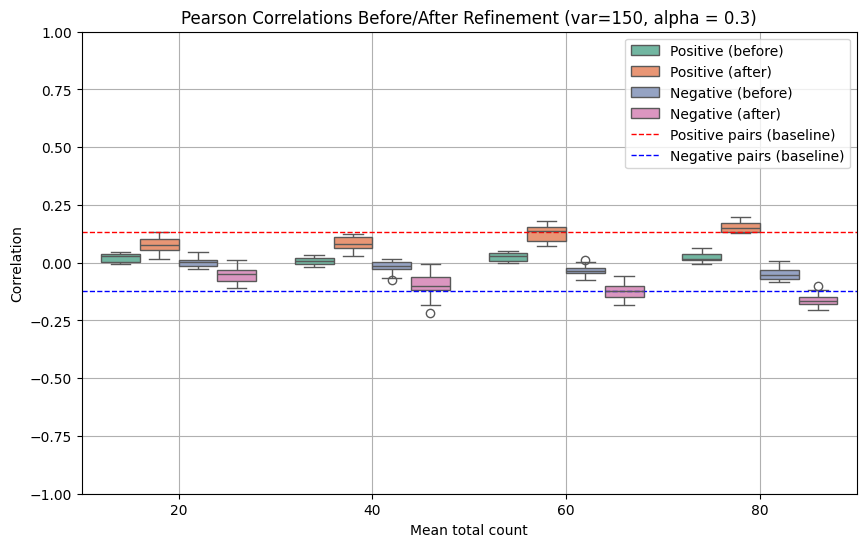

Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.


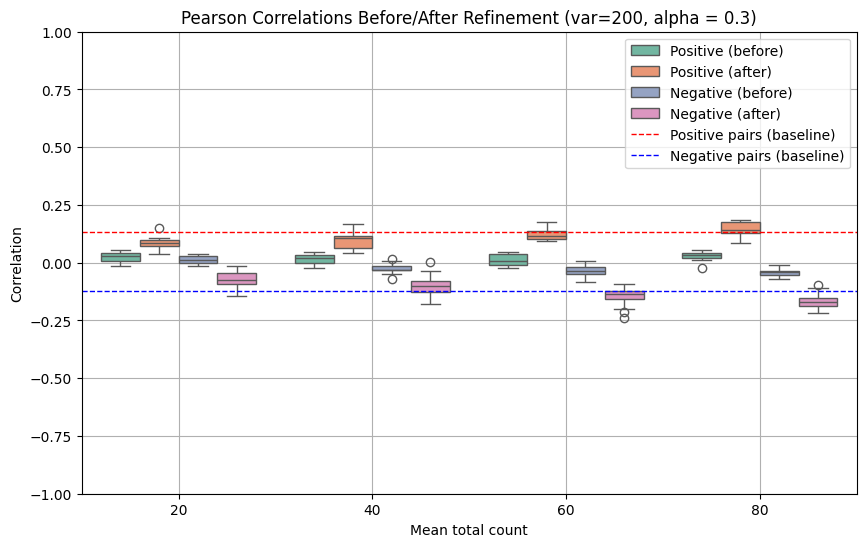

In [33]:



np.random.seed(3)


def simulate_negative_binomial_data(matrix, mu, var):
    """
    - Normalizes rows of 'matrix' to get probabilities per row.
    - Simulates total counts from NB(mu, var).
    - Samples from multinomial for each row.
    - Normalizes, multiplies by 100, then log1p.
    Returns a NumPy array of shape (cells, genes).
    """
    # Normalize to row sums
    row_sums = matrix.sum(axis=1, keepdims=True)
    prob_matrix = matrix / np.maximum(row_sums, 1e-12)

    if var <= mu:
        raise ValueError(f"Variance {var} must be > mean {mu} for a valid Negative Binomial.")

    # Calculate NB parameters
    n_float = mu**2 / (var - mu)  # shape
    if n_float <= 0:
        raise ValueError("Computed n is not positive. Check your mean/variance inputs.")
    p = n_float / (mu + n_float)  # success probability

    # Sample total counts from NB
    total_counts = np.random.negative_binomial(n_float, p, size=len(prob_matrix))
    total_counts = np.clip(total_counts, a_min=1, a_max=None).astype(int)

    # Multinomial to distribute across each row
    counts_matrix = np.array([
        np.random.multinomial(tc, row_p)
        for tc, row_p in zip(total_counts, prob_matrix)
    ])

    # Normalize by total_counts, log1p
    counts_matrix = counts_matrix / total_counts[:, np.newaxis]
    counts_matrix = counts_matrix * 100
    return np.log1p(counts_matrix)


def compute_cd8_and_cd4_cd8_correlations(expression_matrix,
                                         cd8_range=(15, 20),
                                         cd4_range=(0, 5)):
    """
    Returns two lists:
      - cd8_corrs: pairwise correlations among columns in cd8_range
      - cd4_cd8_corrs: pairwise correlations between cd4_range and cd8_range
    """
    # CD8 vs CD8
    start_cd8, end_cd8 = cd8_range
    cd8_corrs = []
    for i in range(start_cd8, end_cd8):
        for j in range(i+1, end_cd8):
            corr, _ = pearsonr(expression_matrix[:, i], expression_matrix[:, j])
            cd8_corrs.append(corr)

    # CD4 vs CD8
    start_cd4, end_cd4 = cd4_range
    cd4_cd8_corrs = []
    for i in range(start_cd4, end_cd4):
        for j in range(start_cd8, end_cd8):
            corr, _ = pearsonr(expression_matrix[:, i], expression_matrix[:, j])
            cd4_cd8_corrs.append(corr)

    return cd8_corrs, cd4_cd8_corrs

# ------------------------------------------------------
# Main loop: vary mu while fixing var = 100.
#    compute correlations BEFORE vs. AFTER RWR
#    for both CD8–CD8 and CD4–CD8.
# ------------------------------------------------------
mu_values = [20, 40, 60, 80]  # the range of mu
var_values = [100, 150, 200]

for var in var_values:

    results = []  # accumulate (mu, group, correlation)

    for mu in mu_values:
        # (a) Simulate data
        sim_matrix = simulate_negative_binomial_data(
            matrix_combined_isoform, mu=mu, var=var
        )

        # (b) Compute correlations BEFORE
        cd8_corr_before, cd4_cd8_corr_before = compute_cd8_and_cd4_cd8_correlations(sim_matrix,
                                                                                  cd8_range=(15, 20),
                                                                                  cd4_range=(0, 5))

        # Create AnnData object
        gene_names = [f"Gene_{i+1}" for i in range(sim_matrix.shape[1])]
        adata = anndata.AnnData(X=sim_matrix)

        # (c) Run RWR algorithm
        new_matrix, P_final = rwr_impute(sim_matrix_df_norm, adata, alpha=0.3, max_iter=100, tol=1e-4, device=device)
        adata_new = adata.copy()
        adata_new.X = new_matrix

        # Perform the same analysis as before with adata_transcript_new
        sc.pp.normalize_total(adata_new, target_sum=1e2)
        sc.pp.log1p(adata_new)
        new_matrx = adata_new.X

        # (d) Compute correlations AFTER
        cd8_corr_after, cd4_cd8_corr_after = compute_cd8_and_cd4_cd8_correlations(new_matrix,
                                                                                  cd8_range=(15, 20),
                                                                                  cd4_range=(0, 5))

        # Collect results in list
        # store each correlation with a label for 'group'.
        for val in cd8_corr_before:
            results.append((mu, "Positive (before)", val))
        for val in cd8_corr_after:
            results.append((mu, "Positive (after)", val))
        for val in cd4_cd8_corr_before:
            results.append((mu, "Negative (before)", val))
        for val in cd4_cd8_corr_after:
            results.append((mu, "Negative (after)", val))


    df = pd.DataFrame(results, columns=["mu", "group", "correlation"])


    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x="mu", y="correlation", hue="group", palette="Set2")
    #sns.stripplot(data=df, x="mu", y="correlation", hue="group", dodge=True, color="black", alpha=0.3)
    plt.axhline(positive_truth, color="red", linestyle="--", linewidth=1, label="Positive pairs (baseline)")
    plt.axhline(negative_truth, color="blue", linestyle="--", linewidth=1, label="Negative pairs (baseline)")

    plt.title(f"Pearson Correlations Before/After Refinement (var={var}, alpha = 0.3)")
    plt.ylim(-1, 1)
    plt.xlabel("Mean total count")
    plt.ylabel("Correlation")
    plt.legend()
    plt.grid(True)
    plt.show()


Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.


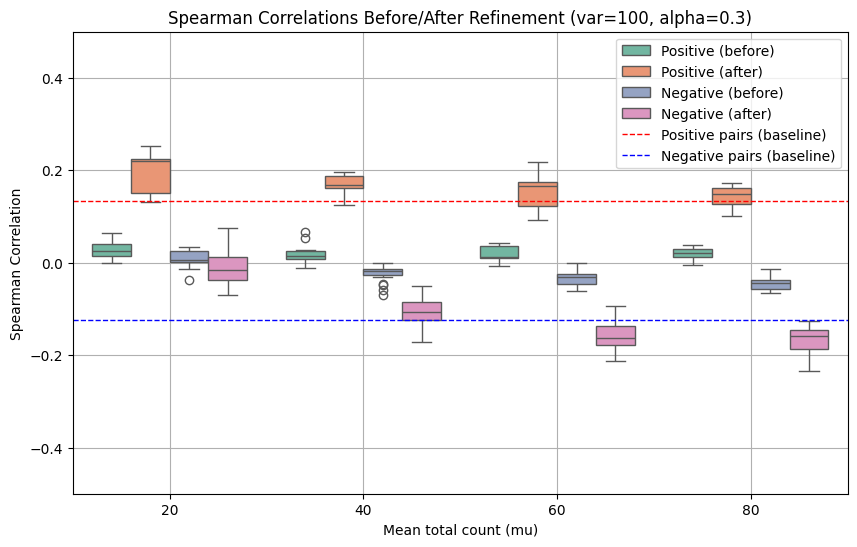

Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.


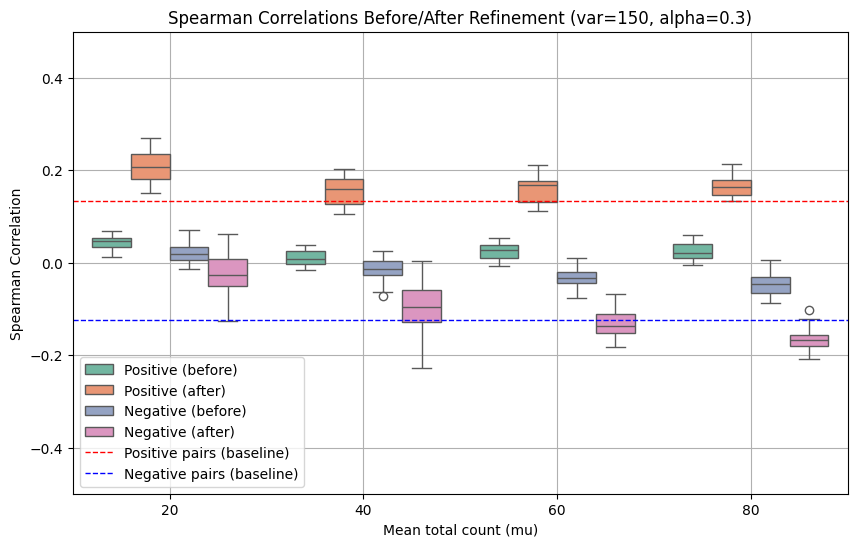

Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.


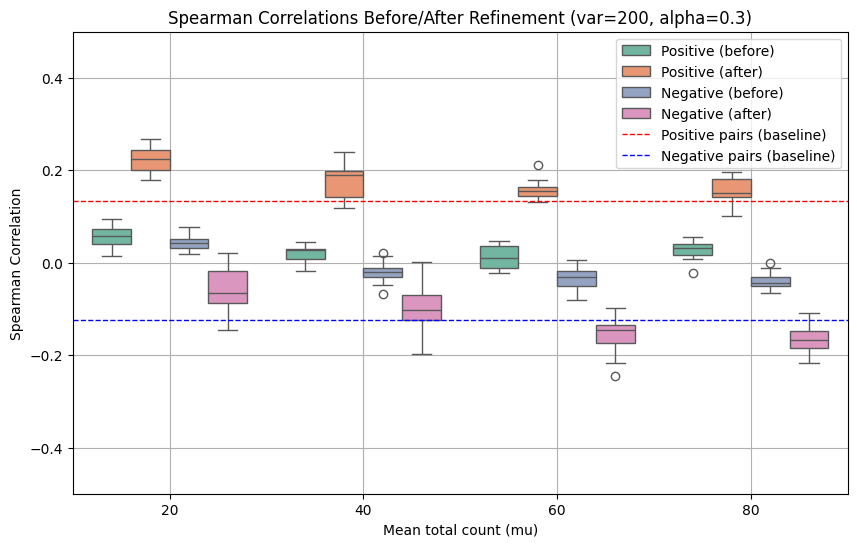

In [34]:
np.random.seed(3)


def simulate_negative_binomial_data(matrix, mu, var):
    """
    - Normalizes rows of 'matrix' to get probabilities per row.
    - Simulates total counts from NB(mu, var).
    - Samples from multinomial for each row.
    - Normalizes, multiplies by 100, then log1p.
    Returns a NumPy array of shape (cells, genes).
    """
    # Normalize to row sums
    row_sums = matrix.sum(axis=1, keepdims=True)
    prob_matrix = matrix / np.maximum(row_sums, 1e-12)

    if var <= mu:
        raise ValueError(f"Variance {var} must be > mean {mu} for a valid Negative Binomial.")

    # Calculate NB parameters
    n_float = mu**2 / (var - mu)  # shape parameter
    if n_float <= 0:
        raise ValueError("Computed n is not positive. Check your mean/variance inputs.")
    p = n_float / (mu + n_float)  # success probability

    # Sample total counts from NB
    total_counts = np.random.negative_binomial(n_float, p, size=len(prob_matrix))
    total_counts = np.clip(total_counts, a_min=1, a_max=None).astype(int)

    # Multinomial to distribute counts across each row
    counts_matrix = np.array([
        np.random.multinomial(tc, row_p)
        for tc, row_p in zip(total_counts, prob_matrix)
    ])

    # Normalize by total counts, then log1p
    counts_matrix = counts_matrix / total_counts[:, np.newaxis]
    counts_matrix = counts_matrix * 100
    return np.log1p(counts_matrix)


def compute_cd8_and_cd4_cd8_correlations(expression_matrix,
                                         cd8_range=(15, 20),
                                         cd4_range=(0, 5)):
    """
    Returns two lists:
      - cd8_corrs: pairwise correlations among columns in cd8_range
      - cd4_cd8_corrs: pairwise correlations between cd4_range and cd8_range
    """
    # CD8 vs CD8 correlations
    start_cd8, end_cd8 = cd8_range
    cd8_corrs = []
    for i in range(start_cd8, end_cd8):
        for j in range(i+1, end_cd8):
            corr, _ = spearmanr(expression_matrix[:, i], expression_matrix[:, j])
            cd8_corrs.append(corr)

    # CD4 vs CD8 correlations
    start_cd4, end_cd4 = cd4_range
    cd4_cd8_corrs = []
    for i in range(start_cd4, end_cd4):
        for j in range(start_cd8, end_cd8):
            corr, _ = spearmanr(expression_matrix[:, i], expression_matrix[:, j])
            cd4_cd8_corrs.append(corr)

    return cd8_corrs, cd4_cd8_corrs

# ------------------------------------------------------
# Main loop: vary mu while fixing var = 100, 150, and 200.
#    compute correlations BEFORE vs. AFTER RWR
#    for both CD8–CD8 and CD4–CD8.
# ------------------------------------------------------
mu_values = [20, 40, 60, 80]  # Different mu values
var_values = [100, 150, 200]


for var in var_values:

    results = []  # To accumulate (mu, group, correlation)

    for mu in mu_values:
        # (a) Simulate data
        sim_matrix = simulate_negative_binomial_data(
            matrix_combined_isoform, mu=mu, var=var
        )

        # (b) Compute correlations BEFORE RWR refinement
        cd8_corr_before, cd4_cd8_corr_before = compute_cd8_and_cd4_cd8_correlations(
            sim_matrix, cd8_range=(15, 20), cd4_range=(0, 5)
        )

        # Create an AnnData object for use in the RWR algorithm
        gene_names = [f"Gene_{i+1}" for i in range(sim_matrix.shape[1])]
        adata = anndata.AnnData(X=sim_matrix)
        adata.var['gene_names'] = gene_names

        # (c) Run your RWR algorithm
        new_matrix, P_final = rwr_impute(sim_matrix_df_norm, adata, alpha=0.3, max_iter=100, tol=1e-4, device=device)
        adata_new = adata.copy()
        adata_new.X = new_matrix

        # Perform the same normalization on the refined data
        sc.pp.normalize_total(adata_new, target_sum=1e2)
        sc.pp.log1p(adata_new)
        new_matrix = adata_new.X  # Updated refined matrix

        # (d) Compute correlations AFTER RWR refinement
        cd8_corr_after, cd4_cd8_corr_after = compute_cd8_and_cd4_cd8_correlations(
            new_matrix, cd8_range=(15, 20), cd4_range=(0, 5)
        )

        # Collect results with labels for 'before' and 'after'
        for val in cd8_corr_before:
            results.append((mu, "Positive (before)", val))
        for val in cd8_corr_after:
            results.append((mu, "Positive (after)", val))
        for val in cd4_cd8_corr_before:
            results.append((mu, "Negative (before)", val))
        for val in cd4_cd8_corr_after:
            results.append((mu, "Negative (after)", val))


    df = pd.DataFrame(results, columns=["mu", "group", "correlation"])


    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x="mu", y="correlation", hue="group", palette="Set2")


    plt.axhline(positive_truth, color="red", linestyle="--", linewidth=1, label="Positive pairs (baseline)")
    plt.axhline(negative_truth, color="blue", linestyle="--", linewidth=1, label="Negative pairs (baseline)")

    plt.title(f"Spearman Correlations Before/After Refinement (var={var}, alpha=0.3)")
    plt.ylim(-0.5, 0.5)
    plt.xlabel("Mean total count (mu)")
    plt.ylabel("Spearman Correlation")
    plt.legend()
    plt.grid(True)
    plt.show()

Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.


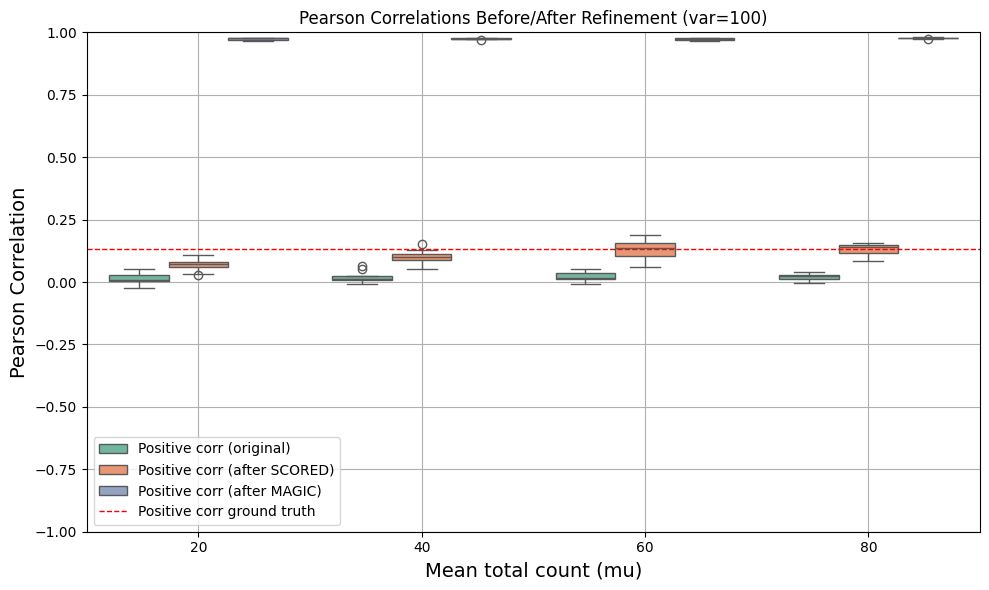

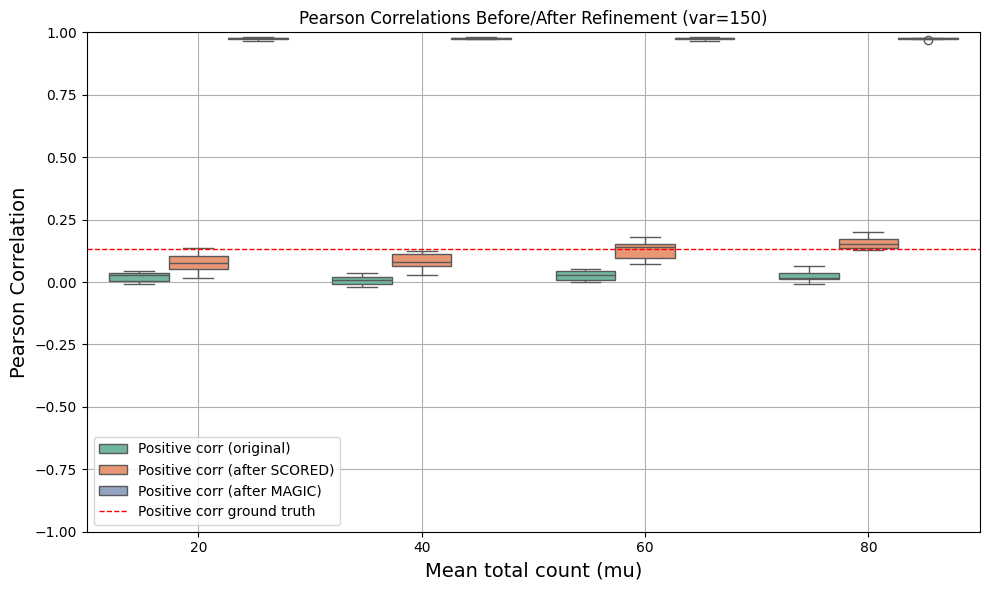

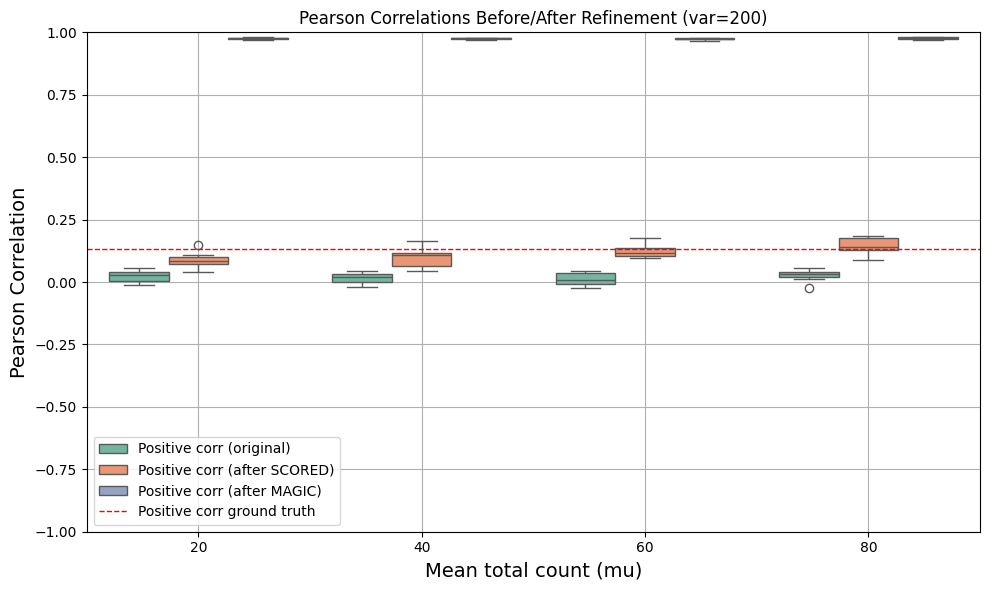

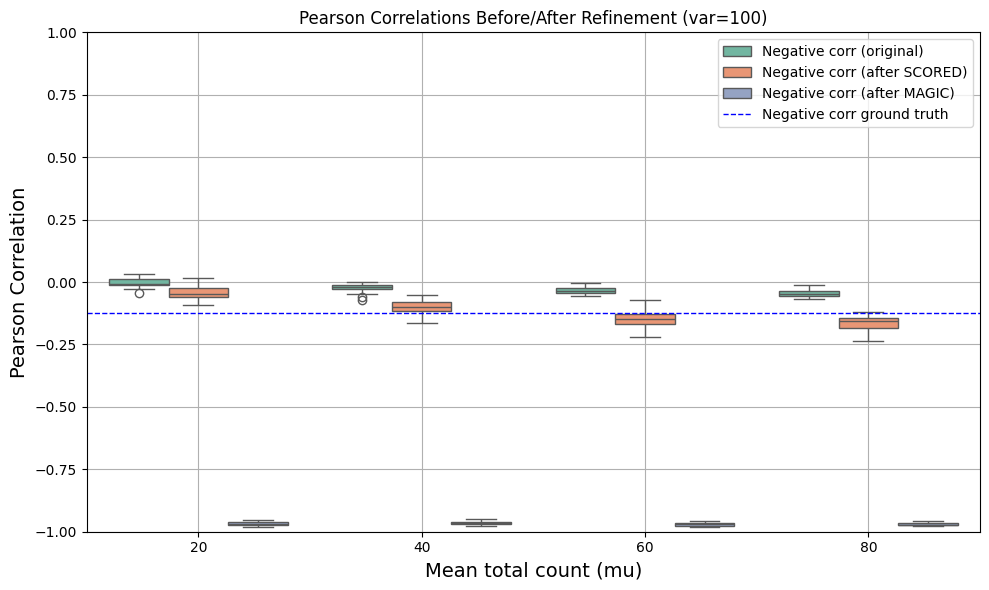

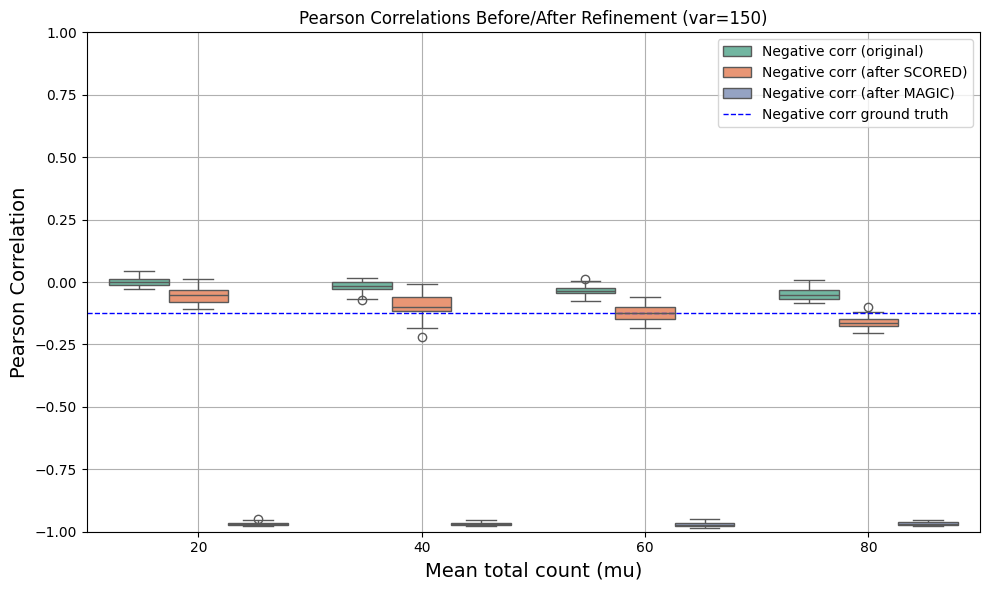

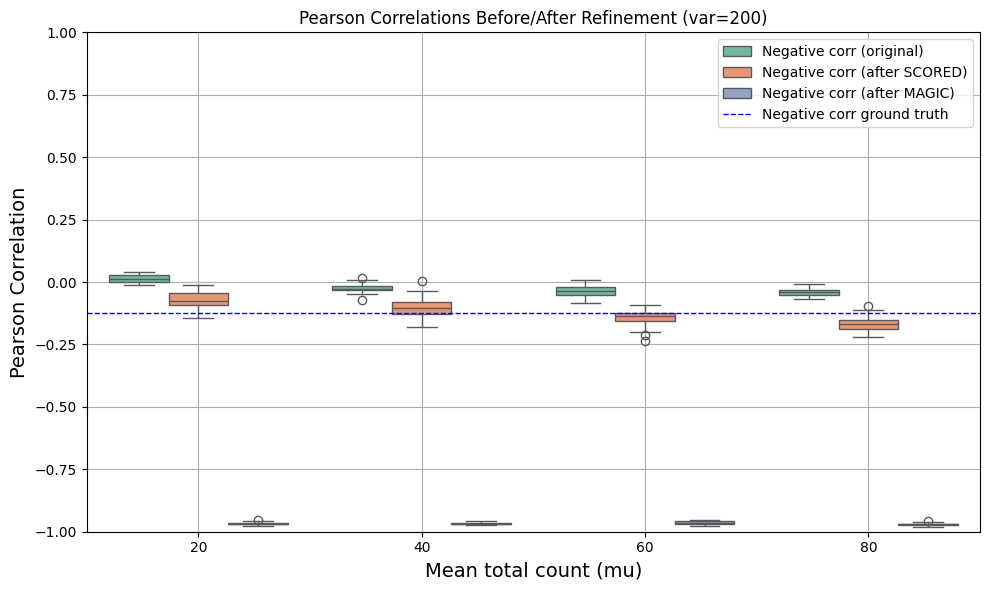

In [35]:



np.random.seed(3)


def simulate_negative_binomial_data(matrix, mu, var):
    """
    - Normalizes rows of 'matrix' to get probabilities per row.
    - Simulates total counts from NB(mu, var).
    - Samples from multinomial for each row.
    - Normalizes, multiplies by 100, then log1p.
    Returns a NumPy array of shape (cells, genes).
    """
    # Normalize to row sums
    row_sums = matrix.sum(axis=1, keepdims=True)
    prob_matrix = matrix / np.maximum(row_sums, 1e-12)

    if var <= mu:
        raise ValueError(f"Variance {var} must be > mean {mu} for a valid Negative Binomial.")

    # Calculate NB parameters
    n_float = mu**2 / (var - mu)  # shape
    if n_float <= 0:
        raise ValueError("Computed n is not positive. Check your mean/variance inputs.")
    p = n_float / (mu + n_float)  # success probability

    # Sample total counts from NB
    total_counts = np.random.negative_binomial(n_float, p, size=len(prob_matrix))
    total_counts = np.clip(total_counts, a_min=1, a_max=None).astype(int)

    # Multinomial to distribute across each row
    counts_matrix = np.array([
        np.random.multinomial(tc, row_p)
        for tc, row_p in zip(total_counts, prob_matrix)
    ])

    # Normalize by total_counts, log1p
    counts_matrix = counts_matrix / total_counts[:, np.newaxis]
    counts_matrix = counts_matrix * 100
    return np.log1p(counts_matrix)


def compute_cd8_and_cd4_cd8_correlations(expression_matrix,
                                         cd8_range=(15, 20),
                                         cd4_range=(0, 5)):
    """
    Returns two lists:
      - cd8_corrs: pairwise correlations among columns in cd8_range
      - cd4_cd8_corrs: pairwise correlations between cd4_range and cd8_range
    """
    # CD8 vs CD8
    start_cd8, end_cd8 = cd8_range
    cd8_corrs = []
    for i in range(start_cd8, end_cd8):
        for j in range(i+1, end_cd8):
            corr, _ = pearsonr(expression_matrix[:, i], expression_matrix[:, j])
            cd8_corrs.append(corr)

    # CD4 vs CD8
    start_cd4, end_cd4 = cd4_range
    cd4_cd8_corrs = []
    for i in range(start_cd4, end_cd4):
        for j in range(start_cd8, end_cd8):
            corr, _ = pearsonr(expression_matrix[:, i], expression_matrix[:, j])
            cd4_cd8_corrs.append(corr)

    return cd8_corrs, cd4_cd8_corrs

# ------------------------------------------------------
# Main loop: vary mu while fixing var = 100.
#    compute correlations BEFORE vs. AFTER RWR
#    for both CD8–CD8 and CD4–CD8.
# ------------------------------------------------------
mu_values = [20, 40, 60, 80]  # the range of mu
var_values = [100, 150, 200]
list_of_dfs_proposed = []

for var in var_values:

    results = []  # We'll accumulate (mu, group, correlation)

    for mu in mu_values:
        # (a) Simulate data
        sim_matrix = simulate_negative_binomial_data(
            matrix_combined_isoform, mu=mu, var=var
        )

        # (b) Compute correlations BEFORE
        cd8_corr_before, cd4_cd8_corr_before = compute_cd8_and_cd4_cd8_correlations(sim_matrix,
                                                                                  cd8_range=(15, 20),
                                                                                  cd4_range=(0, 5))

        # Create AnnData object
        gene_names = [f"Gene_{i+1}" for i in range(sim_matrix.shape[1])]
        adata = anndata.AnnData(X=sim_matrix)

        # (c) Run RWR algorithm
        new_matrix, P_final = rwr_impute(sim_matrix_df_norm, adata, alpha=0.3, max_iter=100, tol=1e-4, device=device)
        adata_new = adata.copy()
        adata_new.X = new_matrix

        # Perform the same analysis as before with adata_transcript_new
        sc.pp.normalize_total(adata_new, target_sum=1e2)
        sc.pp.log1p(adata_new)
        new_matrx = adata_new.X

        # (d) Compute correlations AFTER
        cd8_corr_after, cd4_cd8_corr_after = compute_cd8_and_cd4_cd8_correlations(new_matrix,
                                                                                  cd8_range=(15, 20),
                                                                                  cd4_range=(0, 5))

        # store each correlation with a label for 'group'.
        for val in cd8_corr_before:
            results.append((mu, "Positive corr (original)", val))
        for val in cd8_corr_after:
            results.append((mu, "Positive corr (after SCORED)", val))
        for val in cd4_cd8_corr_before:
            results.append((mu, "Negative corr (original)", val))
        for val in cd4_cd8_corr_after:
            results.append((mu, "Negative corr (after SCORED)", val))


    df = pd.DataFrame(results, columns=["mu", "group", "correlation"])
    df["method"] = "SCORED"
    df["var"] = var

    #if 'list_of_dfs_proposed' not in globals():
        #list_of_dfs_proposed = []

    list_of_dfs_proposed.append(df)



df_proposed = pd.concat(list_of_dfs_proposed, ignore_index=True)
df_magic = pd.read_csv("./magic_output/10x/simulation_magic_nonzero_t3.csv")

df_combined = pd.concat([df_proposed, df_magic], ignore_index=True)


for var in var_values:
    subset = df_combined[df_combined["var"] == var]

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=subset,
        x="mu",
        y="correlation",
        hue="group",
        palette="Set2",
        hue_order=["Positive corr (original)",  "Positive corr (after SCORED)",  "Positive corr (after MAGIC)"]

    )

    plt.axhline(positive_truth, color="red", linestyle="--", linewidth=1, label="Positive corr ground truth")

    plt.title(f"Pearson Correlations Before/After Refinement (var={var})")
    plt.ylim(-1, 1)
    plt.xlabel("Mean total count (mu)", fontsize=14)
    plt.ylabel("Pearson Correlation", fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for var in var_values:
    subset = df_combined[df_combined["var"] == var]

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=subset,
        x="mu",
        y="correlation",
        hue="group",
        palette="Set2",
        hue_order=["Negative corr (original)", "Negative corr (after SCORED)", "Negative corr (after MAGIC)"]

    )

    plt.axhline(negative_truth, color="blue", linestyle="--", linewidth=1, label="Negative corr ground truth")

    plt.title(f"Pearson Correlations Before/After Refinement (var={var})")
    plt.ylim(-1, 1)
    plt.xlabel("Mean total count (mu)", fontsize=14)
    plt.ylabel("Pearson Correlation", fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.


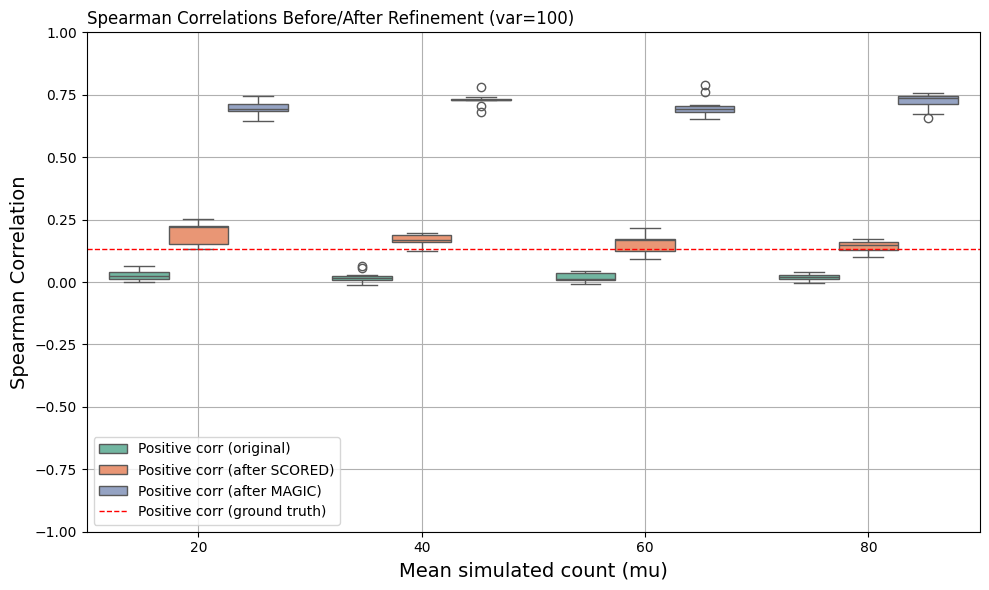

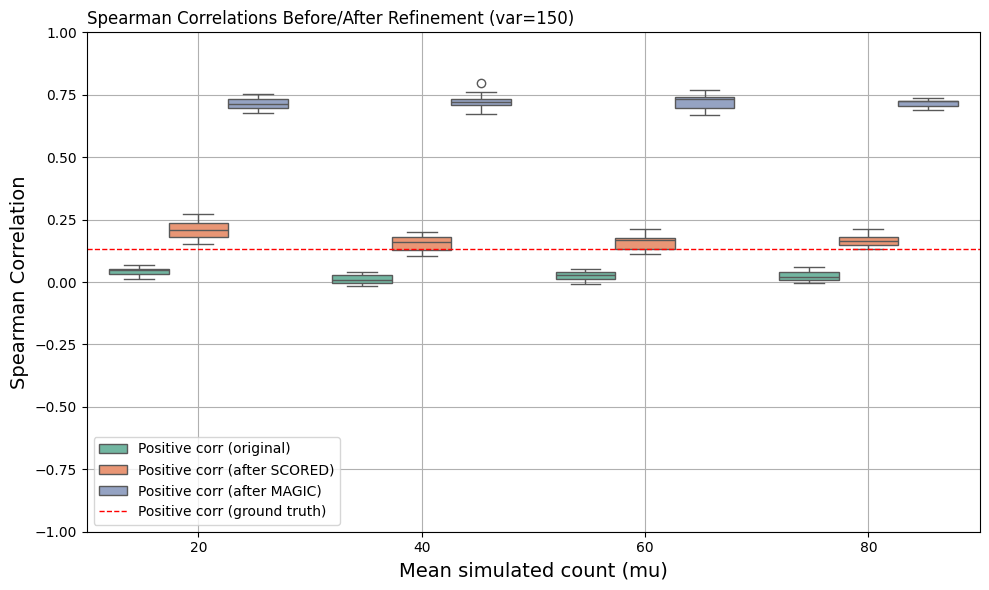

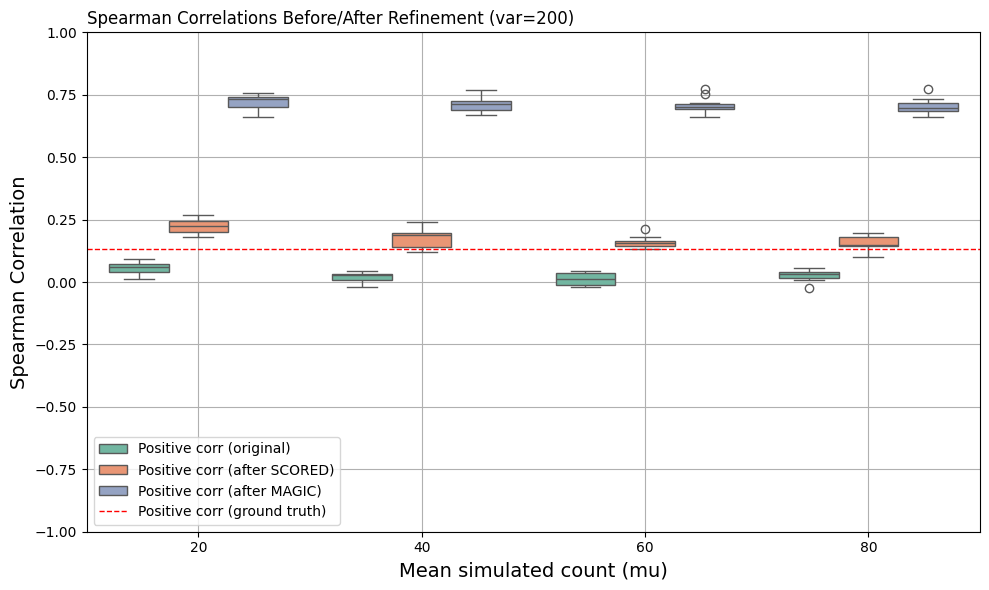

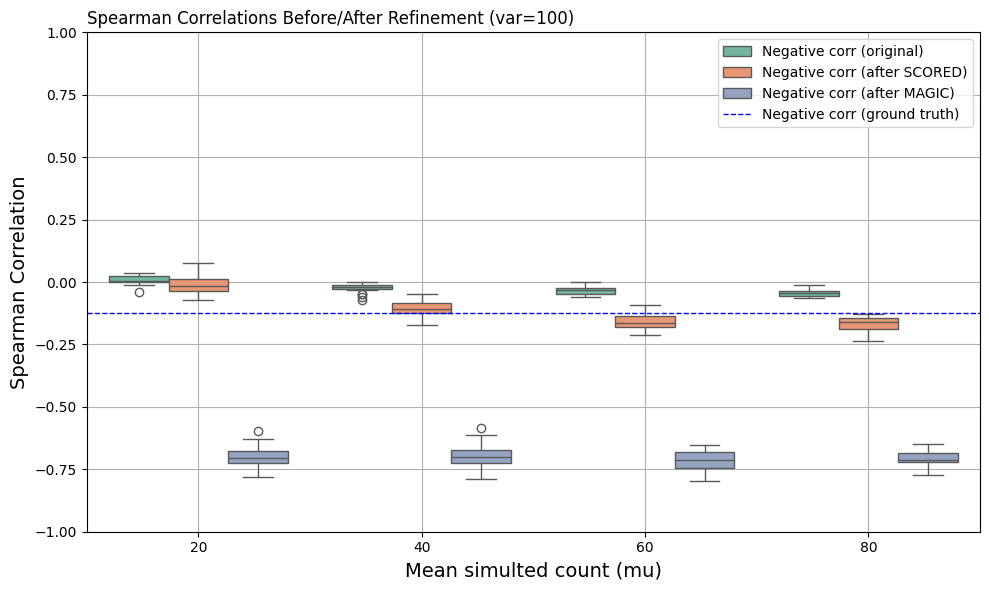

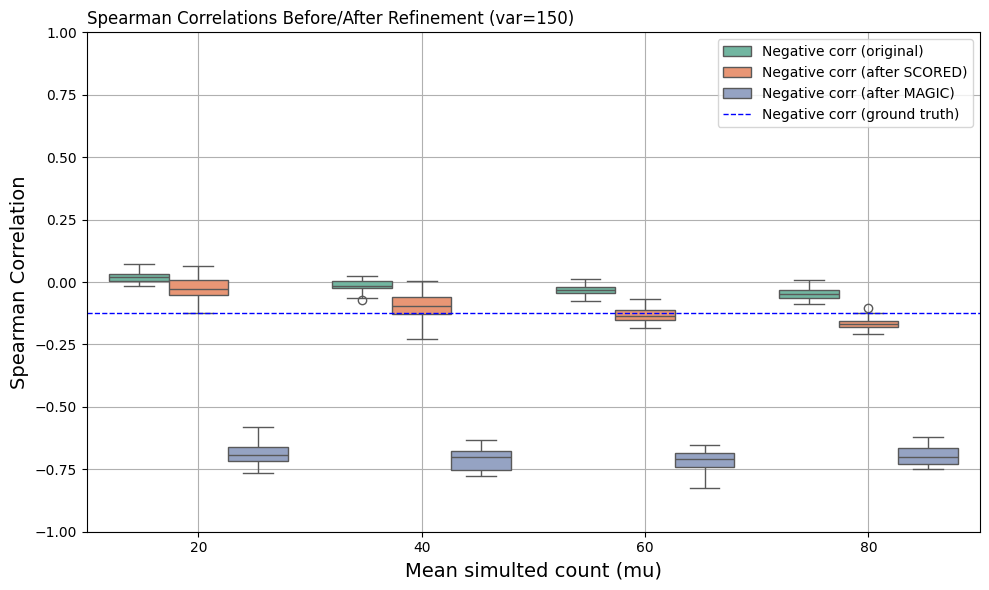

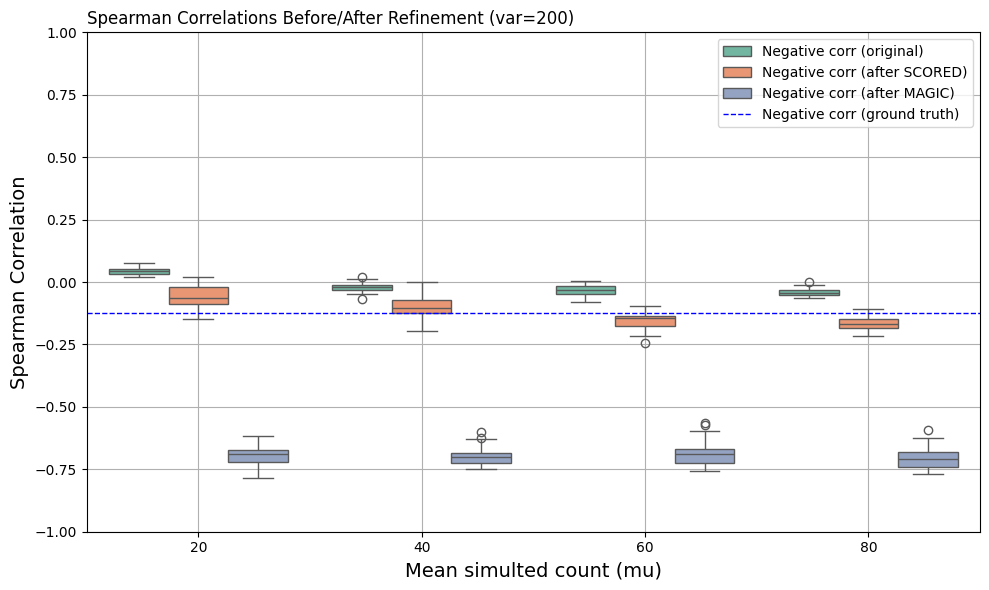

In [36]:



np.random.seed(3)

def simulate_negative_binomial_data(matrix, mu, var):
    """
    - Normalizes rows of 'matrix' to get probabilities per row.
    - Simulates total counts from NB(mu, var).
    - Samples from multinomial for each row.
    - Normalizes, multiplies by 100, then log1p.
    Returns a NumPy array of shape (cells, genes).
    """
    # Normalize to row sums
    row_sums = matrix.sum(axis=1, keepdims=True)
    prob_matrix = matrix / np.maximum(row_sums, 1e-12)

    if var <= mu:
        raise ValueError(f"Variance {var} must be > mean {mu} for a valid Negative Binomial.")

    # Calculate NB parameters
    n_float = mu**2 / (var - mu)  # shape
    if n_float <= 0:
        raise ValueError("Computed n is not positive. Check your mean/variance inputs.")
    p = n_float / (mu + n_float)  # success probability

    # Sample total counts from NB
    total_counts = np.random.negative_binomial(n_float, p, size=len(prob_matrix))
    total_counts = np.clip(total_counts, a_min=1, a_max=None).astype(int)

    # Multinomial to distribute across each row
    counts_matrix = np.array([
        np.random.multinomial(tc, row_p)
        for tc, row_p in zip(total_counts, prob_matrix)
    ])

    # Normalize by total_counts, log1p
    counts_matrix = counts_matrix / total_counts[:, np.newaxis]
    counts_matrix = counts_matrix * 100
    return np.log1p(counts_matrix)


def compute_cd8_and_cd4_cd8_correlations(expression_matrix,
                                         cd8_range=(15, 20),
                                         cd4_range=(0, 5)):
    """
    Returns two lists:
      - cd8_corrs: pairwise correlations among columns in cd8_range
      - cd4_cd8_corrs: pairwise correlations between cd4_range and cd8_range
    """

    start_cd8, end_cd8 = cd8_range
    cd8_corrs = []
    for i in range(start_cd8, end_cd8):
        for j in range(i+1, end_cd8):
            corr, _ = spearmanr(expression_matrix[:, i], expression_matrix[:, j])
            cd8_corrs.append(corr)

    start_cd4, end_cd4 = cd4_range
    cd4_cd8_corrs = []
    for i in range(start_cd4, end_cd4):
        for j in range(start_cd8, end_cd8):
            corr, _ = spearmanr(expression_matrix[:, i], expression_matrix[:, j])
            cd4_cd8_corrs.append(corr)

    return cd8_corrs, cd4_cd8_corrs

# ------------------------------------------------------
# Main loop: vary mu while fixing var = 100.
#    compute correlations BEFORE vs. AFTER RWR
#    for both CD8–CD8 and CD4–CD8.
# ------------------------------------------------------
mu_values = [20, 40, 60, 80]  # the range of mu
var_values = [100, 150, 200]
list_of_dfs_proposed = []

for var in var_values:

    results = []  # accumulate (mu, group, correlation)

    for mu in mu_values:
        # (a) Simulate data
        sim_matrix = simulate_negative_binomial_data(
            matrix_combined_isoform, mu=mu, var=var
        )

        # (b) Compute correlations BEFORE
        cd8_corr_before, cd4_cd8_corr_before = compute_cd8_and_cd4_cd8_correlations(sim_matrix,
                                                                                  cd8_range=(15, 20),
                                                                                  cd4_range=(0, 5))

        # Create AnnData object
        gene_names = [f"Gene_{i+1}" for i in range(sim_matrix.shape[1])]
        adata = anndata.AnnData(X=sim_matrix)

        # (c) Run RWR algorithm
        new_matrix, P_final = rwr_impute(sim_matrix_df_norm, adata, alpha=0.3, max_iter=100, tol=1e-4, device=device)
        adata_new = adata.copy()
        adata_new.X = new_matrix

        # Perform the same analysis as before with adata_transcript_new
        sc.pp.normalize_total(adata_new, target_sum=1e2)
        sc.pp.log1p(adata_new)
        new_matrx = adata_new.X

        # (d) Compute correlations AFTER
        cd8_corr_after, cd4_cd8_corr_after = compute_cd8_and_cd4_cd8_correlations(new_matrix,
                                                                                  cd8_range=(15, 20),
                                                                                  cd4_range=(0, 5))

        # Collect results in list
        for val in cd8_corr_before:
            results.append((mu, "Positive corr (original)", val))
        for val in cd8_corr_after:
            results.append((mu, "Positive corr (after SCORED)", val))
        for val in cd4_cd8_corr_before:
            results.append((mu, "Negative corr (original)", val))
        for val in cd4_cd8_corr_after:
            results.append((mu, "Negative corr (after SCORED)", val))


    df = pd.DataFrame(results, columns=["mu", "group", "correlation"])
    df["method"] = "SCORED"
    df["var"] = var

    #if 'list_of_dfs_proposed' not in globals():
        #list_of_dfs_proposed = []

    list_of_dfs_proposed.append(df)


df_proposed = pd.concat(list_of_dfs_proposed, ignore_index=True)
df_magic = pd.read_csv("./magic_output/10x/simulation_magic_nonzero_t3_spearman.csv")

df_combined = pd.concat([df_proposed, df_magic], ignore_index=True)


for var in var_values:
    subset = df_combined[df_combined["var"] == var]

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=subset,
        x="mu",
        y="correlation",
        hue="group",
        palette="Set2",
        hue_order=["Positive corr (original)",  "Positive corr (after SCORED)",  "Positive corr (after MAGIC)"]

    )

    plt.axhline(positive_truth, color="red", linestyle="--", linewidth=1, label="Positive corr (ground truth)")

    plt.title(f"Spearman Correlations Before/After Refinement (var={var})", loc='left')
    plt.ylim(-1, 1)
    plt.xlabel("Mean simulated count (mu)", fontsize=14)
    plt.ylabel("Spearman Correlation", fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for var in var_values:
    subset = df_combined[df_combined["var"] == var]

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=subset,
        x="mu",
        y="correlation",
        hue="group",
        palette="Set2",
        hue_order=["Negative corr (original)", "Negative corr (after SCORED)", "Negative corr (after MAGIC)"]

    )

    plt.axhline(negative_truth, color="blue", linestyle="--", linewidth=1, label="Negative corr (ground truth)")

    plt.title(f"Spearman Correlations Before/After Refinement (var={var})", loc='left')
    plt.ylim(-1, 1)
    plt.xlabel("Mean simulted count (mu)", fontsize=14)
    plt.ylabel("Spearman Correlation", fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.


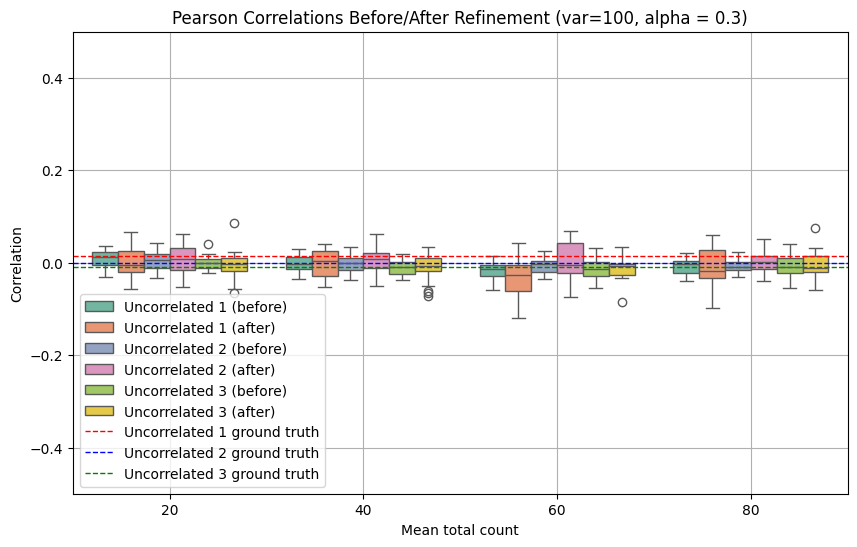

Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.


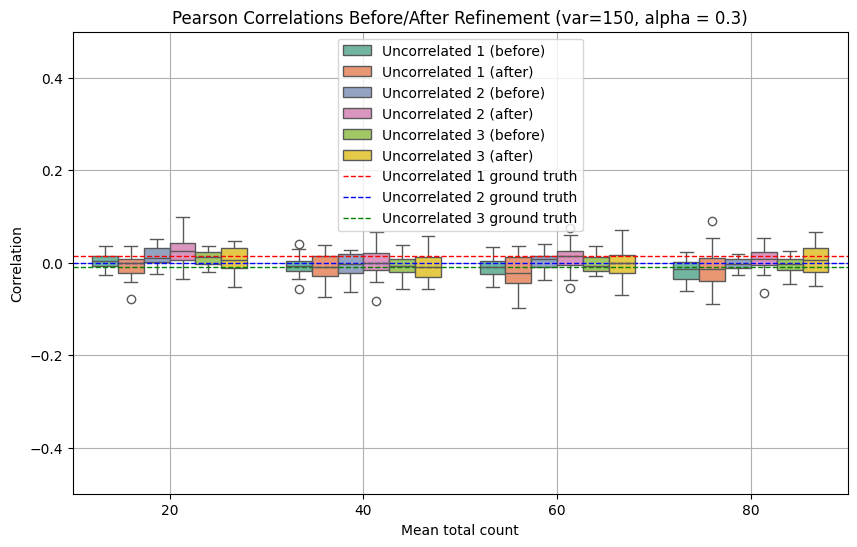

Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.


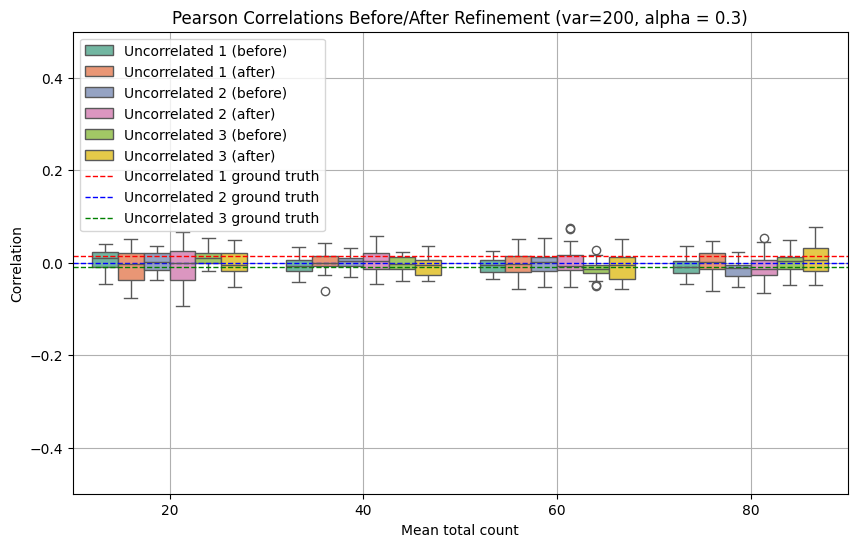

In [37]:

np.random.seed(3)


def simulate_negative_binomial_data(matrix, mu, var):
    """
    - Normalizes rows of 'matrix' to get probabilities per row.
    - Simulates total counts from NB(mu, var).
    - Samples from multinomial for each row.
    - Normalizes, multiplies by 100, then log1p.
    Returns a NumPy array of shape (cells, genes).
    """
    # Normalize to row sums
    row_sums = matrix.sum(axis=1, keepdims=True)
    prob_matrix = matrix / np.maximum(row_sums, 1e-12)

    if var <= mu:
        raise ValueError(f"Variance {var} must be > mean {mu} for a valid Negative Binomial.")

    # Calculate NB parameters
    n_float = mu**2 / (var - mu)  # shape
    if n_float <= 0:
        raise ValueError("Computed n is not positive. Check your mean/variance inputs.")
    p = n_float / (mu + n_float)  # success probability

    # Sample total counts from NB
    total_counts = np.random.negative_binomial(n_float, p, size=len(prob_matrix))
    total_counts = np.clip(total_counts, a_min=1, a_max=None).astype(int)

    # Multinomial to distribute across each row
    counts_matrix = np.array([
        np.random.multinomial(tc, row_p)
        for tc, row_p in zip(total_counts, prob_matrix)
    ])

    # Normalize by total_counts, log1p
    counts_matrix = counts_matrix / total_counts[:, np.newaxis]
    counts_matrix = counts_matrix * 100
    return np.log1p(counts_matrix)


def compute_cd8_and_cd4_cd8_correlations(expression_matrix,
                                         cd8_range=(15, 20),
                                         cd4_range=(0, 5)):
    """
    Returns two lists:
      - cd8_corrs: pairwise correlations among columns in cd8_range
      - cd4_cd8_corrs: pairwise correlations between cd4_range and cd8_range
    """
    # CD8 vs noise
    start_cd8, end_cd8 = cd8_range
    cd8_corrs = []
    for i in range(start_cd8, end_cd8):
        for j in range(40, 45):
            corr, _ = pearsonr(expression_matrix[:, i], expression_matrix[:, j])
            cd8_corrs.append(corr)

    # CD4 vs noise
    start_cd4, end_cd4 = cd4_range
    cd4_cd8_corrs = []
    for i in range(start_cd4, end_cd4):
        for j in range(40, 45):
            corr, _ = pearsonr(expression_matrix[:, i], expression_matrix[:, j])
            cd4_cd8_corrs.append(corr)

    # noise vs noise
    noise_corrs = []
    for i in range(40, 45):
        for j in range(46, 50):
            corr, _ = pearsonr(expression_matrix[:, i], expression_matrix[:, j])
            noise_corrs.append(corr)

    return cd8_corrs, cd4_cd8_corrs, noise_corrs

# ------------------------------------------------------
# Main loop: vary mu while fixing var = 100.
#    compute correlations BEFORE vs. AFTER RWR
#    for both CD8–CD8 and CD4–CD8.
# ------------------------------------------------------
mu_values = [20, 40, 60, 80]  # the range of mu
var_values = [100, 150, 200]

for var in var_values:

    results = []  # accumulate (mu, group, correlation)

    for mu in mu_values:
        # (a) Simulate data
        sim_matrix = simulate_negative_binomial_data(
            matrix_combined_isoform, mu=mu, var=var
        )

        # (b) Compute correlations BEFORE
        cd8_corr_before, cd4_cd8_corr_before, noise_corr_before = compute_cd8_and_cd4_cd8_correlations(sim_matrix,
                                                                                  cd8_range=(15, 20),
                                                                                  cd4_range=(0, 5))

        # Create AnnData object
        gene_names = [f"Gene_{i+1}" for i in range(sim_matrix.shape[1])]
        adata = anndata.AnnData(X=sim_matrix)

        # (c) Run RWR algorithm
        new_matrix, P_final = rwr_impute(sim_matrix_df_norm, adata, alpha=0.3, max_iter=100, tol=1e-4, device=device)
        adata_new = adata.copy()
        adata_new.X = new_matrix

        # Perform the same analysis as before with adata_transcript_new
        sc.pp.normalize_total(adata_new, target_sum=1e2)
        sc.pp.log1p(adata_new)
        new_matrx = adata_new.X

        # (d) Compute correlations AFTER
        cd8_corr_after, cd4_cd8_corr_after, noise_corr_after = compute_cd8_and_cd4_cd8_correlations(new_matrix,
                                                                                  cd8_range=(15, 20),
                                                                                  cd4_range=(0, 5))

        # Collect results in list
        for val in cd8_corr_before:
            results.append((mu, "Uncorrelated 1 (before)", val))
        for val in cd8_corr_after:
            results.append((mu, "Uncorrelated 1 (after)", val))
        for val in cd4_cd8_corr_before:
            results.append((mu, "Uncorrelated 2 (before)", val))
        for val in cd4_cd8_corr_after:
            results.append((mu, "Uncorrelated 2 (after)", val))
        for val in noise_corr_before:
            results.append((mu, "Uncorrelated 3 (before)", val))
        for val in noise_corr_after:
            results.append((mu, "Uncorrelated 3 (after)", val))


    df = pd.DataFrame(results, columns=["mu", "group", "correlation"])


    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x="mu", y="correlation", hue="group", palette="Set2")
    #sns.stripplot(data=df, x="mu", y="correlation", hue="group", dodge=True, color="black", alpha=0.3)
    #plt.axhline(positive_truth, color="red", linestyle="--", linewidth=1, label="Positive pairs ground truth")
    plt.axhline(uncorrelated_1_truth, color="red", linestyle="--", linewidth=1, label="Uncorrelated 1 ground truth")
    plt.axhline(uncorrelated_2_truth+0.005, color="blue", linestyle="--", linewidth=1, label="Uncorrelated 2 ground truth")
    plt.axhline(uncorrelated_3_truth-0.005, color="green", linestyle="--", linewidth=1, label="Uncorrelated 3 ground truth")


    plt.title(f"Pearson Correlations Before/After Refinement (var={var}, alpha = 0.3)")
    plt.ylim(-0.5, 0.5)
    plt.xlabel("Mean total count")
    plt.ylabel("Correlation")
    plt.legend()
    plt.grid(True)
    plt.show()


Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.


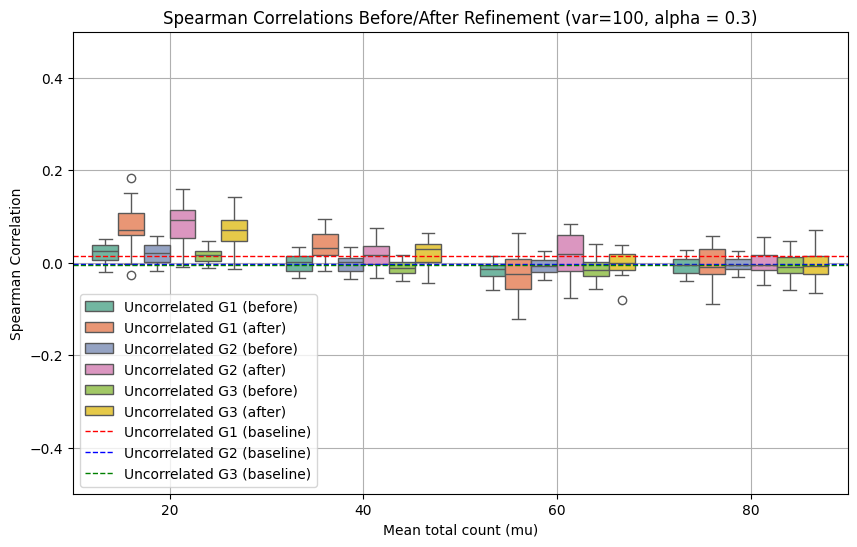

Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.


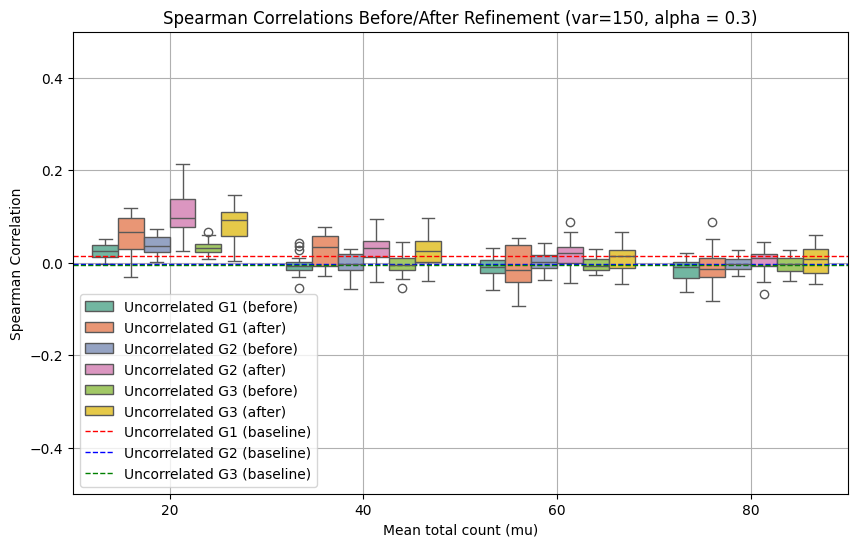

Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.


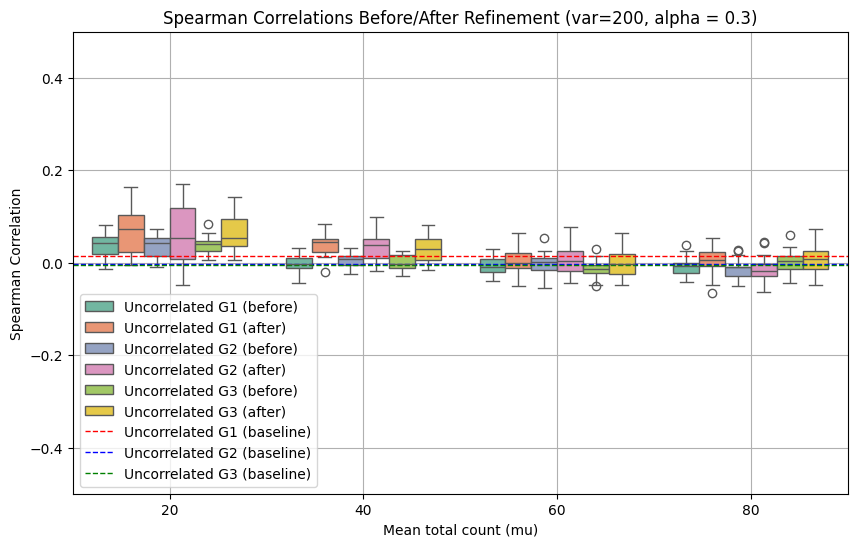

In [38]:
np.random.seed(3)


def simulate_negative_binomial_data(matrix, mu, var):
    """
    - Normalizes rows of 'matrix' to get probabilities per row.
    - Simulates total counts from NB(mu, var).
    - Samples from multinomial for each row.
    - Normalizes, multiplies by 100, then log1p.
    Returns a NumPy array of shape (cells, genes).
    """
    # Normalize to row sums
    row_sums = matrix.sum(axis=1, keepdims=True)
    prob_matrix = matrix / np.maximum(row_sums, 1e-12)

    if var <= mu:
        raise ValueError(f"Variance {var} must be > mean {mu} for a valid Negative Binomial.")

    # Calculate NB parameters
    n_float = mu**2 / (var - mu)  # shape parameter
    if n_float <= 0:
        raise ValueError("Computed n is not positive. Check your mean/variance inputs.")
    p = n_float / (mu + n_float)  # success probability

    # Sample total counts from NB
    total_counts = np.random.negative_binomial(n_float, p, size=len(prob_matrix))
    total_counts = np.clip(total_counts, a_min=1, a_max=None).astype(int)

    # Multinomial to distribute across each row
    counts_matrix = np.array([
        np.random.multinomial(tc, row_p)
        for tc, row_p in zip(total_counts, prob_matrix)
    ])

    # Normalize by total_counts, log1p
    counts_matrix = counts_matrix / total_counts[:, np.newaxis]
    counts_matrix = counts_matrix * 100
    return np.log1p(counts_matrix)


def compute_cd8_and_cd4_cd8_correlations(expression_matrix,
                                         cd8_range=(15, 20),
                                         cd4_range=(0, 5)):
    """
    Returns three lists:
      - cd8_corrs: Spearman correlations between columns in cd8_range and noise columns (columns 40-44)
      - cd4_cd8_corrs: Spearman correlations between columns in cd4_range and noise columns (columns 40-44)
      - noise_corrs: Spearman correlations between noise columns (columns 40-44 and 46-49)
    """
    # CD8 vs noise
    start_cd8, end_cd8 = cd8_range
    cd8_corrs = []
    for i in range(start_cd8, end_cd8):
        for j in range(40, 45):
            corr, _ = spearmanr(expression_matrix[:, i], expression_matrix[:, j])
            cd8_corrs.append(corr)

    # CD4 vs noise
    start_cd4, end_cd4 = cd4_range
    cd4_cd8_corrs = []
    for i in range(start_cd4, end_cd4):
        for j in range(40, 45):
            corr, _ = spearmanr(expression_matrix[:, i], expression_matrix[:, j])
            cd4_cd8_corrs.append(corr)

    # noise vs noise
    noise_corrs = []
    for i in range(40, 45):
        for j in range(46, 50):
            corr, _ = spearmanr(expression_matrix[:, i], expression_matrix[:, j])
            noise_corrs.append(corr)

    return cd8_corrs, cd4_cd8_corrs, noise_corrs

# ------------------------------------------------------
# Main loop: vary mu while fixing var = 100, 150, 200.
#    Compute correlations BEFORE vs. AFTER RWR for these comparisons.
# ------------------------------------------------------
mu_values = [20, 40, 60, 80]  # the range of mu values
var_values = [100, 150, 200]


for var in var_values:

    results = []  # accumulate (mu, group, correlation)

    for mu in mu_values:
        # (a) Simulate data
        sim_matrix = simulate_negative_binomial_data(
            matrix_combined_isoform, mu=mu, var=var
        )

        # (b) Compute correlations BEFORE RWR refinement
        cd8_corr_before, cd4_cd8_corr_before, noise_corr_before = compute_cd8_and_cd4_cd8_correlations(
            sim_matrix, cd8_range=(15, 20), cd4_range=(0, 5)
        )

        # Create AnnData object
        gene_names = [f"Gene_{i+1}" for i in range(sim_matrix.shape[1])]
        adata = anndata.AnnData(X=sim_matrix)
        adata.var['gene_names'] = gene_names

        # (c) Run RWR algorithm
        new_matrix, P_final = rwr_impute(sim_matrix_df_norm, adata, alpha=0.3, max_iter=100, tol=1e-4, device=device)
        adata_new = adata.copy()
        adata_new.X = new_matrix

        # Perform the same normalization on the refined data
        sc.pp.normalize_total(adata_new, target_sum=1e2)
        sc.pp.log1p(adata_new)
        new_matrix = adata_new.X  # refined matrix

        # (d) Compute correlations AFTER RWR refinement
        cd8_corr_after, cd4_cd8_corr_after, noise_corr_after = compute_cd8_and_cd4_cd8_correlations(
            new_matrix, cd8_range=(15, 20), cd4_range=(0, 5)
        )

        # Collect results (each correlation is stored with a label)
        for val in cd8_corr_before:
            results.append((mu, "Uncorrelated G1 (before)", val))
        for val in cd8_corr_after:
            results.append((mu, "Uncorrelated G1 (after)", val))
        for val in cd4_cd8_corr_before:
            results.append((mu, "Uncorrelated G2 (before)", val))
        for val in cd4_cd8_corr_after:
            results.append((mu, "Uncorrelated G2 (after)", val))
        for val in noise_corr_before:
            results.append((mu, "Uncorrelated G3 (before)", val))
        for val in noise_corr_after:
            results.append((mu, "Uncorrelated G3 (after)", val))


    df = pd.DataFrame(results, columns=["mu", "group", "correlation"])


    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x="mu", y="correlation", hue="group", palette="Set2")
    # sns.stripplot(data=df, x="mu", y="correlation", hue="group", dodge=True, color="black", alpha=0.3)

    plt.axhline(uncorrelated_1_truth, color="red", linestyle="--", linewidth=1, label="Uncorrelated G1 (baseline)")
    plt.axhline(uncorrelated_2_truth+0.002, color="blue", linestyle="--", linewidth=1, label="Uncorrelated G2 (baseline)")
    plt.axhline(uncorrelated_3_truth-0.002, color="green", linestyle="--", linewidth=1, label="Uncorrelated G3 (baseline)")

    plt.title(f"Spearman Correlations Before/After Refinement (var={var}, alpha = 0.3)")
    plt.ylim(-0.5, 0.5)
    plt.xlabel("Mean total count (mu)")
    plt.ylabel("Spearman Correlation")
    plt.legend()
    plt.grid(True)
    plt.show()

Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.


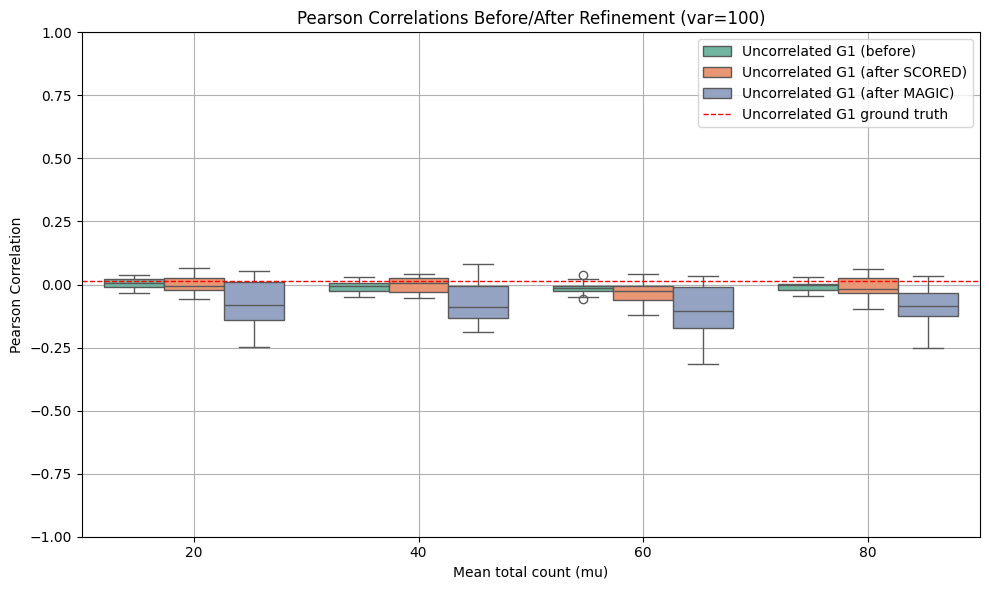

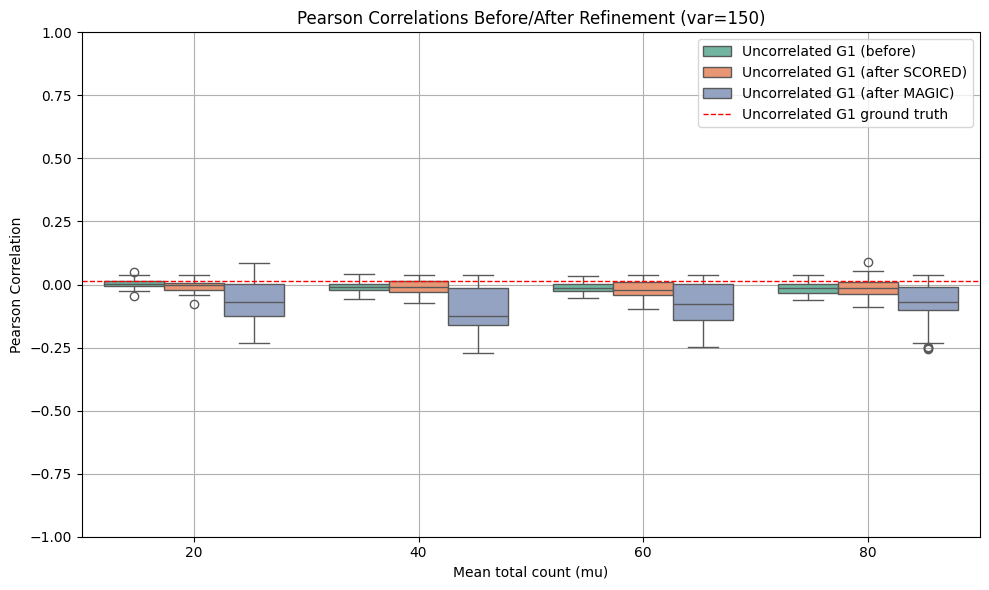

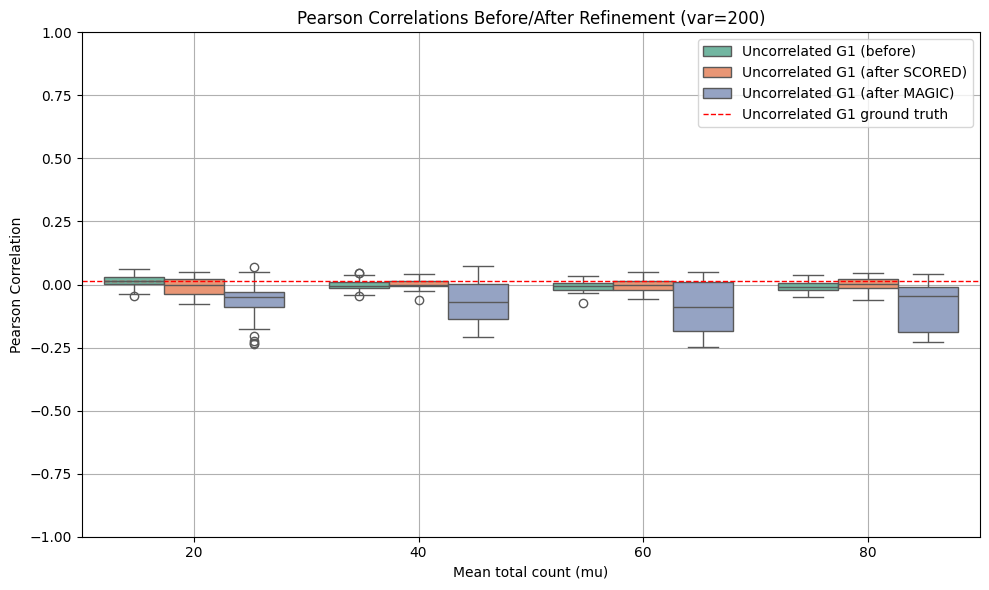

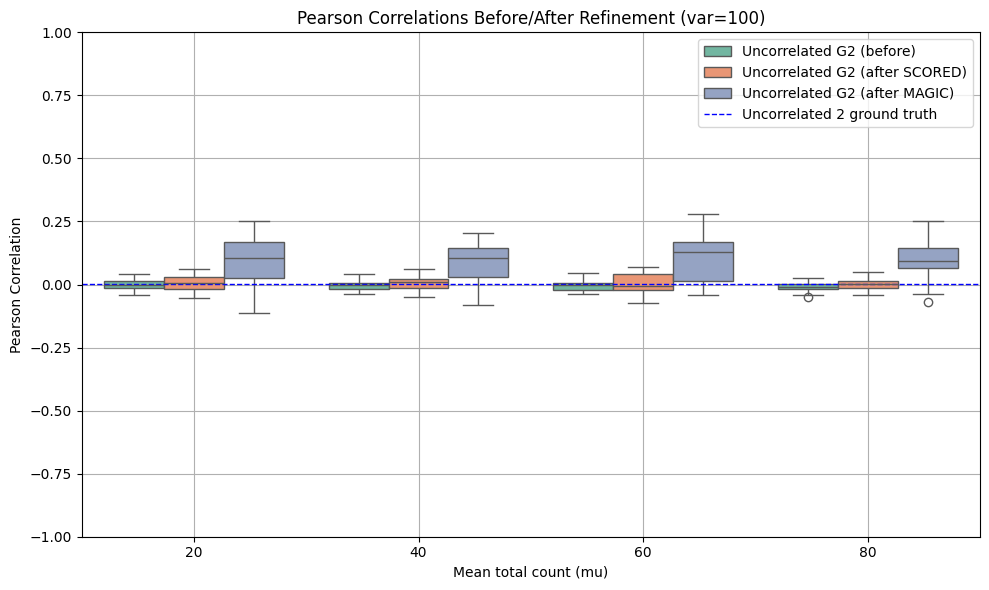

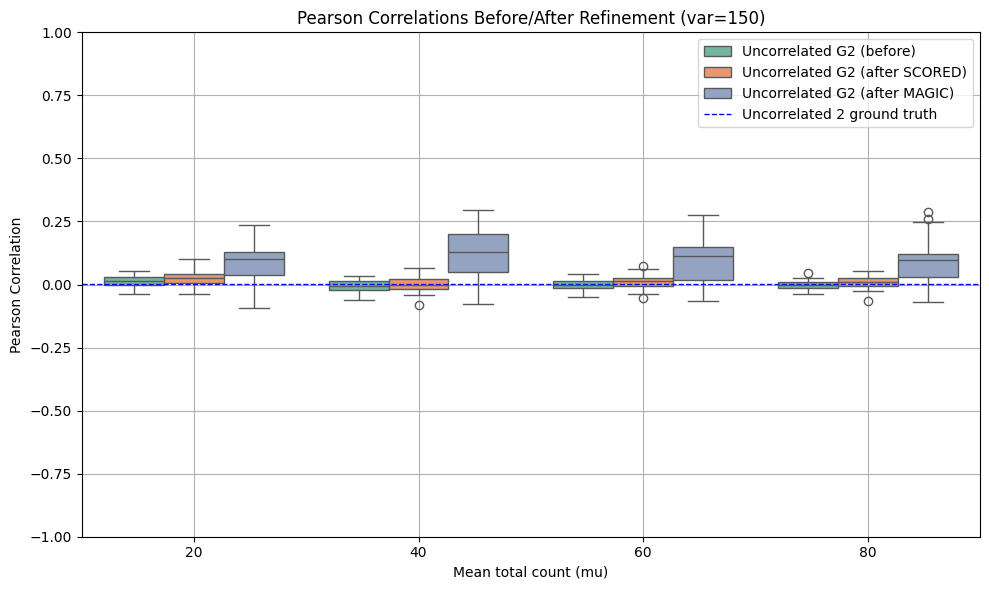

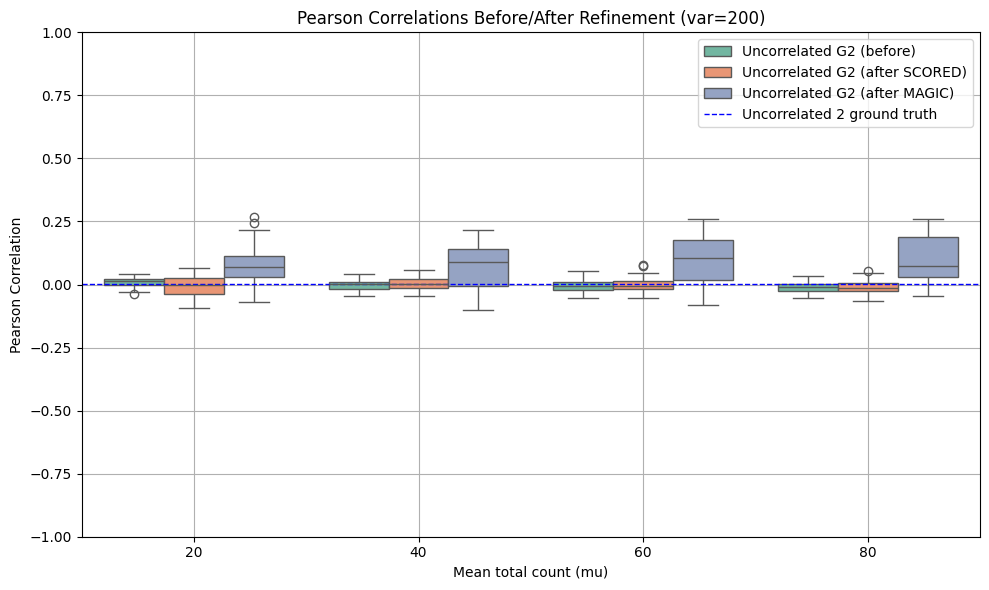

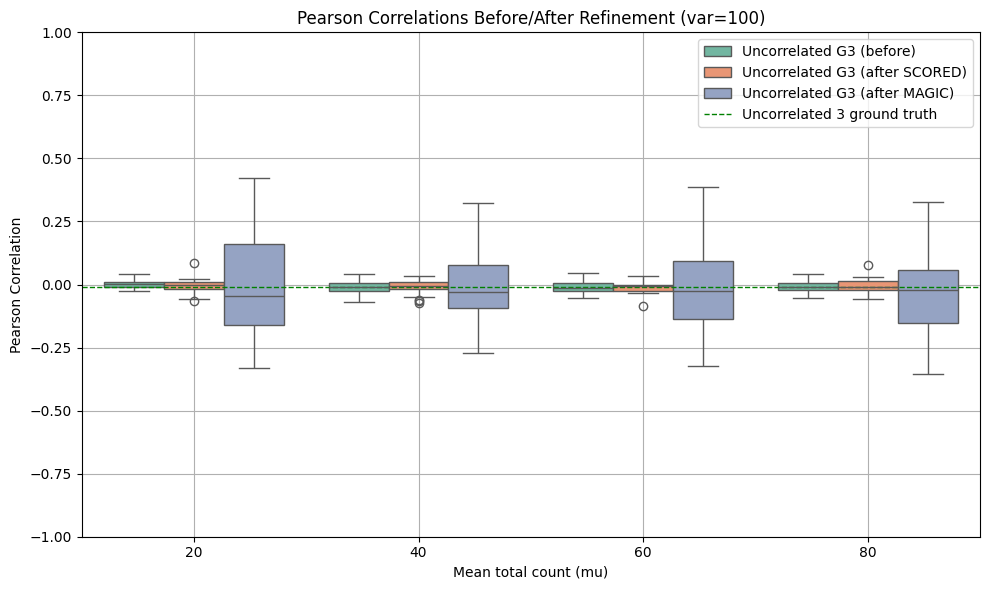

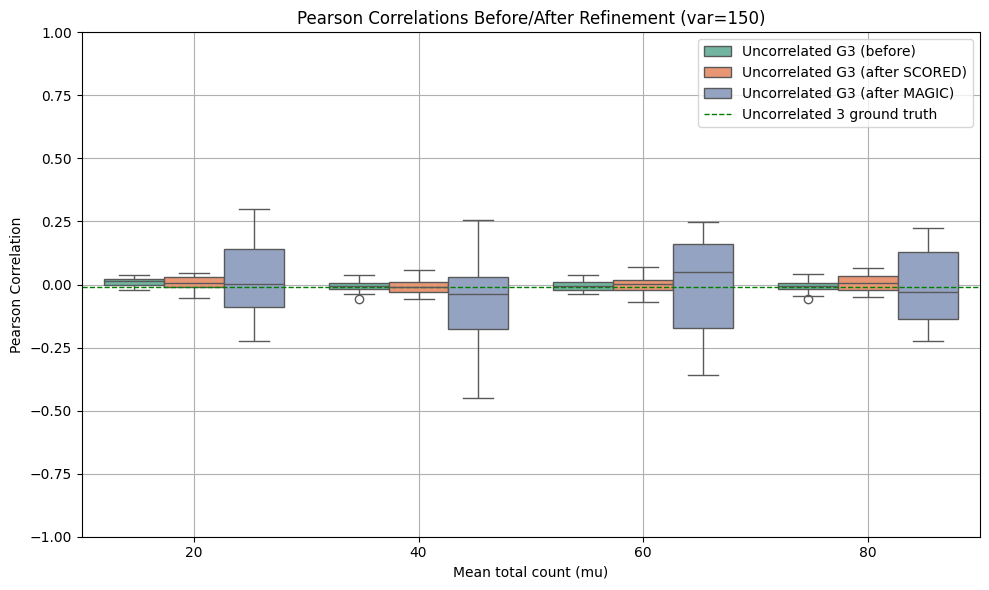

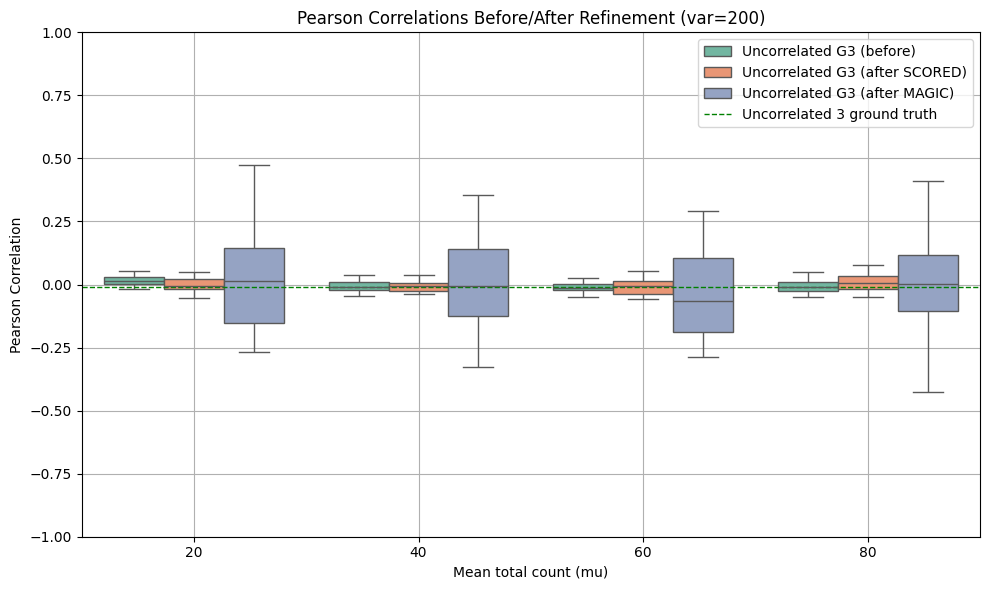

In [39]:

np.random.seed(3)


def simulate_negative_binomial_data(matrix, mu, var):
    """
    - Normalizes rows of 'matrix' to get probabilities per row.
    - Simulates total counts from NB(mu, var).
    - Samples from multinomial for each row.
    - Normalizes, multiplies by 100, then log1p.
    Returns a NumPy array of shape (cells, genes).
    """
    # Normalize to row sums
    row_sums = matrix.sum(axis=1, keepdims=True)
    prob_matrix = matrix / np.maximum(row_sums, 1e-12)

    if var <= mu:
        raise ValueError(f"Variance {var} must be > mean {mu} for a valid Negative Binomial.")

    # Calculate NB parameters
    n_float = mu**2 / (var - mu)  # shape
    if n_float <= 0:
        raise ValueError("Computed n is not positive. Check your mean/variance inputs.")
    p = n_float / (mu + n_float)  # success probability

    # Sample total counts from NB
    total_counts = np.random.negative_binomial(n_float, p, size=len(prob_matrix))
    total_counts = np.clip(total_counts, a_min=1, a_max=None).astype(int)

    # Multinomial to distribute across each row
    counts_matrix = np.array([
        np.random.multinomial(tc, row_p)
        for tc, row_p in zip(total_counts, prob_matrix)
    ])

    # Normalize by total_counts, scale by 100, log1p
    counts_matrix = counts_matrix / total_counts[:, np.newaxis]
    counts_matrix = counts_matrix * 100
    return np.log1p(counts_matrix)


def compute_cd8_and_cd4_cd8_correlations(expression_matrix,
                                         cd8_range=(15, 20),
                                         cd4_range=(0, 5)):
    """
    Returns two lists:
      - cd8_corrs: pairwise correlations among columns in cd8_range
      - cd4_cd8_corrs: pairwise correlations between cd4_range and cd8_range
    """
    # CD8 vs noise
    start_cd8, end_cd8 = cd8_range
    cd8_corrs = []
    for i in range(start_cd8, end_cd8):
        for j in range(40, 45):
            corr, _ = pearsonr(expression_matrix[:, i], expression_matrix[:, j])
            cd8_corrs.append(corr)

    # CD4 vs noise
    start_cd4, end_cd4 = cd4_range
    cd4_cd8_corrs = []
    for i in range(start_cd4, end_cd4):
        for j in range(40, 45):
            corr, _ = pearsonr(expression_matrix[:, i], expression_matrix[:, j])
            cd4_cd8_corrs.append(corr)

    # noise vs noise
    noise_corrs = []
    for i in range(40, 45):
        for j in range(46, 50):
            corr, _ = pearsonr(expression_matrix[:, i], expression_matrix[:, j])
            noise_corrs.append(corr)

    return cd8_corrs, cd4_cd8_corrs, noise_corrs

# ------------------------------------------------------
# Main loop: vary mu while fixing var = 100.
#    compute correlations BEFORE vs. AFTER RWR
#    for both CD8–CD8 and CD4–CD8.
# ------------------------------------------------------
mu_values = [20, 40, 60, 80]  # the range of mu
var_values = [100, 150, 200]
list_of_dfs_proposed = []

for var in var_values:

    results = []  # accumulate (mu, group, correlation)

    for mu in mu_values:
        # (a) Simulate data
        sim_matrix = simulate_negative_binomial_data(
            matrix_combined_isoform, mu=mu, var=var
        )

        # (b) Compute correlations BEFORE
        cd8_corr_before, cd4_cd8_corr_before, noise_corr_before = compute_cd8_and_cd4_cd8_correlations(sim_matrix,
                                                                                  cd8_range=(15, 20),
                                                                                  cd4_range=(0, 5))

        # Create AnnData object
        gene_names = [f"Gene_{i+1}" for i in range(sim_matrix.shape[1])]
        adata = anndata.AnnData(X=sim_matrix)

        # (c) Run RWR algorithm
        new_matrix, P_final = rwr_impute(sim_matrix_df_norm, adata, alpha=0.3, max_iter=100, tol=1e-4, device=device)
        adata_new = adata.copy()
        adata_new.X = new_matrix

        # Perform the same analysis as before with adata_transcript_new
        sc.pp.normalize_total(adata_new, target_sum=1e2)
        sc.pp.log1p(adata_new)
        new_matrx = adata_new.X

        # (d) Compute correlations AFTER
        cd8_corr_after, cd4_cd8_corr_after, noise_corr_after = compute_cd8_and_cd4_cd8_correlations(new_matrix,
                                                                                  cd8_range=(15, 20),
                                                                                  cd4_range=(0, 5))

        # Collect results in list
        for val in cd8_corr_before:
            results.append((mu, "Uncorrelated G1 (before)", val))
        for val in cd8_corr_after:
            results.append((mu, "Uncorrelated G1 (after SCORED)", val))
        for val in cd4_cd8_corr_before:
            results.append((mu, "Uncorrelated G2 (before)", val))
        for val in cd4_cd8_corr_after:
            results.append((mu, "Uncorrelated G2 (after SCORED)", val))
        for val in noise_corr_before:
            results.append((mu, "Uncorrelated G3 (before)", val))
        for val in noise_corr_after:
            results.append((mu, "Uncorrelated G3 (after SCORED)", val))


    df = pd.DataFrame(results, columns=["mu", "group", "correlation"])

    df["method"] = "Proposed"
    df["var"] = var

    #if 'list_of_dfs_proposed' not in globals():
        #list_of_dfs_proposed = []

    list_of_dfs_proposed.append(df)

df_proposed = pd.concat(list_of_dfs_proposed, ignore_index=True)
df_magic = pd.read_csv("./magic_output/10x/simulation_magic_zero_t3.csv")

df_combined = pd.concat([df_proposed, df_magic], ignore_index=True)


for var in var_values:
    subset = df_combined[df_combined["var"] == var]

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=subset,
        x="mu",
        y="correlation",
        hue="group",
        palette="Set2",
        hue_order=["Uncorrelated G1 (before)",
                   "Uncorrelated G1 (after SCORED)",
                   "Uncorrelated G1 (after MAGIC)"]

    )

    plt.axhline(uncorrelated_1_truth, color="red", linestyle="--", linewidth=1, label="Uncorrelated G1 ground truth")


    plt.title(f"Pearson Correlations Before/After Refinement (var={var})")
    plt.ylim(-1, 1)
    plt.xlabel("Mean total count (mu)")
    plt.ylabel("Pearson Correlation")
    plt.legend()
    #plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for var in var_values:
    subset = df_combined[df_combined["var"] == var]

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=subset,
        x="mu",
        y="correlation",
        hue="group",
        palette="Set2",
        hue_order=[ "Uncorrelated G2 (before)",
                   "Uncorrelated G2 (after SCORED)",
                   "Uncorrelated G2 (after MAGIC)"]

    )

    plt.axhline(uncorrelated_2_truth+0.005, color="blue", linestyle="--", linewidth=1, label="Uncorrelated 2 ground truth")

    plt.title(f"Pearson Correlations Before/After Refinement (var={var})")
    plt.ylim(-1, 1)
    plt.xlabel("Mean total count (mu)")
    plt.ylabel("Pearson Correlation")
    plt.legend()
    #plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for var in var_values:
    subset = df_combined[df_combined["var"] == var]

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=subset,
        x="mu",
        y="correlation",
        hue="group",
        palette="Set2",
        hue_order=["Uncorrelated G3 (before)",
                   "Uncorrelated G3 (after SCORED)",
                   "Uncorrelated G3 (after MAGIC)"]

    )


    plt.axhline(uncorrelated_3_truth-0.005, color="green", linestyle="--", linewidth=1, label="Uncorrelated 3 ground truth")

    plt.title(f"Pearson Correlations Before/After Refinement (var={var})")
    plt.ylim(-1, 1)
    plt.xlabel("Mean total count (mu)")
    plt.ylabel("Pearson Correlation")
    plt.legend()
    # Move the legend to the right side
    #plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.
Random walk with restart converged in 18 iterations.


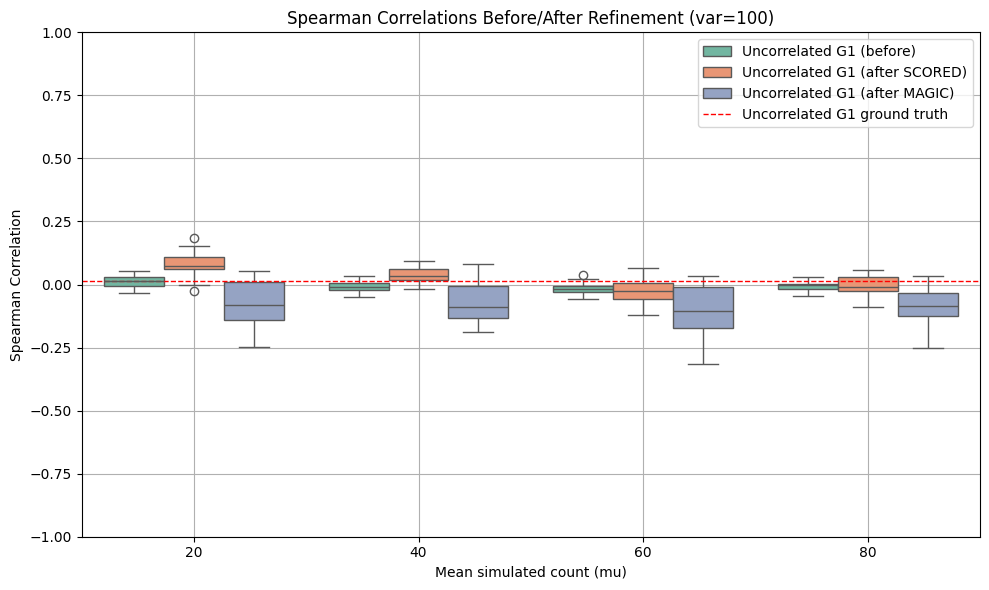

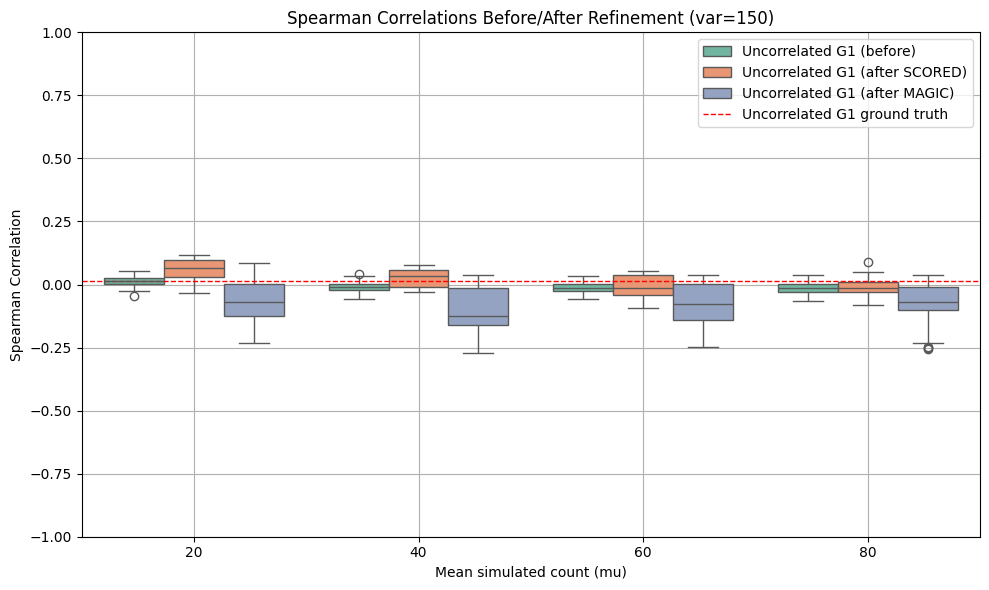

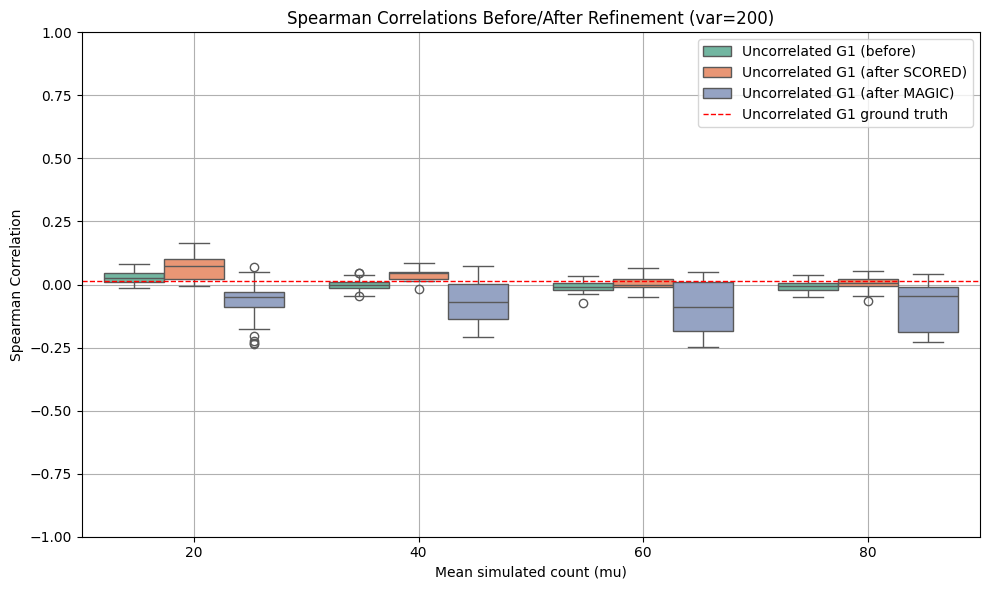

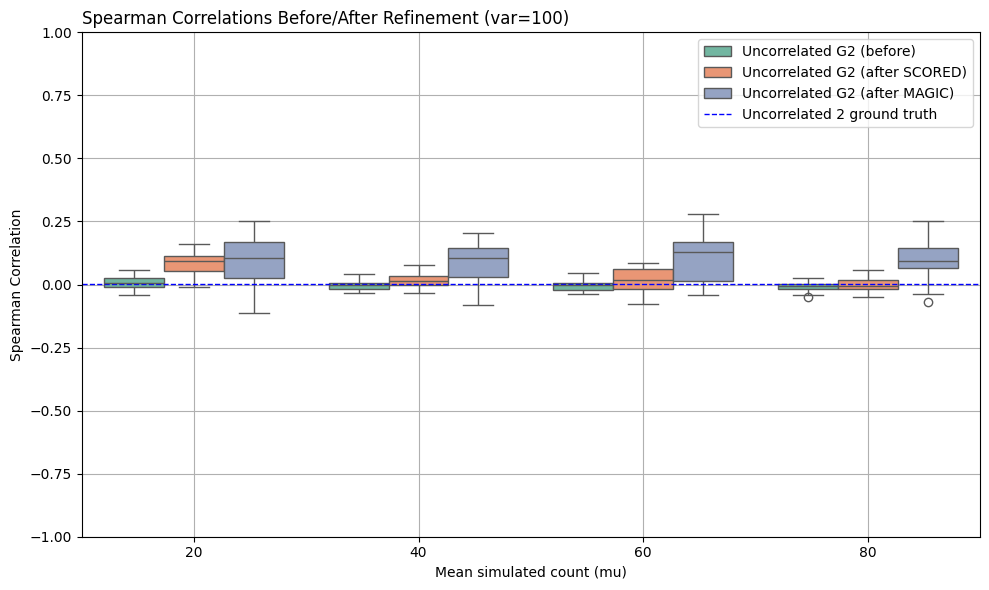

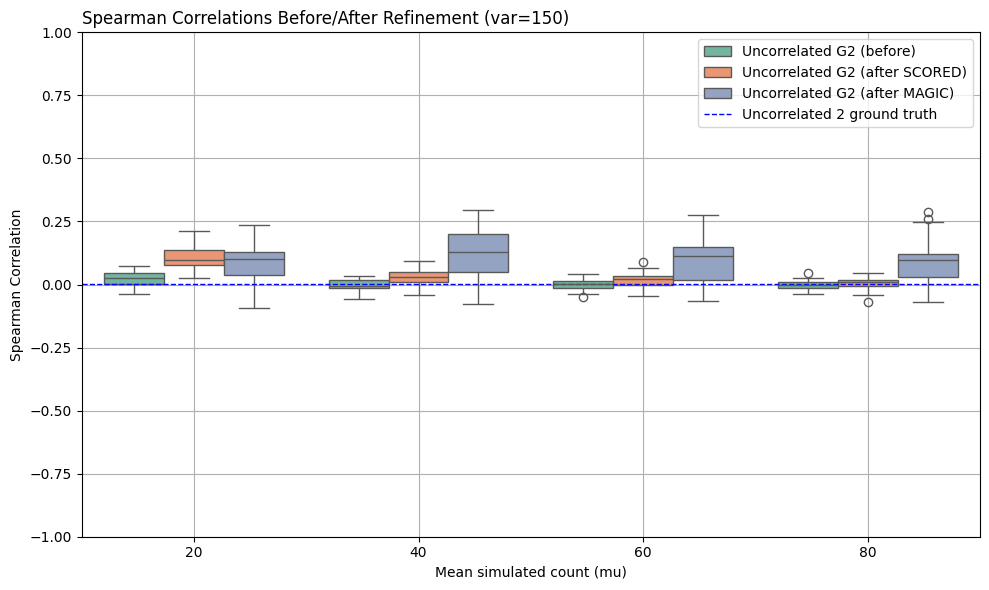

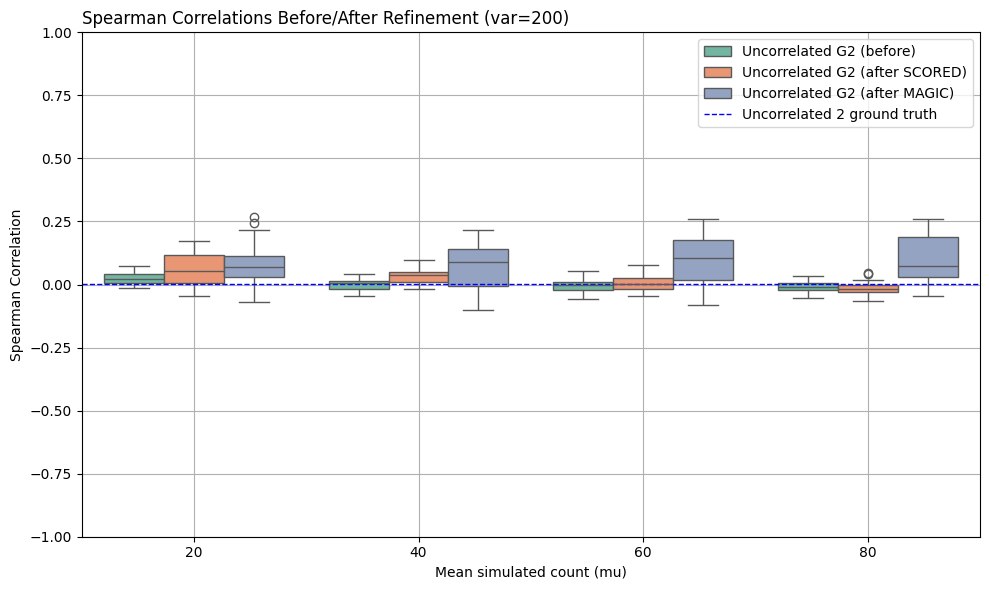

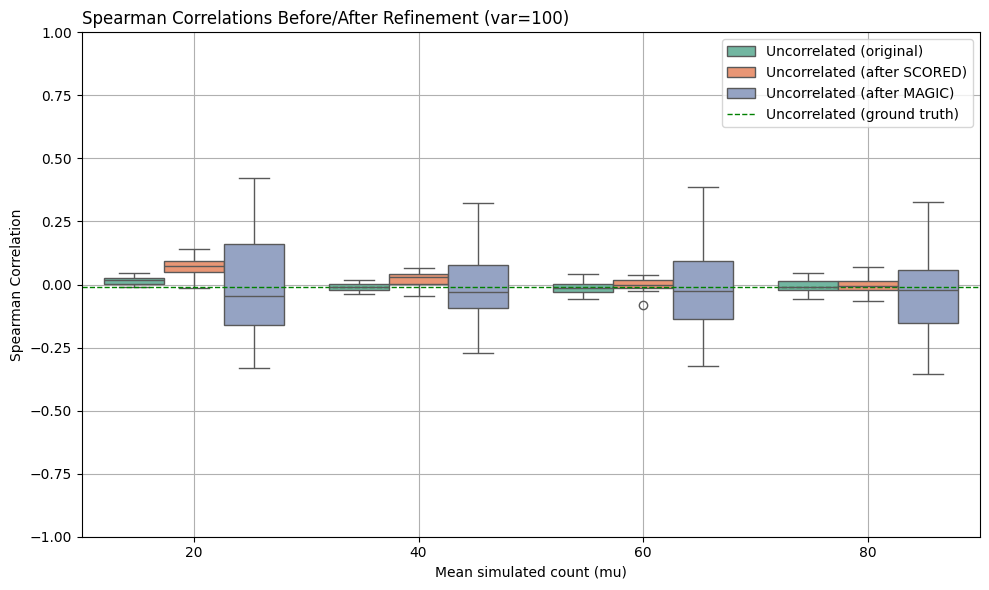

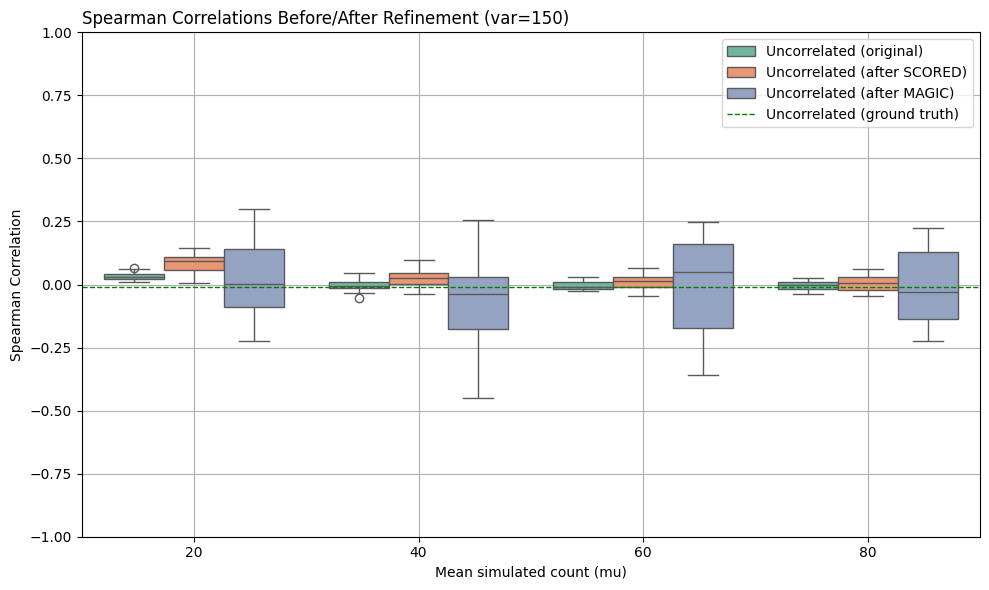

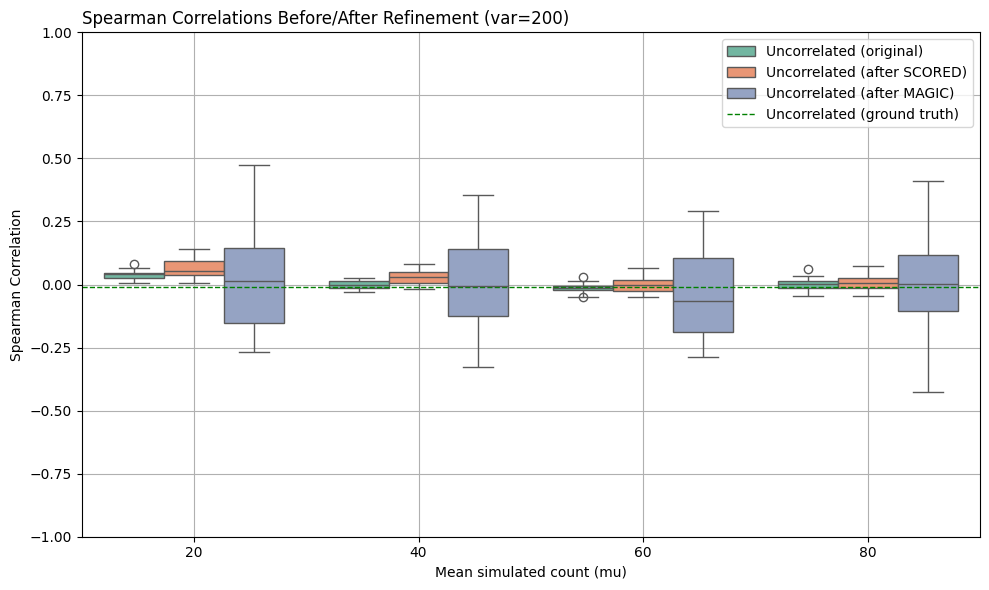

In [40]:

np.random.seed(3)


def simulate_negative_binomial_data(matrix, mu, var):
    """
    - Normalizes rows of 'matrix' to get probabilities per row.
    - Simulates total counts from NB(mu, var).
    - Samples from multinomial for each row.
    - Normalizes, multiplies by 100, then log1p.
    Returns a NumPy array of shape (cells, genes).
    """
    # Normalize to row sums
    row_sums = matrix.sum(axis=1, keepdims=True)
    prob_matrix = matrix / np.maximum(row_sums, 1e-12)

    if var <= mu:
        raise ValueError(f"Variance {var} must be > mean {mu} for a valid Negative Binomial.")

    # Calculate NB parameters
    n_float = mu**2 / (var - mu)  # shape
    if n_float <= 0:
        raise ValueError("Computed n is not positive. Check your mean/variance inputs.")
    p = n_float / (mu + n_float)  # success probability

    # Sample total counts from NB
    total_counts = np.random.negative_binomial(n_float, p, size=len(prob_matrix))
    total_counts = np.clip(total_counts, a_min=1, a_max=None).astype(int)

    # Multinomial to distribute across each row
    counts_matrix = np.array([
        np.random.multinomial(tc, row_p)
        for tc, row_p in zip(total_counts, prob_matrix)
    ])

    # Normalize by total_counts, scale by 100, log1p
    counts_matrix = counts_matrix / total_counts[:, np.newaxis]
    counts_matrix = counts_matrix * 100
    return np.log1p(counts_matrix)


def compute_cd8_and_cd4_cd8_correlations(expression_matrix,
                                         cd8_range=(15, 20),
                                         cd4_range=(0, 5)):
    """
    Returns two lists:
      - cd8_corrs: pairwise correlations among columns in cd8_range
      - cd4_cd8_corrs: pairwise correlations between cd4_range and cd8_range
    """
    # CD8 vs noise
    start_cd8, end_cd8 = cd8_range
    cd8_corrs = []
    for i in range(start_cd8, end_cd8):
        for j in range(40, 45):
            corr, _ = spearmanr(expression_matrix[:, i], expression_matrix[:, j])
            cd8_corrs.append(corr)

    # CD4 vs noise
    start_cd4, end_cd4 = cd4_range
    cd4_cd8_corrs = []
    for i in range(start_cd4, end_cd4):
        for j in range(40, 45):
            corr, _ = spearmanr(expression_matrix[:, i], expression_matrix[:, j])
            cd4_cd8_corrs.append(corr)

    # noise vs noise
    noise_corrs = []
    for i in range(40, 45):
        for j in range(46, 50):
            corr, _ = spearmanr(expression_matrix[:, i], expression_matrix[:, j])
            noise_corrs.append(corr)

    return cd8_corrs, cd4_cd8_corrs, noise_corrs

# ------------------------------------------------------
#  Main loop: vary mu while fixing var = 100.
#     compute correlations BEFORE vs. AFTER RWR
#    for both CD8–CD8 and CD4–CD8.
# ------------------------------------------------------
mu_values = [20, 40, 60, 80]  # the range of mu
var_values = [100, 150, 200]
list_of_dfs_proposed = []

for var in var_values:

    results = []  # accumulate (mu, group, correlation)

    for mu in mu_values:
        # (a) Simulate data
        sim_matrix = simulate_negative_binomial_data(
            matrix_combined_isoform, mu=mu, var=var
        )

        # (b) Compute correlations BEFORE
        cd8_corr_before, cd4_cd8_corr_before, noise_corr_before = compute_cd8_and_cd4_cd8_correlations(sim_matrix,
                                                                                  cd8_range=(15, 20),
                                                                                  cd4_range=(0, 5))

        # Create AnnData object
        gene_names = [f"Gene_{i+1}" for i in range(sim_matrix.shape[1])]
        adata = anndata.AnnData(X=sim_matrix)

        # (c) Run RWR algorithm
        new_matrix, P_final = rwr_impute(sim_matrix_df_norm, adata, alpha=0.3, max_iter=100, tol=1e-4, device=device)
        adata_new = adata.copy()
        adata_new.X = new_matrix

        # Perform the same analysis as before with adata_transcript_new
        sc.pp.normalize_total(adata_new, target_sum=1e2)
        sc.pp.log1p(adata_new)
        new_matrx = adata_new.X

        # (d) Compute correlations AFTER
        cd8_corr_after, cd4_cd8_corr_after, noise_corr_after = compute_cd8_and_cd4_cd8_correlations(new_matrix,
                                                                                  cd8_range=(15, 20),
                                                                                  cd4_range=(0, 5))

        # Collect results in list
        for val in cd8_corr_before:
            results.append((mu, "Uncorrelated G1 (before)", val))
        for val in cd8_corr_after:
            results.append((mu, "Uncorrelated G1 (after SCORED)", val))
        for val in cd4_cd8_corr_before:
            results.append((mu, "Uncorrelated G2 (before)", val))
        for val in cd4_cd8_corr_after:
            results.append((mu, "Uncorrelated G2 (after SCORED)", val))
        for val in noise_corr_before:
            results.append((mu, "Uncorrelated (original)", val))
        for val in noise_corr_after:
            results.append((mu, "Uncorrelated (after SCORED)", val))


    df = pd.DataFrame(results, columns=["mu", "group", "correlation"])

    df["method"] = "Proposed"
    df["var"] = var

    #if 'list_of_dfs_proposed' not in globals():
        #list_of_dfs_proposed = []

    list_of_dfs_proposed.append(df)

df_proposed = pd.concat(list_of_dfs_proposed, ignore_index=True)
df_magic = pd.read_csv("./magic_output/10x/simulation_magic_zero_t3.csv")

df_magic['group'] = df_magic['group'].replace('Uncorrelated G3 (after MAGIC)', 'Uncorrelated (after MAGIC)')


df_combined = pd.concat([df_proposed, df_magic], ignore_index=True)


for var in var_values:
    subset = df_combined[df_combined["var"] == var]

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=subset,
        x="mu",
        y="correlation",
        hue="group",
        palette="Set2",
        hue_order=["Uncorrelated G1 (before)",
                   "Uncorrelated G1 (after SCORED)",
                   "Uncorrelated G1 (after MAGIC)"]

    )

    plt.axhline(uncorrelated_1_truth, color="red", linestyle="--", linewidth=1, label="Uncorrelated G1 ground truth")


    plt.title(f"Spearman Correlations Before/After Refinement (var={var})")
    plt.ylim(-1, 1)
    plt.xlabel("Mean simulated count (mu)")
    plt.ylabel("Spearman Correlation")
    plt.legend()
    # Move the legend to the right side
    #plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for var in var_values:
    subset = df_combined[df_combined["var"] == var]

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=subset,
        x="mu",
        y="correlation",
        hue="group",
        palette="Set2",
        hue_order=[ "Uncorrelated G2 (before)",
                   "Uncorrelated G2 (after SCORED)",
                   "Uncorrelated G2 (after MAGIC)"]

    )

    plt.axhline(uncorrelated_2_truth+0.005, color="blue", linestyle="--", linewidth=1, label="Uncorrelated 2 ground truth")

    plt.title(f"Spearman Correlations Before/After Refinement (var={var})", loc='left')
    plt.ylim(-1, 1)
    plt.xlabel("Mean simulated count (mu)")
    plt.ylabel("Spearman Correlation")
    plt.legend()
    # Move the legend to the right side
    #plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for var in var_values:
    subset = df_combined[df_combined["var"] == var]

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=subset,
        x="mu",
        y="correlation",
        hue="group",
        palette="Set2",
        hue_order=["Uncorrelated (original)",
                   "Uncorrelated (after SCORED)",
                   "Uncorrelated (after MAGIC)"]

    )


    plt.axhline(uncorrelated_3_truth-0.005, color="green", linestyle="--", linewidth=1, label="Uncorrelated (ground truth)")

    plt.title(f"Spearman Correlations Before/After Refinement (var={var})", loc='left')
    plt.ylim(-1, 1)
    plt.xlabel("Mean simulated count (mu)")
    plt.ylabel("Spearman Correlation")
    plt.legend()
    # Move the legend to the right side
    #plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Random walk with restart converged in 13 iterations.
Random walk with restart converged in 13 iterations.
Random walk with restart converged in 13 iterations.
Random walk with restart converged in 13 iterations.
Random walk with restart converged in 13 iterations.


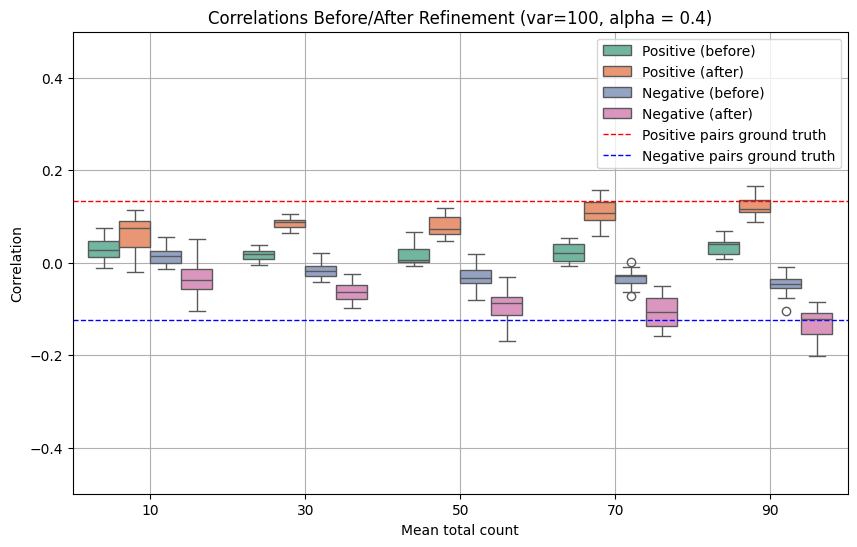

Random walk with restart converged in 13 iterations.
Random walk with restart converged in 13 iterations.
Random walk with restart converged in 13 iterations.
Random walk with restart converged in 13 iterations.
Random walk with restart converged in 13 iterations.


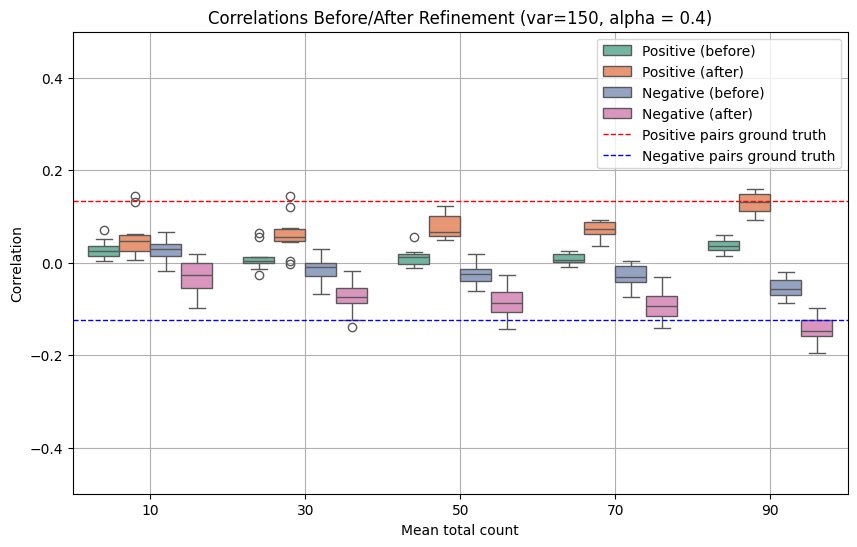

Random walk with restart converged in 13 iterations.
Random walk with restart converged in 13 iterations.
Random walk with restart converged in 13 iterations.
Random walk with restart converged in 13 iterations.
Random walk with restart converged in 13 iterations.


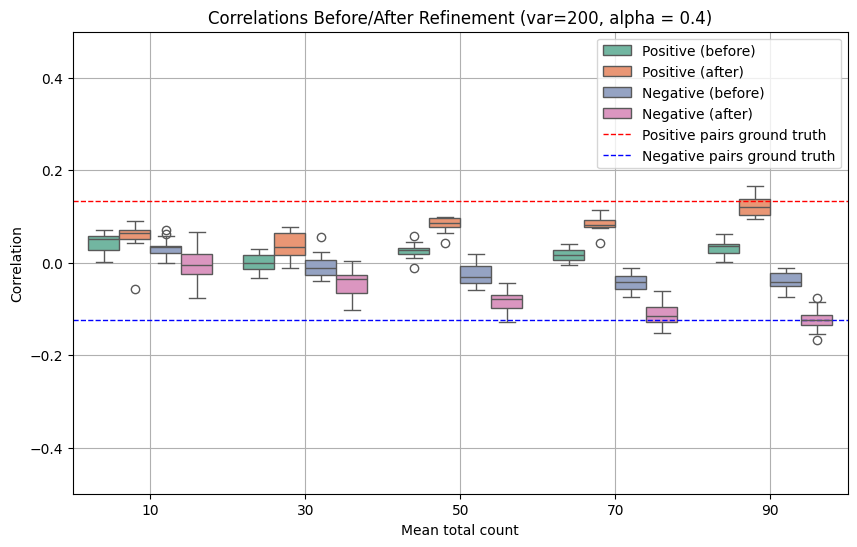

In [41]:



np.random.seed(3)


def simulate_negative_binomial_data(matrix, mu, var):
    """
    - Normalizes rows of 'matrix' to get probabilities per row.
    - Simulates total counts from NB(mu, var).
    - Samples from multinomial for each row.
    - Normalizes, multiplies by 100, then log1p.
    Returns a NumPy array of shape (cells, genes).
    """
    # Normalize to row sums
    row_sums = matrix.sum(axis=1, keepdims=True)
    prob_matrix = matrix / np.maximum(row_sums, 1e-12)

    if var <= mu:
        raise ValueError(f"Variance {var} must be > mean {mu} for a valid Negative Binomial.")

    # Calculate NB parameters
    n_float = mu**2 / (var - mu)  # shape
    if n_float <= 0:
        raise ValueError("Computed n is not positive. Check your mean/variance inputs.")
    p = n_float / (mu + n_float)  # success probability

    # Sample total counts from NB
    total_counts = np.random.negative_binomial(n_float, p, size=len(prob_matrix))
    total_counts = np.clip(total_counts, a_min=1, a_max=None).astype(int)

    # Multinomial to distribute across each row
    counts_matrix = np.array([
        np.random.multinomial(tc, row_p)
        for tc, row_p in zip(total_counts, prob_matrix)
    ])

    # Normalize by total_counts, log1p
    counts_matrix = counts_matrix / total_counts[:, np.newaxis]
    counts_matrix = counts_matrix * 100
    return np.log1p(counts_matrix)


def compute_cd8_and_cd4_cd8_correlations(expression_matrix,
                                         cd8_range=(15, 20),
                                         cd4_range=(0, 5)):
    """
    Returns two lists:
      - cd8_corrs: pairwise correlations among columns in cd8_range
      - cd4_cd8_corrs: pairwise correlations between cd4_range and cd8_range
    """
    # CD8 vs CD8
    start_cd8, end_cd8 = cd8_range
    cd8_corrs = []
    for i in range(start_cd8, end_cd8):
        for j in range(i+1, end_cd8):
            corr, _ = pearsonr(expression_matrix[:, i], expression_matrix[:, j])
            cd8_corrs.append(corr)

    # CD4 vs CD8
    start_cd4, end_cd4 = cd4_range
    cd4_cd8_corrs = []
    for i in range(start_cd4, end_cd4):
        for j in range(start_cd8, end_cd8):
            corr, _ = pearsonr(expression_matrix[:, i], expression_matrix[:, j])
            cd4_cd8_corrs.append(corr)

    return cd8_corrs, cd4_cd8_corrs

# ------------------------------------------------------
# Main loop: vary mu while fixing var = 100.
#    compute correlations BEFORE vs. AFTER RWR
#    for both CD8–CD8 and CD4–CD8.
# ------------------------------------------------------
mu_values = [10, 30, 50, 70, 90]  # the range of mu
var_values = [100, 150, 200]

for var in var_values:

    results = []  # accumulate (mu, group, correlation)

    for mu in mu_values:
        # (a) Simulate data
        sim_matrix = simulate_negative_binomial_data(
            matrix_combined_isoform, mu=mu, var=var
        )

        # (b) Compute correlations BEFORE
        cd8_corr_before, cd4_cd8_corr_before = compute_cd8_and_cd4_cd8_correlations(sim_matrix,
                                                                                  cd8_range=(15, 20),
                                                                                  cd4_range=(0, 5))

        # Create AnnData object
        gene_names = [f"Gene_{i+1}" for i in range(sim_matrix.shape[1])]
        adata = anndata.AnnData(X=sim_matrix)

        # (c) Run RWR algorithm
        new_matrix, P_final = rwr_impute(sim_matrix_df_norm, adata, alpha=0.4, max_iter=100, tol=1e-4, device=device)
        adata_new = adata.copy()
        adata_new.X = new_matrix

        # Perform the same analysis as before with adata_transcript_new
        sc.pp.normalize_total(adata_new, target_sum=1e2)
        sc.pp.log1p(adata_new)
        new_matrx = adata_new.X

        # (d) Compute correlations AFTER
        cd8_corr_after, cd4_cd8_corr_after = compute_cd8_and_cd4_cd8_correlations(new_matrix,
                                                                                  cd8_range=(15, 20),
                                                                                  cd4_range=(0, 5))

        # Collect results in list
        for val in cd8_corr_before:
            results.append((mu, "Positive (before)", val))
        for val in cd8_corr_after:
            results.append((mu, "Positive (after)", val))
        for val in cd4_cd8_corr_before:
            results.append((mu, "Negative (before)", val))
        for val in cd4_cd8_corr_after:
            results.append((mu, "Negative (after)", val))


    df = pd.DataFrame(results, columns=["mu", "group", "correlation"])


    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x="mu", y="correlation", hue="group", palette="Set2")
    #sns.stripplot(data=df, x="mu", y="correlation", hue="group", dodge=True, color="black", alpha=0.3)
    plt.axhline(positive_truth, color="red", linestyle="--", linewidth=1, label="Positive pairs ground truth")
    plt.axhline(negative_truth, color="blue", linestyle="--", linewidth=1, label="Negative pairs ground truth")

    plt.title(f"Correlations Before/After Refinement (var={var}, alpha = 0.4)")
    plt.ylim(-0.5, 0.5)
    plt.xlabel("Mean total count")
    plt.ylabel("Correlation")
    plt.legend()
    plt.grid(True)
    plt.show()


Random walk with restart converged in 13 iterations.
Random walk with restart converged in 13 iterations.
Random walk with restart converged in 13 iterations.
Random walk with restart converged in 13 iterations.


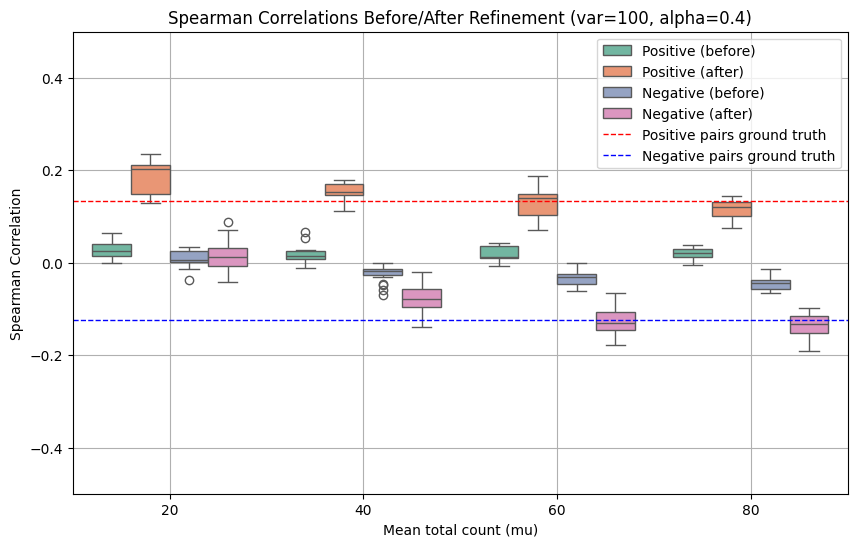

Random walk with restart converged in 13 iterations.
Random walk with restart converged in 13 iterations.
Random walk with restart converged in 13 iterations.
Random walk with restart converged in 13 iterations.


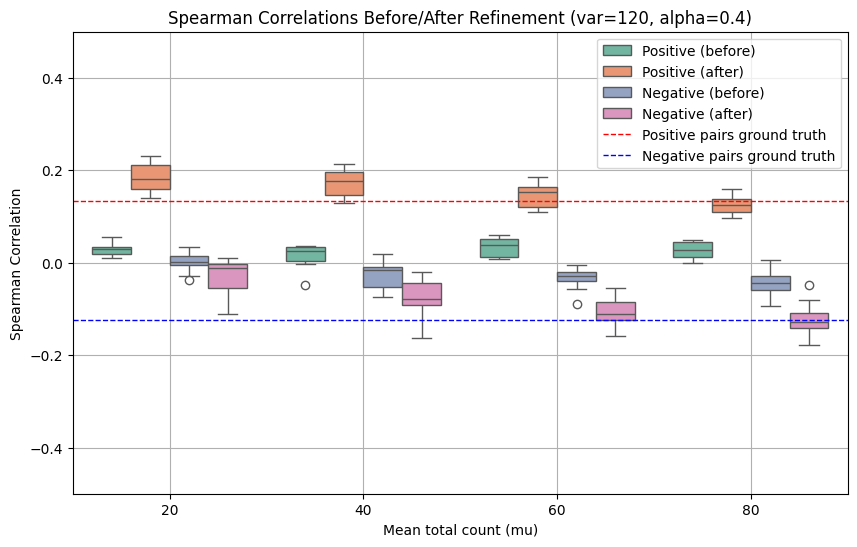

Random walk with restart converged in 13 iterations.
Random walk with restart converged in 13 iterations.
Random walk with restart converged in 13 iterations.
Random walk with restart converged in 13 iterations.


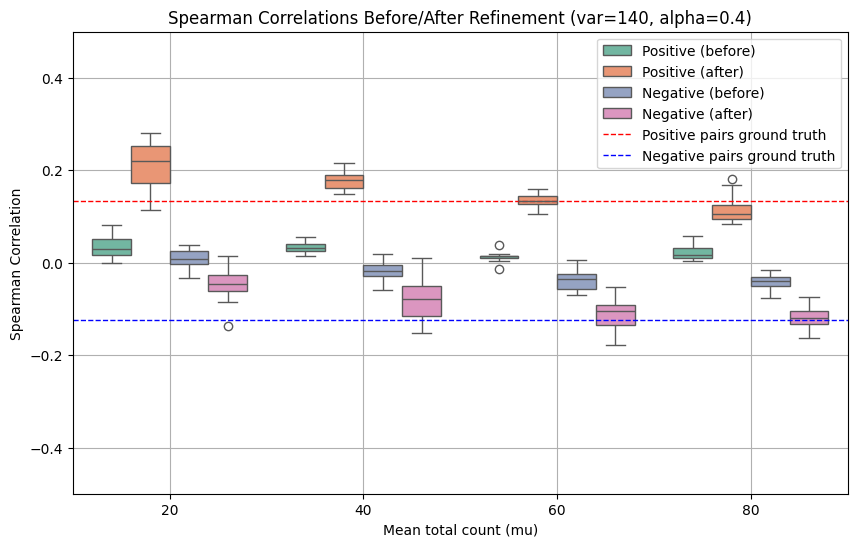

In [42]:
np.random.seed(3)


def simulate_negative_binomial_data(matrix, mu, var):
    """
    - Normalizes rows of 'matrix' to get probabilities per row.
    - Simulates total counts from NB(mu, var).
    - Samples from multinomial for each row.
    - Normalizes, multiplies by 100, then log1p.
    Returns a NumPy array of shape (cells, genes).
    """
    # Normalize to row sums
    row_sums = matrix.sum(axis=1, keepdims=True)
    prob_matrix = matrix / np.maximum(row_sums, 1e-12)

    if var <= mu:
        raise ValueError(f"Variance {var} must be > mean {mu} for a valid Negative Binomial.")

    # Calculate NB parameters
    n_float = mu**2 / (var - mu)  # shape parameter
    if n_float <= 0:
        raise ValueError("Computed n is not positive. Check your mean/variance inputs.")
    p = n_float / (mu + n_float)  # success probability

    # Sample total counts from NB
    total_counts = np.random.negative_binomial(n_float, p, size=len(prob_matrix))
    total_counts = np.clip(total_counts, a_min=1, a_max=None).astype(int)

    # Multinomial to distribute counts across each row
    counts_matrix = np.array([
        np.random.multinomial(tc, row_p)
        for tc, row_p in zip(total_counts, prob_matrix)
    ])

    # Normalize by total counts, then log1p
    counts_matrix = counts_matrix / total_counts[:, np.newaxis]
    counts_matrix = counts_matrix * 100
    return np.log1p(counts_matrix)


def compute_cd8_and_cd4_cd8_correlations(expression_matrix,
                                         cd8_range=(15, 20),
                                         cd4_range=(0, 5)):
    """
    Returns two lists:
      - cd8_corrs: pairwise correlations among columns in cd8_range
      - cd4_cd8_corrs: pairwise correlations between cd4_range and cd8_range
    """
    # CD8 vs CD8 correlations
    start_cd8, end_cd8 = cd8_range
    cd8_corrs = []
    for i in range(start_cd8, end_cd8):
        for j in range(i+1, end_cd8):
            corr, _ = spearmanr(expression_matrix[:, i], expression_matrix[:, j])
            cd8_corrs.append(corr)

    # CD4 vs CD8 correlations
    start_cd4, end_cd4 = cd4_range
    cd4_cd8_corrs = []
    for i in range(start_cd4, end_cd4):
        for j in range(start_cd8, end_cd8):
            corr, _ = spearmanr(expression_matrix[:, i], expression_matrix[:, j])
            cd4_cd8_corrs.append(corr)

    return cd8_corrs, cd4_cd8_corrs

# ------------------------------------------------------
#  Main loop: vary mu while fixing var = 100, 150, and 200.
#    compute correlations BEFORE vs. AFTER RWR
#    for both CD8–CD8 and CD4–CD8.
# ------------------------------------------------------
mu_values = [20, 40, 60, 80]  # Different mu values
var_values = [100, 120, 140]



for var in var_values:

    results = []  # To accumulate (mu, group, correlation)

    for mu in mu_values:
        # (a) Simulate data
        sim_matrix = simulate_negative_binomial_data(
            matrix_combined_isoform, mu=mu, var=var
        )

        # (b) Compute correlations BEFORE RWR refinement
        cd8_corr_before, cd4_cd8_corr_before = compute_cd8_and_cd4_cd8_correlations(
            sim_matrix, cd8_range=(15, 20), cd4_range=(0, 5)
        )

        # Create an AnnData object for use in the RWR algorithm
        gene_names = [f"Gene_{i+1}" for i in range(sim_matrix.shape[1])]
        adata = anndata.AnnData(X=sim_matrix)
        adata.var['gene_names'] = gene_names

        # (c) Run RWR algorithm
        new_matrix, P_final = rwr_impute(sim_matrix_df_norm, adata, alpha=0.4, max_iter=100, tol=1e-4, device=device)
        adata_new = adata.copy()
        adata_new.X = new_matrix

        # Perform the same normalization on the refined data
        sc.pp.normalize_total(adata_new, target_sum=1e2)
        sc.pp.log1p(adata_new)
        new_matrix = adata_new.X  # Updated refined matrix

        # (d) Compute correlations AFTER RWR refinement
        cd8_corr_after, cd4_cd8_corr_after = compute_cd8_and_cd4_cd8_correlations(
            new_matrix, cd8_range=(15, 20), cd4_range=(0, 5)
        )

        # Collect results with labels for 'before' and 'after'
        for val in cd8_corr_before:
            results.append((mu, "Positive (before)", val))
        for val in cd8_corr_after:
            results.append((mu, "Positive (after)", val))
        for val in cd4_cd8_corr_before:
            results.append((mu, "Negative (before)", val))
        for val in cd4_cd8_corr_after:
            results.append((mu, "Negative (after)", val))


    df = pd.DataFrame(results, columns=["mu", "group", "correlation"])


    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x="mu", y="correlation", hue="group", palette="Set2")
    # sns.stripplot(data=df, x="mu", y="correlation", hue="group", dodge=True, color="black", alpha=0.3)

    plt.axhline(positive_truth, color="red", linestyle="--", linewidth=1, label="Positive pairs ground truth")
    plt.axhline(negative_truth, color="blue", linestyle="--", linewidth=1, label="Negative pairs ground truth")

    plt.title(f"Spearman Correlations Before/After Refinement (var={var}, alpha=0.4)")
    plt.ylim(-0.5, 0.5)
    plt.xlabel("Mean total count (mu)")
    plt.ylabel("Spearman Correlation")
    plt.legend()
    plt.grid(True)
    plt.show()